In [1]:
# ============================================================
# Ghosh (supply-driven) shocks to Copper (by country, one at a time)
# -> Measure impact on FR wind and FR solar PV outputs
# ============================================================
import os, re
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio

from datetime import datetime

import glob
import numpy as np

import zipfile

from matplotlib.colors import LinearSegmentedColormap

In [2]:
# -----------------------------
# 0) Configure EXIOBASE path
# -----------------------------
path_zip = r"C:\Users\Dyde-nairn\Documents\python\_input_output_dependencies\IOT_2022_pxp.v3.8.2.zip"

if not os.path.exists(path_zip):
    raise FileNotFoundError(
        f"EXIOBASE file not found at:\n{path_zip}\n"
        "Please update 'path_zip' to the location of your EXIOBASE3 PXP .zip file."
    )
# -----------------------------
# 1) Load data
# -----------------------------
exio3 = pymrio.parse_exiobase3(path=path_zip)  # provides A, x, Y, etc.

[Diagnostics] Spectral radius(B) = 0.972891
[Match] FR Wind  -> ('FR', 'Electricity by wind')
[Match] FR Solar -> ('FR', 'Electricity by solar photovoltaic')
[Match] Copper industry name -> Copper ores and concentrates
[Saved] ghosh_copper_to_FRwind_solar\impact_FR_wind_solar_from_copper_supply_shocks_1pct_20251222_0948.csv


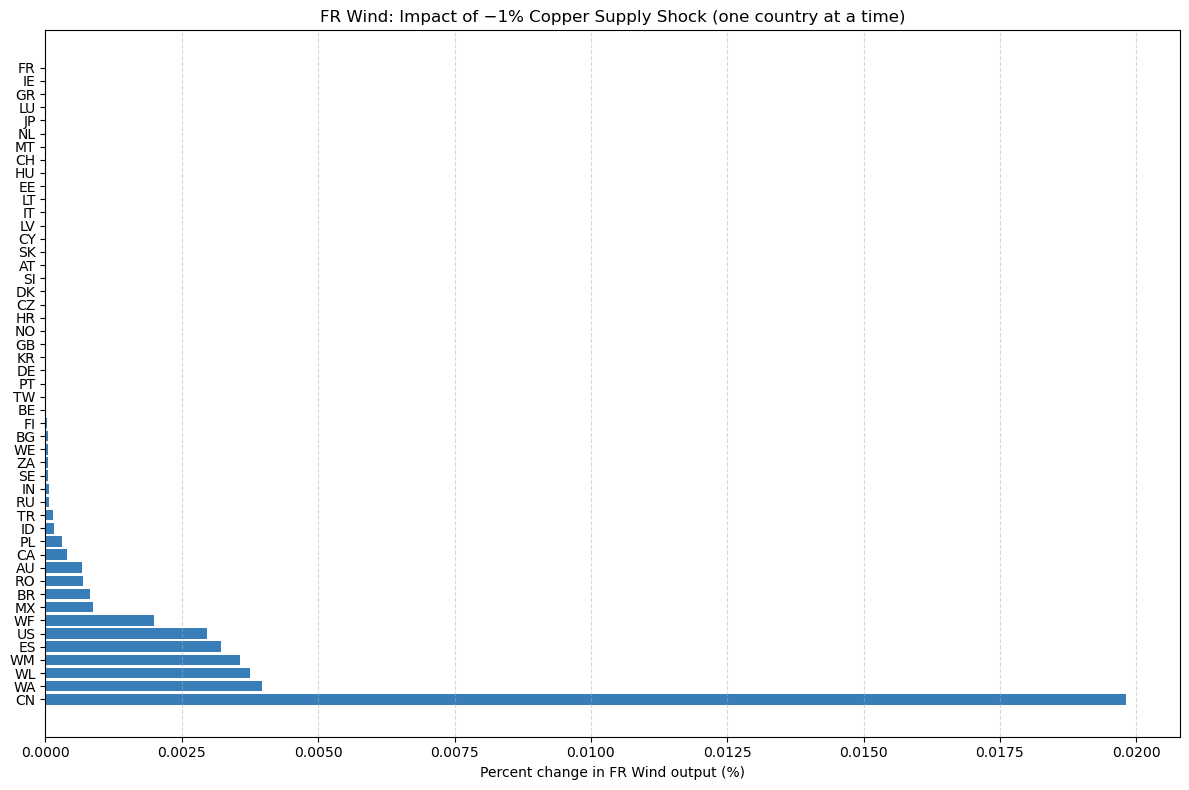

[Saved] ghosh_copper_to_FRwind_solar\bar_FR_wind_from_copper_shocks_pct_1_20251222_0948.png


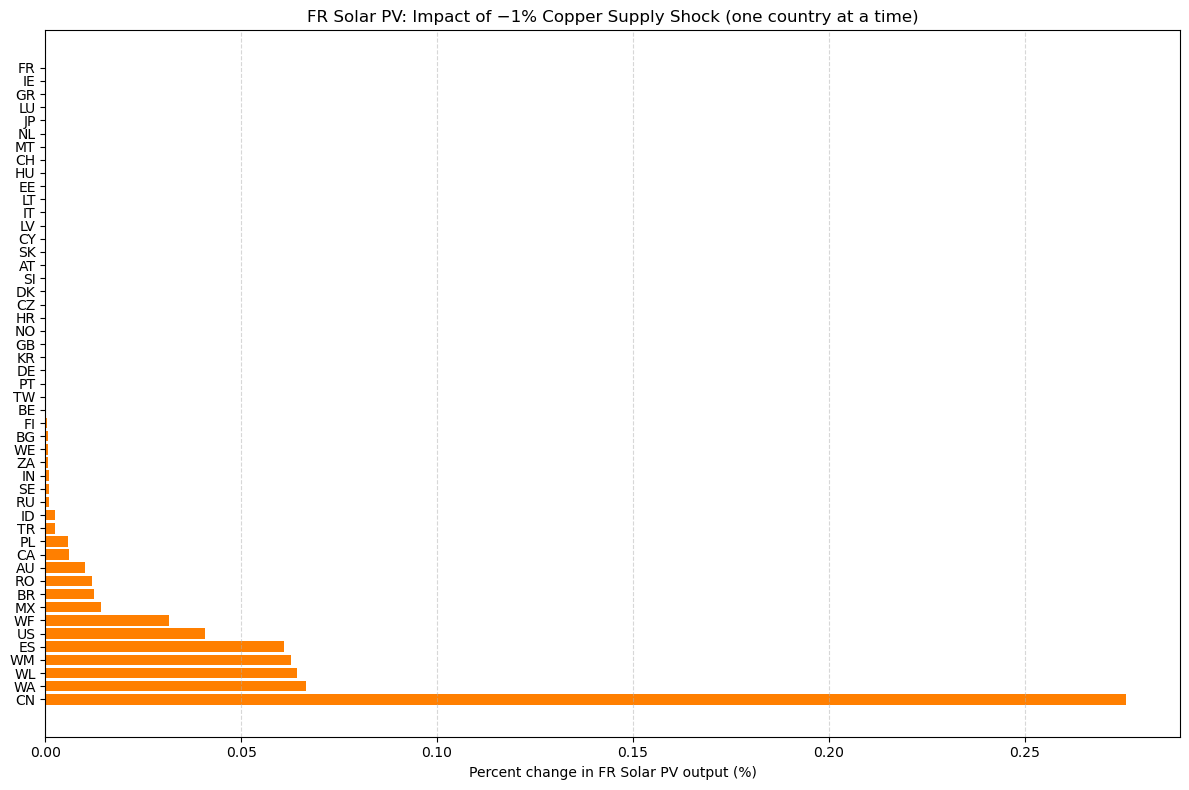

[Saved] ghosh_copper_to_FRwind_solar\bar_FR_solar_from_copper_shocks_pct_1_20251222_0948.png


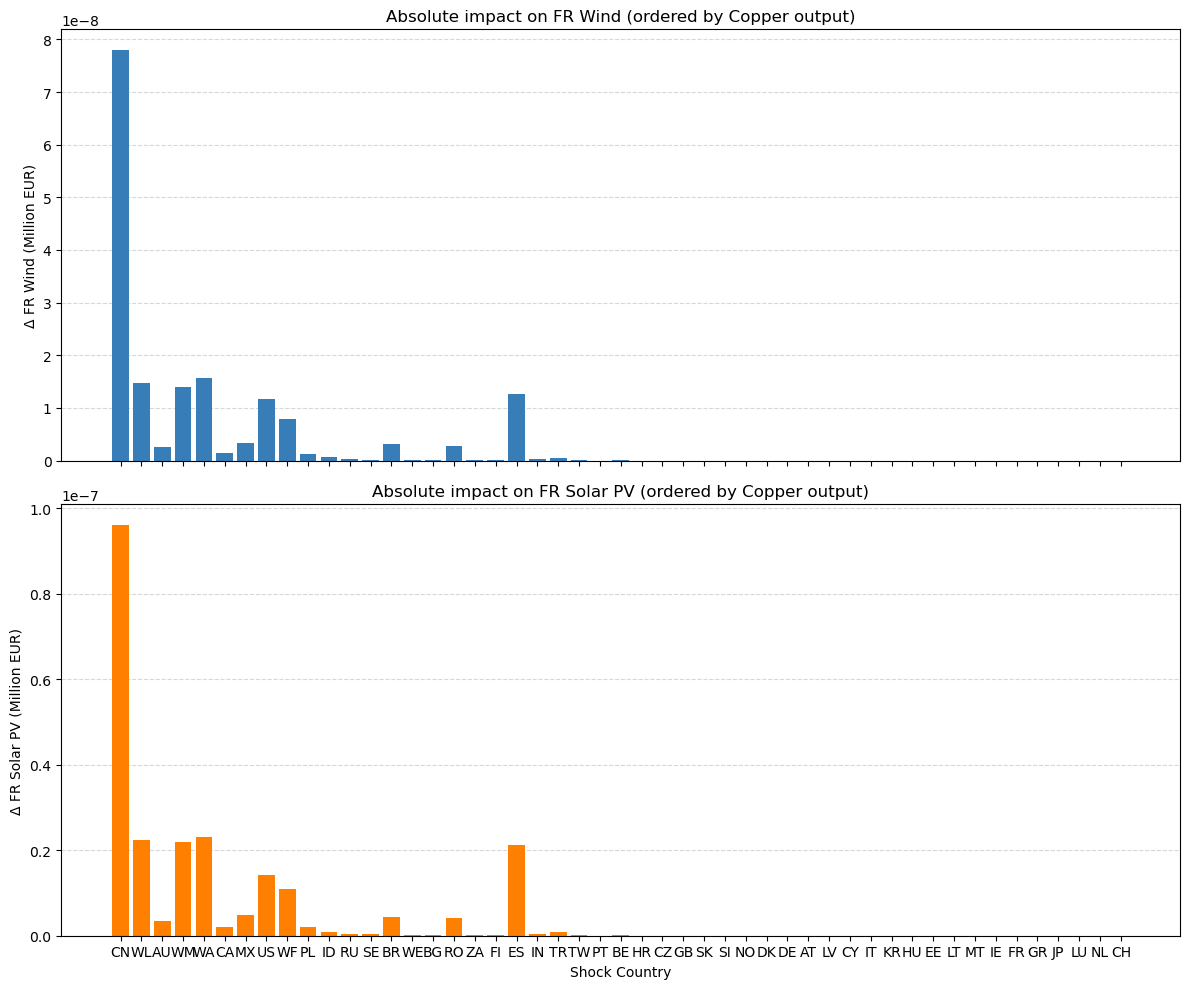

[Saved] ghosh_copper_to_FRwind_solar\bars_abs_FR_wind_solar_from_copper_shocks_1_20251222_0948.png

[Top 10 most negative percent impacts on FR Wind]:
Shock_Country  pct_FR_Wind
           FR 2.318988e-10
           IE 2.318988e-10
           GR 2.318988e-10
           LU 2.318988e-10
           JP 2.318988e-10
           NL 2.318988e-10
           MT 2.318988e-10
           CH 2.318988e-10
           HU 2.429849e-10
           EE 2.836340e-10

[Top 10 most negative percent impacts on FR Solar]:


In [4]:
# -----------------------------
# 2) Robust label utilities
# -----------------------------
def _norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s)).strip().lower()

def find_label(columns, country=None, industry_substrings=()):
    """
    Find FIRST (Country, Industry) label in a MultiIndex 'columns' matching:
    - exact country (if provided)
    - all substrings in 'industry_substrings' (AND logic), case-insensitive
    Falls back to OR logic if no AND match is found.
    """
    subs = tuple(_norm(s) for s in (industry_substrings if isinstance(industry_substrings, (list, tuple)) else [industry_substrings]))
    # AND logic
    cand = []
    for cc, ind in columns:
        if (country is not None) and str(cc) != str(country):
            continue
        indn = _norm(ind)
        if all(s in indn for s in subs):
            cand.append((cc, ind))
    # fallback OR
    if not cand:
        for cc, ind in columns:
            if (country is not None) and str(cc) != str(country):
                continue
            indn = _norm(ind)
            if any(s in indn for s in subs):
                cand.append((cc, ind))
    if not cand:
        raise KeyError(f"No match for country={country}, substrings={industry_substrings}")
    if len(cand) > 1:
        print(f"[Info] Multiple matches for country={country}, {industry_substrings}. Using: {cand[0]}")
    return cand[0]

def find_industry_name(columns, industry_substrings=()):
    """
    Return FIRST industry name (without country) matching substrings across any country.
    """
    subs = tuple(_norm(s) for s in (industry_substrings if isinstance(industry_substrings, (list, tuple)) else [industry_substrings]))
    seen = set()
    # AND logic
    for cc, ind in columns:
        if ind in seen: 
            continue
        seen.add(ind)
        indn = _norm(ind)
        if all(s in indn for s in subs):
            return ind
    # OR logic
    for cc, ind in columns:
        if ind in seen: 
            continue
        seen.add(ind)
        indn = _norm(ind)
        if any(s in indn for s in subs):
            return ind
    raise KeyError(f"No industry name matches substrings={industry_substrings}")

# -----------------------------
# 3) Core matrices (industry space)
# -----------------------------
A_df = exio3.A.copy()  # (industry x industry), MultiIndex (Country, Industry)

# Baseline outputs x (Series with MultiIndex). Handle Series/DataFrame variants.
if isinstance(exio3.x, pd.Series):
    x_base = exio3.x.copy().reindex(A_df.index)
else:
    tmp = exio3.x.iloc[:, 0].copy()
    tmp.index = exio3.x.index
    x_base = tmp.reindex(A_df.index)

# Build Z from A and x: z_ij = A_ij * x_j  (scale each column j by gross output of sector j)
x_cols = x_base.reindex(A_df.columns)
Z_df = A_df.mul(x_cols, axis=1)

# B = row-normalized Z: B_ij = z_ij / x_i  (allocation/share of sector i's output)
x_rows = x_base.reindex(A_df.index).replace(0, np.nan)  # avoid div-by-zero
B_df = Z_df.div(x_rows, axis=0).fillna(0.0)

I_df = pd.DataFrame(np.eye(len(B_df)), index=B_df.index, columns=B_df.columns)

# Diagnostics
rho_B = float(np.max(np.abs(np.linalg.eigvals(B_df.values))))
print(f"[Diagnostics] Spectral radius(B) = {rho_B:.6f}")
if rho_B >= 1.0:
    print("[Warn] (I - B) may be ill-conditioned. Proceeding with caution.")

# Ghosh inverse and baseline primary supply s
G_df = pd.DataFrame(np.linalg.inv((I_df - B_df).values), index=B_df.index, columns=B_df.columns)
s_base = (I_df - B_df).dot(x_base)  # primary inputs by industry-country

# -----------------------------
# 4) Targets & Copper label
# -----------------------------
# Target French sectors
fr_wind_label  = find_label(A_df.columns, country="FR", industry_substrings=("electricity", "wind"))
fr_solar_label = find_label(A_df.columns, country="FR", industry_substrings=("electricity", "solar", "photovoltaic"))
print(f"[Match] FR Wind  -> {fr_wind_label}")
print(f"[Match] FR Solar -> {fr_solar_label}")

# Copper sector (upstream) — use ores & concentrates
copper_industry = find_industry_name(A_df.columns, industry_substrings=("copper", "ore"))
print(f"[Match] Copper industry name -> {copper_industry}")

# Baseline FR outputs for percent changes
x_fr_wind_base  = float(x_base.loc[fr_wind_label])
x_fr_solar_base = float(x_base.loc[fr_solar_label])

# -----------------------------
# 5) Loop: country-by-country negative supply shock to Copper
# -----------------------------
shock_pct = 0.01  # 1% negative supply shock (reduce s by 1%)
all_countries = A_df.columns.get_level_values(0).unique()

shock_countries = [cc for cc in all_countries if (cc, copper_industry) in A_df.columns]
if not shock_countries:
    raise ValueError(f"No country has copper industry '{copper_industry}' in A.")

records = []
for cc in shock_countries:
    label = (cc, copper_industry)
    if label not in s_base.index:
        # If missing in s index, skip safely
        records.append({
            "Shock_Country": cc,
            "d_FR_Wind_EUR": np.nan,
            "pct_FR_Wind": np.nan,
            "d_FR_Solar_EUR": np.nan,
            "pct_FR_Solar": np.nan
        })
        continue

    # Apply negative supply shock: s' = s, but s[label] *= (1 - shock_pct)
    s_shock = s_base.copy()
    s_shock.loc[label] = s_shock.loc[label] * (1 - shock_pct)

    # Compute new outputs via Ghosh: x' = G * s'
    x_shock = G_df.dot(s_shock)

    # Extract French wind & solar changes
    d_wind  = float(x_shock.loc[fr_wind_label]  - x_fr_wind_base)
    d_solar = float(x_shock.loc[fr_solar_label] - x_fr_solar_base)

    pct_wind  = (100.0 * d_wind  / x_fr_wind_base)  if x_fr_wind_base  != 0 else np.nan
    pct_solar = (100.0 * d_solar / x_fr_solar_base) if x_fr_solar_base != 0 else np.nan

    records.append({
        "Shock_Country": cc,
        "d_FR_Wind_EUR": d_wind,
        "pct_FR_Wind": pct_wind,
        "d_FR_Solar_EUR": d_solar,
        "pct_FR_Solar": pct_solar
    })

df_imp = pd.DataFrame(records)

# Also add ordering by baseline copper output (for readability)
idx = pd.IndexSlice
if isinstance(exio3.x, pd.Series):
    copper_output = exio3.x.loc[idx[:, copper_industry]].reset_index()
    copper_output.columns = ["Country", "Industry", "Copper_Output_EUR"]
    copper_by_country = copper_output.set_index("Country")["Copper_Output_EUR"]
else:
    copper_output = exio3.x.loc[idx[:, copper_industry], :]
    copper_output = copper_output.iloc[:, [0]].reset_index()
    copper_output.columns = ["Country", "Industry", "Copper_Output_EUR"]
    copper_by_country = copper_output.set_index("Country")["Copper_Output_EUR"]

df_imp = df_imp.merge(copper_by_country.reset_index().rename(columns={"Country":"Shock_Country"}),
                      on="Shock_Country", how="left")

# -----------------------------
# 6) Save CSV
# -----------------------------
os.makedirs("ghosh_copper_to_FRwind_solar", exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M")
csv_path = os.path.join("ghosh_copper_to_FRwind_solar",
                        f"impact_FR_wind_solar_from_copper_supply_shocks_{int(shock_pct*100)}pct_{ts}.csv")
df_imp.sort_values("Shock_Country").to_csv(csv_path, index=False, encoding="utf-8")
print(f"[Saved] {csv_path}")

# -----------------------------
# 7) Plots (percent impacts), sorted by impact magnitude
# -----------------------------
# Sort by most negative impact (largest absolute decline)
df_wind_sorted  = df_imp.sort_values("pct_FR_Wind").copy()
df_solar_sorted = df_imp.sort_values("pct_FR_Solar").copy()

# Plot settings
plt.figure(figsize=(12, 8))
plt.barh(df_wind_sorted["Shock_Country"], df_wind_sorted["pct_FR_Wind"], color="#377eb8")
plt.gca().invert_yaxis()
plt.xlabel("Percent change in FR Wind output (%)")
plt.title(f"FR Wind: Impact of −{int(shock_pct*100)}% Copper Supply Shock (one country at a time)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
png_wind = os.path.join("ghosh_copper_to_FRwind_solar",
                        f"bar_FR_wind_from_copper_shocks_pct_{int(shock_pct*100)}_{ts}.png")
plt.savefig(png_wind, dpi=300)
plt.show()
print(f"[Saved] {png_wind}")

plt.figure(figsize=(12, 8))
plt.barh(df_solar_sorted["Shock_Country"], df_solar_sorted["pct_FR_Solar"], color="#ff7f00")
plt.gca().invert_yaxis()
plt.xlabel("Percent change in FR Solar PV output (%)")
plt.title(f"FR Solar PV: Impact of −{int(shock_pct*100)}% Copper Supply Shock (one country at a time)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
png_solar = os.path.join("ghosh_copper_to_FRwind_solar",
                         f"bar_FR_solar_from_copper_shocks_pct_{int(shock_pct*100)}_{ts}.png")
plt.savefig(png_solar, dpi=300)
plt.show()
print(f"[Saved] {png_solar}")

# -----------------------------
# 8) (Optional) Also plot absolute EUR impacts, ordered by copper output
# -----------------------------
df_abs = df_imp.sort_values("Copper_Output_EUR", ascending=False).copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
axes[0].bar(df_abs["Shock_Country"], df_abs["d_FR_Wind_EUR"]/1e6, color="#377eb8")
axes[0].set_ylabel("Δ FR Wind (Million EUR)")
axes[0].set_title("Absolute impact on FR Wind (ordered by Copper output)")

axes[1].bar(df_abs["Shock_Country"], df_abs["d_FR_Solar_EUR"]/1e6, color="#ff7f00")
axes[1].set_ylabel("Δ FR Solar PV (Million EUR)")
axes[1].set_title("Absolute impact on FR Solar PV (ordered by Copper output)")
axes[1].set_xlabel("Shock Country")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
png_abs = os.path.join("ghosh_copper_to_FRwind_solar",
                       f"bars_abs_FR_wind_solar_from_copper_shocks_{int(shock_pct*100)}_{ts}.png")
plt.savefig(png_abs, dpi=300)
plt.show()
print(f"[Saved] {png_abs}")

# Quick console summary
print("\n[Top 10 most negative percent impacts on FR Wind]:")
print(df_wind_sorted[["Shock_Country","pct_FR_Wind"]].head(10).to_string(index=False))
print("\n[Top 10 most negative percent impacts on FR Solar]:")


[Diagnostics] ||(I-B)x - s||_∞ = 0.000e+00
[Info] Top 25 copper producers: ['CN', 'WL', 'AU', 'WM', 'WA', 'CA', 'MX', 'US', 'WF', 'PL', 'ID', 'RU', 'SE', 'BR', 'WE', 'BG', 'RO', 'ZA', 'FI', 'ES', 'IN', 'TR', 'TW', 'PT', 'BE']
[Match] Target industry name -> Electricity by solar photovoltaic


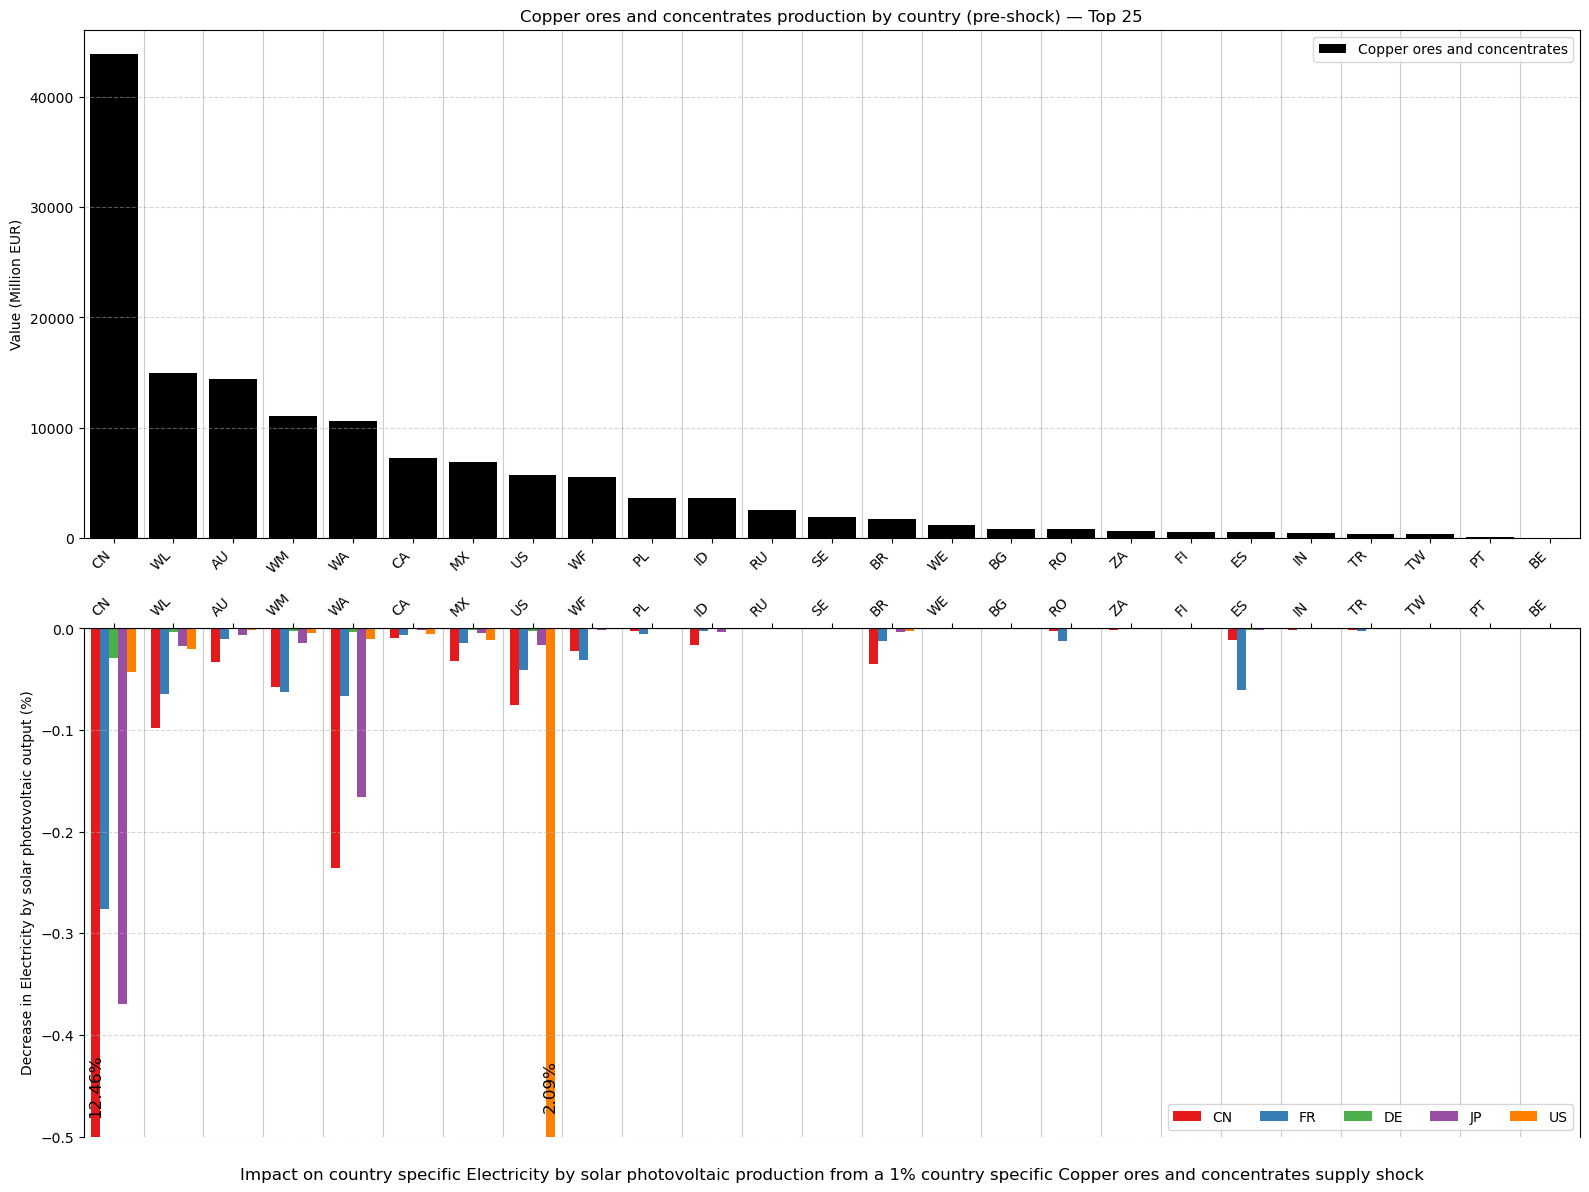

[Saved] ghosh_copper_to_FRwind_solar\grouped_copperTop25_Electricity_by_solar_photovoltaic_SOLAR_ghosh_1pct_20251222_0948.png
[Saved] ghosh_copper_to_FRwind_solar\table_grouped_copperTop25_Electricity_by_solar_photovoltaic_SOLAR_ghosh_1pct_20251222_0948.csv


In [5]:
# ===========================
# 9) Grouped two-panel figure (Solar PV only, Ghosh supply shocks)
# ===========================

# ---------- Config ----------
# Target industry is Solar PV electricity
target_industry_substrings = ("electricity", "solar", "photovoltaic")

# Countries to show in the grouped bars (bottom panel)
target_countries = ["CN", "FR", "DE", "JP", "US"]  # edit as desired

# Show top-N copper producers
TOP_N = 25

# Colors per target country
country_colors = {
    "CN": "#e41a1c",
    "FR": "#377eb8",
    "DE": "#4daf4a",
    "JP": "#984ea3",
    "US": "#ff7f00",
}

# Output folder & timestamp
out_dir = "ghosh_copper_to_FRwind_solar"
os.makedirs(out_dir, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M")

# ---------- Prepare (I - B) once ----------
M = (I_df - B_df).values
index_MI = B_df.index  # MultiIndex (Country, Industry)

# Optional consistency check
resid = (I_df - B_df).dot(x_base) - s_base
print(f"[Diagnostics] ||(I-B)x - s||_∞ = {float(np.abs(resid).max()):.3e}")

# ---------- Copper-by-country series ----------
idx = pd.IndexSlice
if isinstance(exio3.x, pd.Series):
    copper_output = exio3.x.loc[idx[:, copper_industry]].reset_index()
    copper_output.columns = ["Country", "Industry", "Copper_Output_EUR"]
    copper_by_country = copper_output.set_index("Country")["Copper_Output_EUR"]
else:
    copper_output = exio3.x.loc[idx[:, copper_industry], :]
    copper_output = copper_output.iloc[:, [0]].reset_index()
    copper_output.columns = ["Country", "Industry", "Copper_Output_EUR"]
    copper_by_country = copper_output.set_index("Country")["Copper_Output_EUR"]

# Order copper producers (desc), take top N
copper_topN = copper_by_country.sort_values(ascending=False).head(TOP_N)
shock_countries_topN = list(copper_topN.index)
print(f"[Info] Top {TOP_N} copper producers: {shock_countries_topN}")

# ---------- Resolve target Solar PV industry name and labels ----------
target_industry_name = find_industry_name(A_df.columns, industry_substrings=target_industry_substrings)
print(f"[Match] Target industry name -> {target_industry_name}")

# Labels for Solar PV in each target country
target_labels = {}
for tc in target_countries:
    try:
        lbl = find_label(A_df.columns, country=tc, industry_substrings=target_industry_substrings)
        target_labels[tc] = lbl
    except KeyError:
        print(f"[Warn] No label found for target country={tc} with substrings={target_industry_substrings}. Skipping.")
        target_labels[tc] = None

# Baseline outputs for percent calculation
x_baseline_targets = {}
for tc, lbl in target_labels.items():
    if lbl is None or lbl not in x_base.index:
        x_baseline_targets[tc] = np.nan
    else:
        x_baseline_targets[tc] = float(x_base.loc[lbl])

# ---------- Loop shocks for top-N copper countries ----------
records = []
for cc in shock_countries_topN:
    label_cu = (cc, copper_industry)
    rec = {"Shock_Country": cc, "Copper_Output_EUR": float(copper_topN.loc[cc])}

    if label_cu not in s_base.index:
        # Country lacks the copper sector in s/A
        for tc in target_countries:
            rec[f"pct_{tc}"] = np.nan
            rec[f"d_{tc}_EUR"] = np.nan
        records.append(rec)
        continue

    # Apply supply shock to copper: s'[cc,copper] = (1 - shock_pct) * s[cc,copper]
    s_shock = s_base.copy()
    s_shock.loc[label_cu] *= (1 - shock_pct)

    # Solve Ghosh system: (I - B) x' = s'
    x_shock_vals = np.linalg.solve(M, s_shock.values)
    x_shock = pd.Series(x_shock_vals, index=index_MI)

    # Collect Solar PV impacts per target country
    for tc in target_countries:
        lbl = target_labels.get(tc, None)
        x_base_tc = x_baseline_targets.get(tc, np.nan)
        if (lbl is None) or (lbl not in x_shock.index) or (not np.isfinite(x_base_tc)) or (x_base_tc == 0.0):
            rec[f"pct_{tc}"] = np.nan
            rec[f"d_{tc}_EUR"] = np.nan
        else:
            d_tc = float(x_shock.loc[lbl] - x_base_tc)
            pct_tc = 100.0 * d_tc / x_base_tc
            rec[f"pct_{tc}"] = pct_tc
            rec[f"d_{tc}_EUR"] = d_tc
    records.append(rec)

df_solar_multi = pd.DataFrame(records)

# ---------- Plot: two-panel grouped bar (Solar only) ----------
fig = plt.figure(figsize=(16, 12))

# Top panel: copper production bars
ax_top = fig.add_subplot(2, 1, 1)

# TOP PANEL: Use EXIOBASE copper sector name dynamically
ax_top.bar(shock_countries_topN, copper_topN.values, color="black", label=copper_industry)
ax_top.set_title(f"{copper_industry} production by country (pre-shock) — Top {TOP_N}")
ax_top.set_ylabel("Value (Million EUR)")
ax_top.grid(axis="y", linestyle="--", alpha=0.5)
ax_top.legend(loc="upper right")
for tick in ax_top.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

    
# Vertical separators between groups (top panel)
xpos_top = np.arange(len(shock_countries_topN))
ax_top.set_xlim(-0.5, len(shock_countries_topN) - 0.5)

# Use faint lines between each country group
for k in range(len(shock_countries_topN) - 1):
    ax_top.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)


# Bottom panel: grouped percent impacts on Solar PV (selected countries) – flipped to show decreases
ax_bot = fig.add_subplot(2, 1, 2)
xpos = np.arange(len(shock_countries_topN))
bar_width = 0.15
offsets = np.linspace(-bar_width*(len(target_countries)-1)/2,
                      bar_width*(len(target_countries)-1)/2,
                      len(target_countries))

all_vals = []  # collect to set y-limits nicely

for i, tc in enumerate(target_countries):
    colname = f"pct_{tc}"
    # Fetch original percent changes (likely negative for decreases)
    vals_raw = df_solar_multi.set_index("Shock_Country").loc[shock_countries_topN, colname].values

    # Plot strictly as decreases (negative bars): if values are negative, keep them negative;
    # if any happen to be positive or NaN, we handle carefully:
    vals_plot = np.where(np.isfinite(vals_raw), -np.abs(vals_raw), np.nan)
    all_vals.append(vals_plot)

    ax_bot.bar(xpos + offsets[i], vals_plot, width=bar_width,
               color=country_colors.get(tc, None), label=tc)

# Axis cosmetics
ax_bot.set_xticks(xpos)
ax_bot.set_xticklabels(shock_countries_topN)

# Move x-axis ticks and label to the top
ax_bot.xaxis.tick_top()
ax_bot.xaxis.set_label_position('top')  # if you want the x-axis label on top too
ax

ax_bot.set_ylabel(f"Decrease in {target_industry_name} output (%)")


# Move the bottom panel title below the axis with dynamic EXIOBASE names
bottom_title = (
    f"Impact on country specific {target_industry_name} production from a {int(shock_pct*100)}% country specific {copper_industry} supply shock"
)

# Set the title with a negative y to place it below the x-axis
ax_bot.set_title(bottom_title, y=-0.1)

# Keep the x ticks on top (from your previous change)
ax_bot.xaxis.tick_top()
ax_bot.spines['bottom'].set_visible(False)

# Slightly relax tight_layout to leave room for the below-title
plt.tight_layout(rect=[0, 0.06, 1, 1])  # bottom margin ~6%


# Grid and zero line
ax_bot.grid(axis="y", linestyle="--", alpha=0.5)
ax_bot.axhline(0, color="black", linewidth=0.8)

# Put the legend below the title (less overlap with bars)
ax_bot.legend(loc="lower right", ncol=min(len(target_countries), 5))

# Rotate xticks
for tick in ax_bot.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

# Set y-limits so zero is near the top and the most negative bar is fully visible
vals_concat = np.nan_to_num(np.concatenate(all_vals), nan=0.0)
min_neg = vals_concat.min() if vals_concat.size else -0.01

# Cap y-axis to make smaller bars visible
ax_bot.set_ylim(-0.5, 0)  # Show up to -3%, hide extreme outlier
# ax_bot.text(0, -0.4, "China impact")
# Ensure we know the visible y-range for the separator lines
ymin, ymax = ax_bot.get_ylim()

# Vertical separators between groups (between countries)
for k in range(len(shock_countries_topN) - 1):
    ax_bot.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

# Make sure the x-limits match the grouped layout so separators align well
ax_bot.set_xlim(-0.5, len(shock_countries_topN) - 0.5)

# --- Annotate bottom bars with labels positioned at fixed y = -0.45 in black ---
# Threshold: label bars whose absolute impact > 0.5 percentage points
label_fmt = "{:.2f}%"
fixed_y = -0.45  # fixed position on the y-axis for all labels

df_by_shock = df_solar_multi.set_index("Shock_Country")

for i, tc in enumerate(target_countries):
    colname = f"pct_{tc}"
    vals_raw = df_by_shock.loc[shock_countries_topN, colname].values

    for j in range(len(shock_countries_topN)):
        v_raw = vals_raw[j]
        if not np.isfinite(v_raw):
            continue
        if abs(v_raw) > 0.5:  # display labels only above threshold
            x = xpos[j] + offsets[i]
            ax_bot.text(
                x, fixed_y,
                label_fmt.format(abs(v_raw)),  # use v_raw for signed label
                ha='center', va='center',
                fontsize=12,
                color='black',
                rotation=90
            )

plt.tight_layout()
png_grouped = os.path.join(
    out_dir,
    f"grouped_copperTop{TOP_N}_{target_industry_name.replace(' ', '_')}_SOLAR_ghosh_{int(shock_pct*100)}pct_{ts}.png"
)
plt.savefig(png_grouped, dpi=300)
plt.show()
print(f"[Saved] {png_grouped}")

# Optional: save the data backing the bottom panel
csv_grouped = os.path.join(
    out_dir,
    f"table_grouped_copperTop{TOP_N}_{target_industry_name.replace(' ', '_')}_SOLAR_ghosh_{int(shock_pct*100)}pct_{ts}.csv"
)
df_solar_multi.to_csv(csv_grouped, index=False, encoding="utf-8")
print(f"[Saved] {csv_grouped}")

[Shock list] Resolved 15 industries:
  - Aluminium ores and concentrates
  - Copper ores and concentrates
  - Lead, zinc and tin ores and concentrates
  - Nickel ores and concentrates
  - Other non-ferrous metal ores and concentrates
  - Precious metal ores and concentrates
  - Aluminium and aluminium products
  - Copper products
  - Basic iron and steel and of ferro-alloys and first products thereof
  - Lead, zinc and tin and products thereof
  - Other non-ferrous metal products
  - Precious metals
  - Electrical machinery and apparatus n.e.c. (31)
  - Fabricated metal products, except machinery and equipment (28)
  - Machinery and equipment n.e.c. (29)
[Diagnostics] ||(I-B)x - s||_∞ = 0.000e+00
[Match] Target industry name -> Electricity by solar photovoltaic

[Run] Shock industry -> Aluminium ores and concentrates
[Info] Top 25 producers of 'Aluminium ores and concentrates': ['AU', 'CN', 'IN', 'WA', 'WM', 'WF', 'WL', 'ID', 'BR', 'CA', 'US', 'WE', 'RU', 'IT', 'GR', 'FR', 'TW', 'HR', 

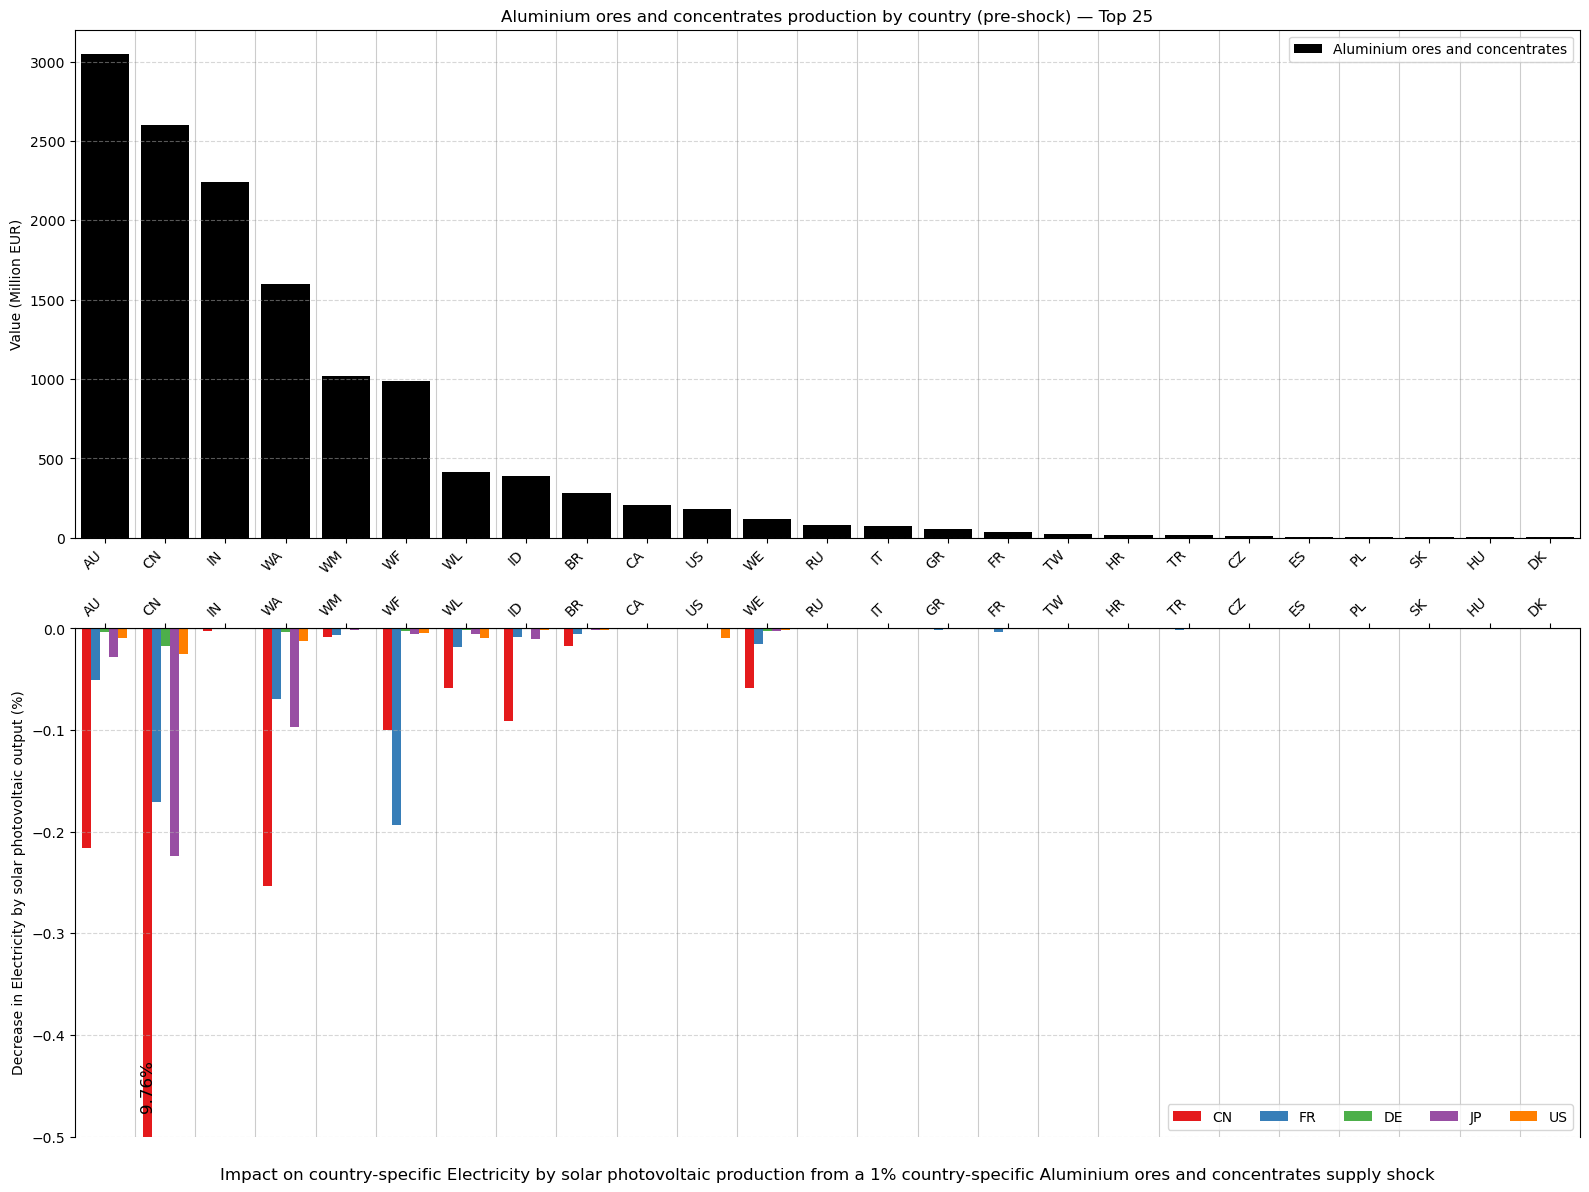

[Saved] ghosh_shocks_to_solar\Aluminium_ores_and_concentrates\grouped_top25_Aluminium_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Copper ores and concentrates
[Info] Top 25 producers of 'Copper ores and concentrates': ['CN', 'WL', 'AU', 'WM', 'WA', 'CA', 'MX', 'US', 'WF', 'PL', 'ID', 'RU', 'SE', 'BR', 'WE', 'BG', 'RO', 'ZA', 'FI', 'ES', 'IN', 'TR', 'TW', 'PT', 'BE']


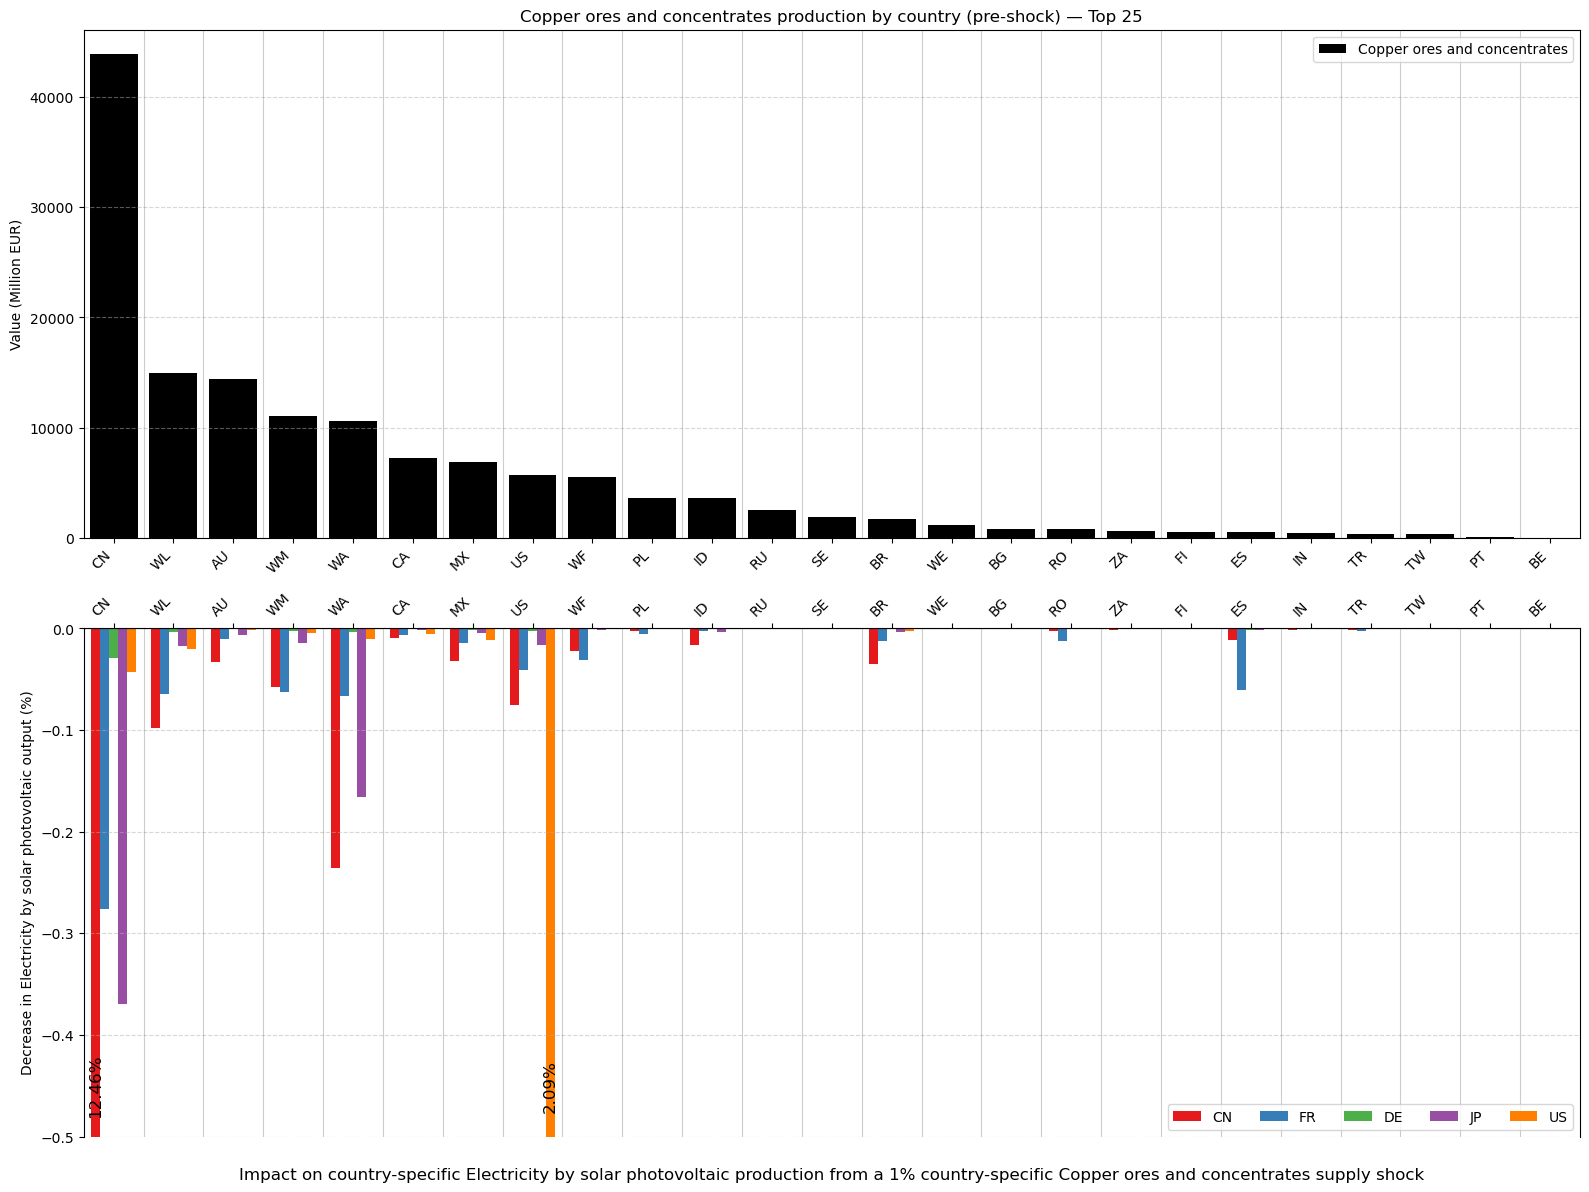

[Saved] ghosh_shocks_to_solar\Copper_ores_and_concentrates\grouped_top25_Copper_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Lead, zinc and tin ores and concentrates
[Info] Top 25 producers of 'Lead, zinc and tin ores and concentrates': ['CN', 'WA', 'AU', 'WM', 'ID', 'WF', 'WL', 'CA', 'RU', 'US', 'SE', 'WE', 'IN', 'BR', 'MX', 'DE', 'TW', 'RO', 'IE', 'PL', 'ZA', 'TR', 'PT', 'BG', 'FI']


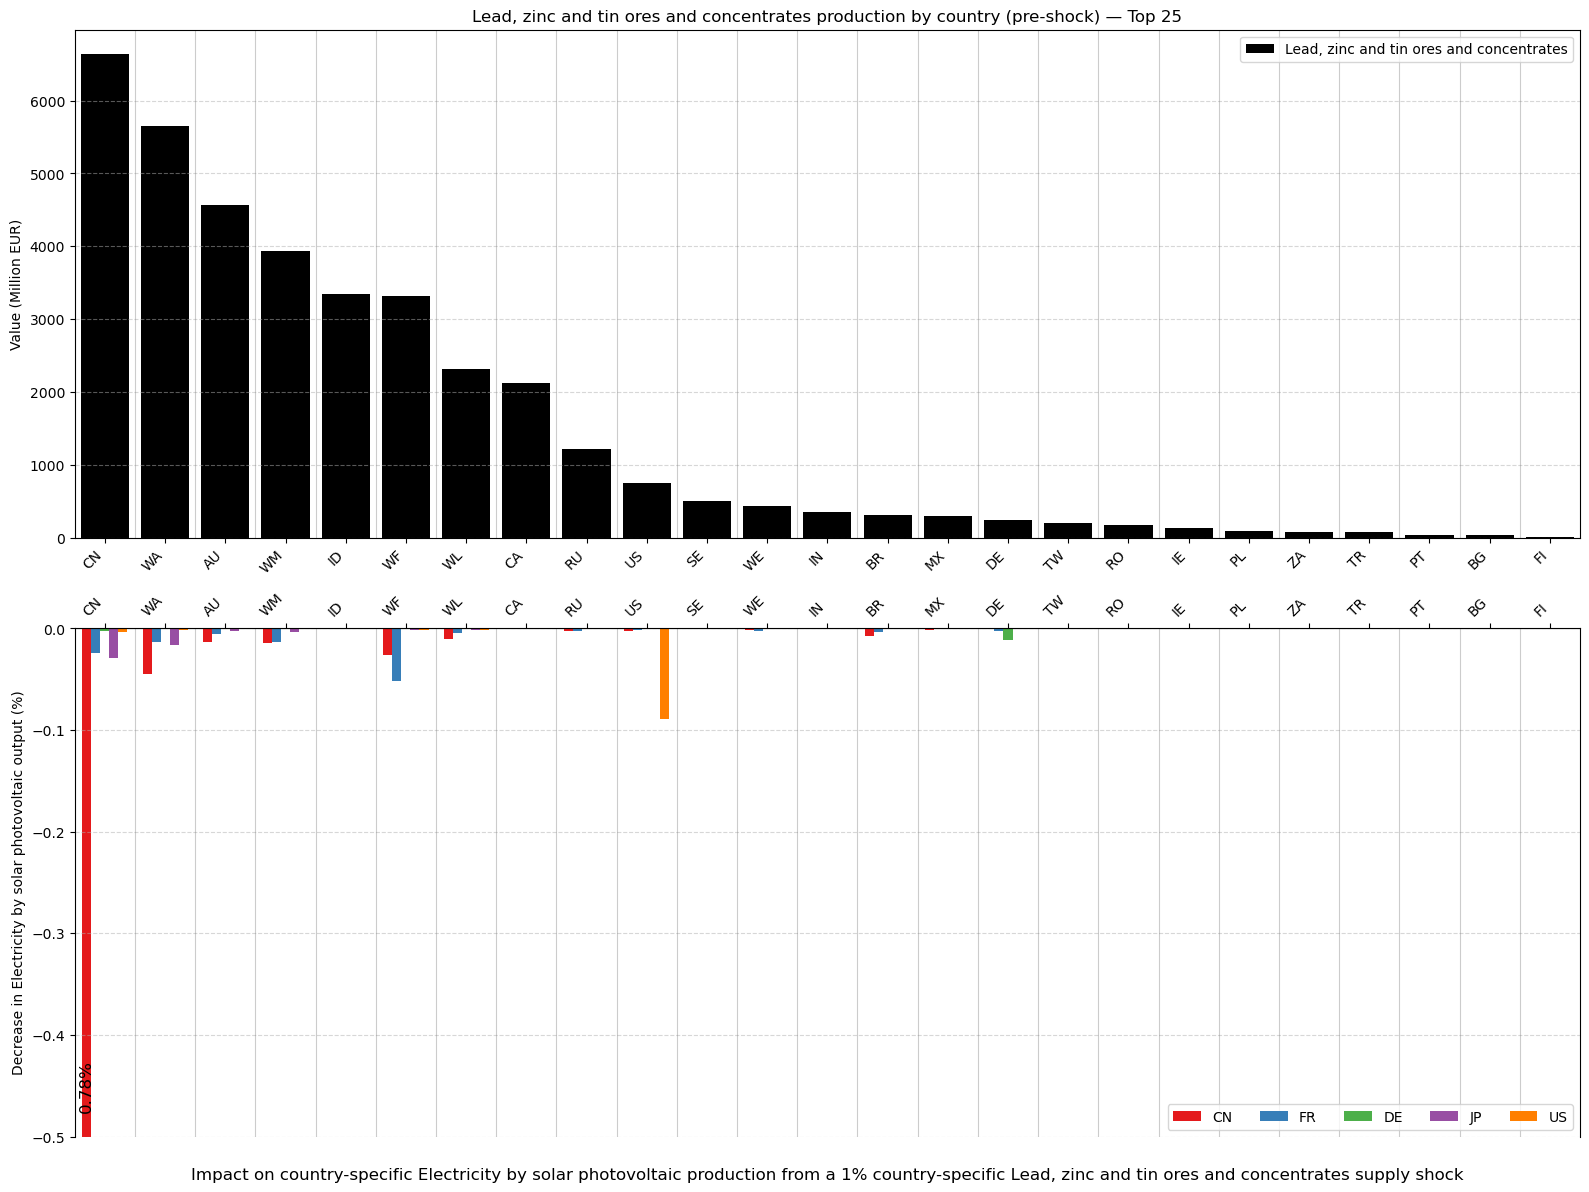

[Saved] ghosh_shocks_to_solar\Lead__zinc_and_tin_ores_and_concentrates\grouped_top25_Lead__zinc_and_tin_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Nickel ores and concentrates
[Info] Top 25 producers of 'Nickel ores and concentrates': ['CN', 'WA', 'ID', 'AU', 'WF', 'CA', 'BR', 'WL', 'RU', 'WE', 'ZA', 'WM', 'ES', 'GB', 'KR', 'SE', 'IE', 'FI', 'DE', 'CZ', 'SI', 'GR', 'MX', 'TR', 'RO']


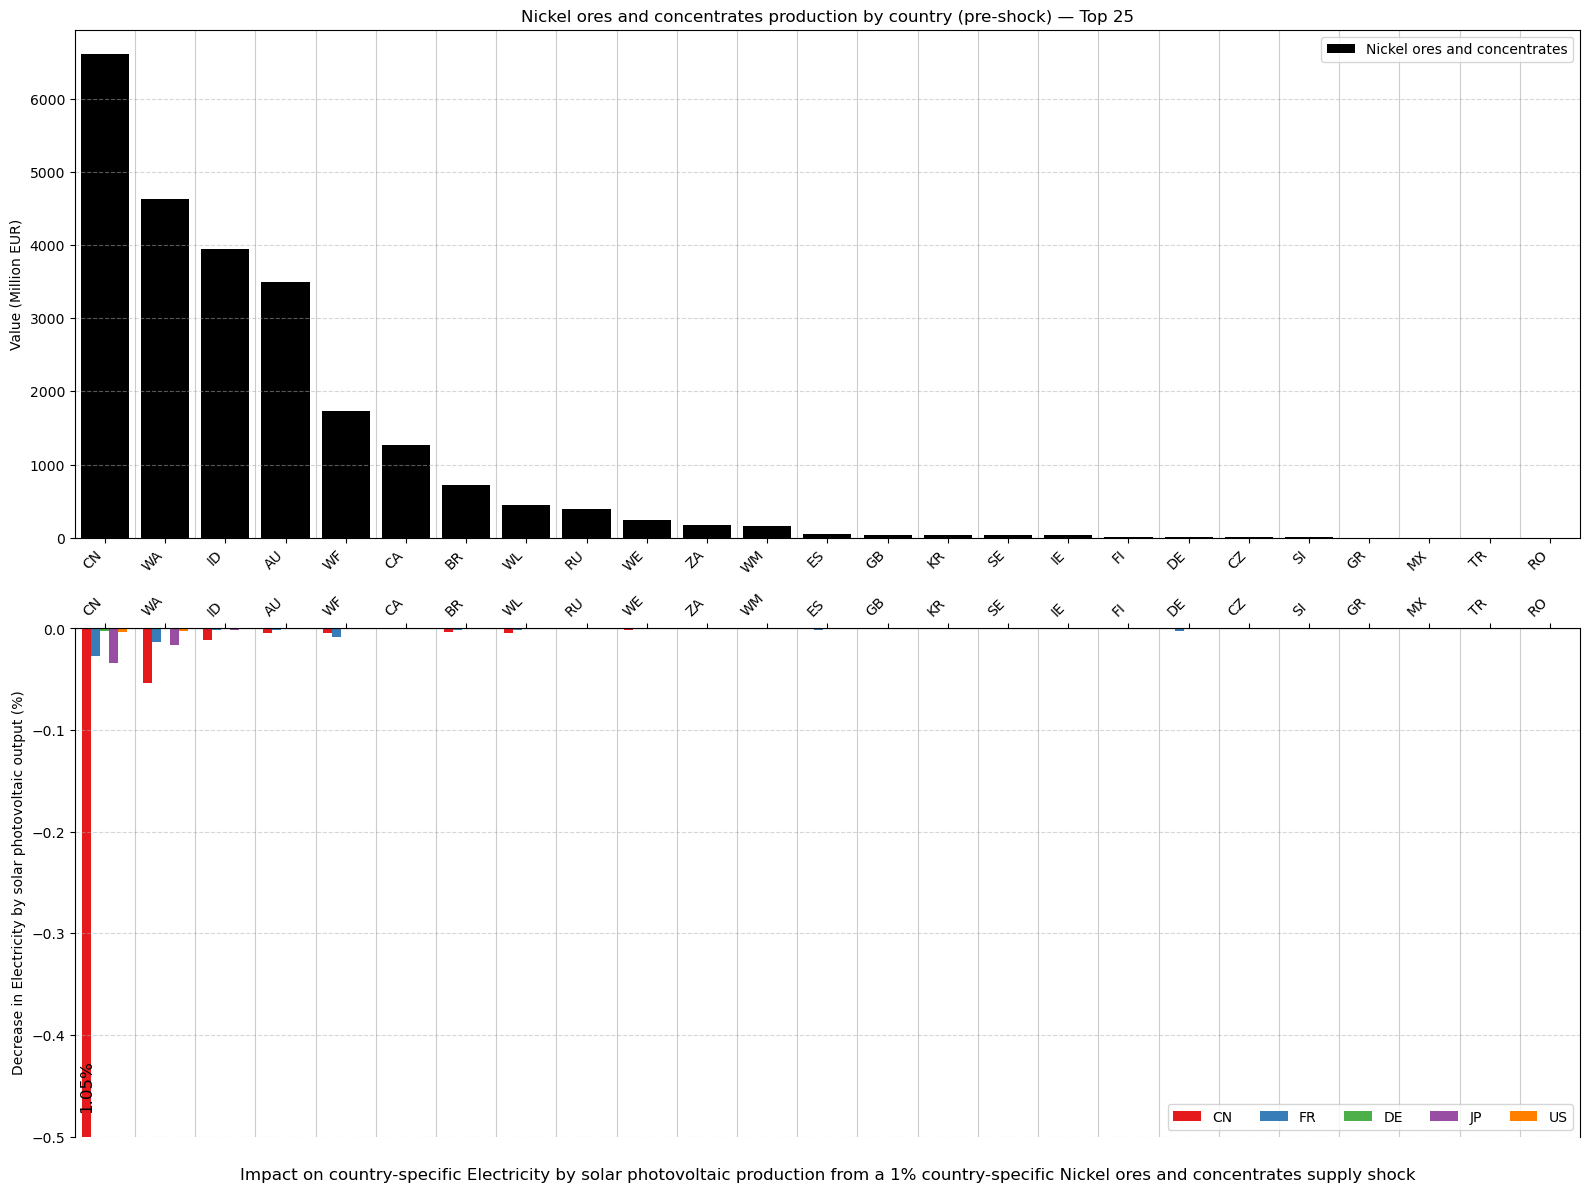

[Saved] ghosh_shocks_to_solar\Nickel_ores_and_concentrates\grouped_top25_Nickel_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Other non-ferrous metal ores and concentrates
[Info] Top 25 producers of 'Other non-ferrous metal ores and concentrates': ['CN', 'WA', 'AU', 'ZA', 'WM', 'WF', 'IN', 'WL', 'BR', 'BE', 'CA', 'RU', 'AT', 'US', 'TR', 'MX', 'RO', 'WE', 'NO', 'ES', 'JP', 'PT', 'SE', 'TW', 'FI']


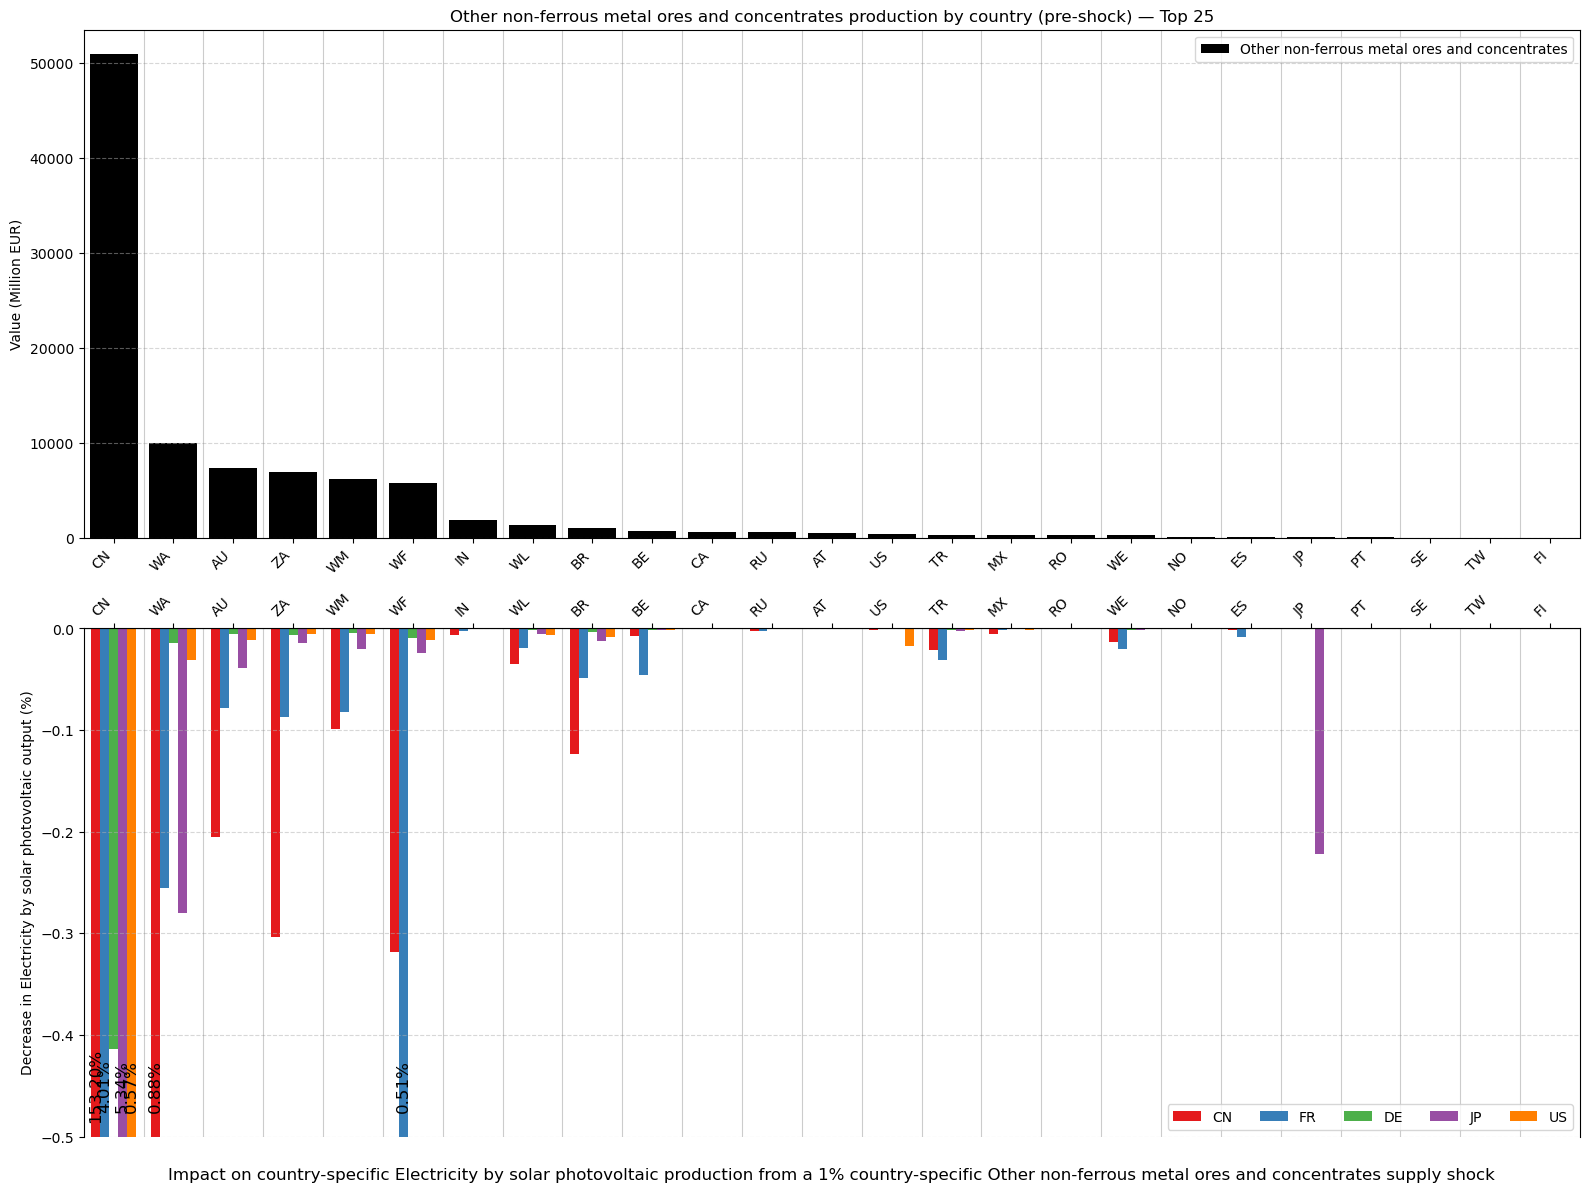

[Saved] ghosh_shocks_to_solar\Other_non-ferrous_metal_ores_and_concentrates\grouped_top25_Other_non-ferrous_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Precious metal ores and concentrates
[Info] Top 25 producers of 'Precious metal ores and concentrates': ['CN', 'AU', 'ZA', 'WM', 'MX', 'WA', 'US', 'WL', 'WF', 'RU', 'BR', 'ID', 'WE', 'CA', 'TR', 'JP', 'BG', 'RO', 'TW', 'IN', 'SE', 'PL', 'SK', 'FI', 'IE']


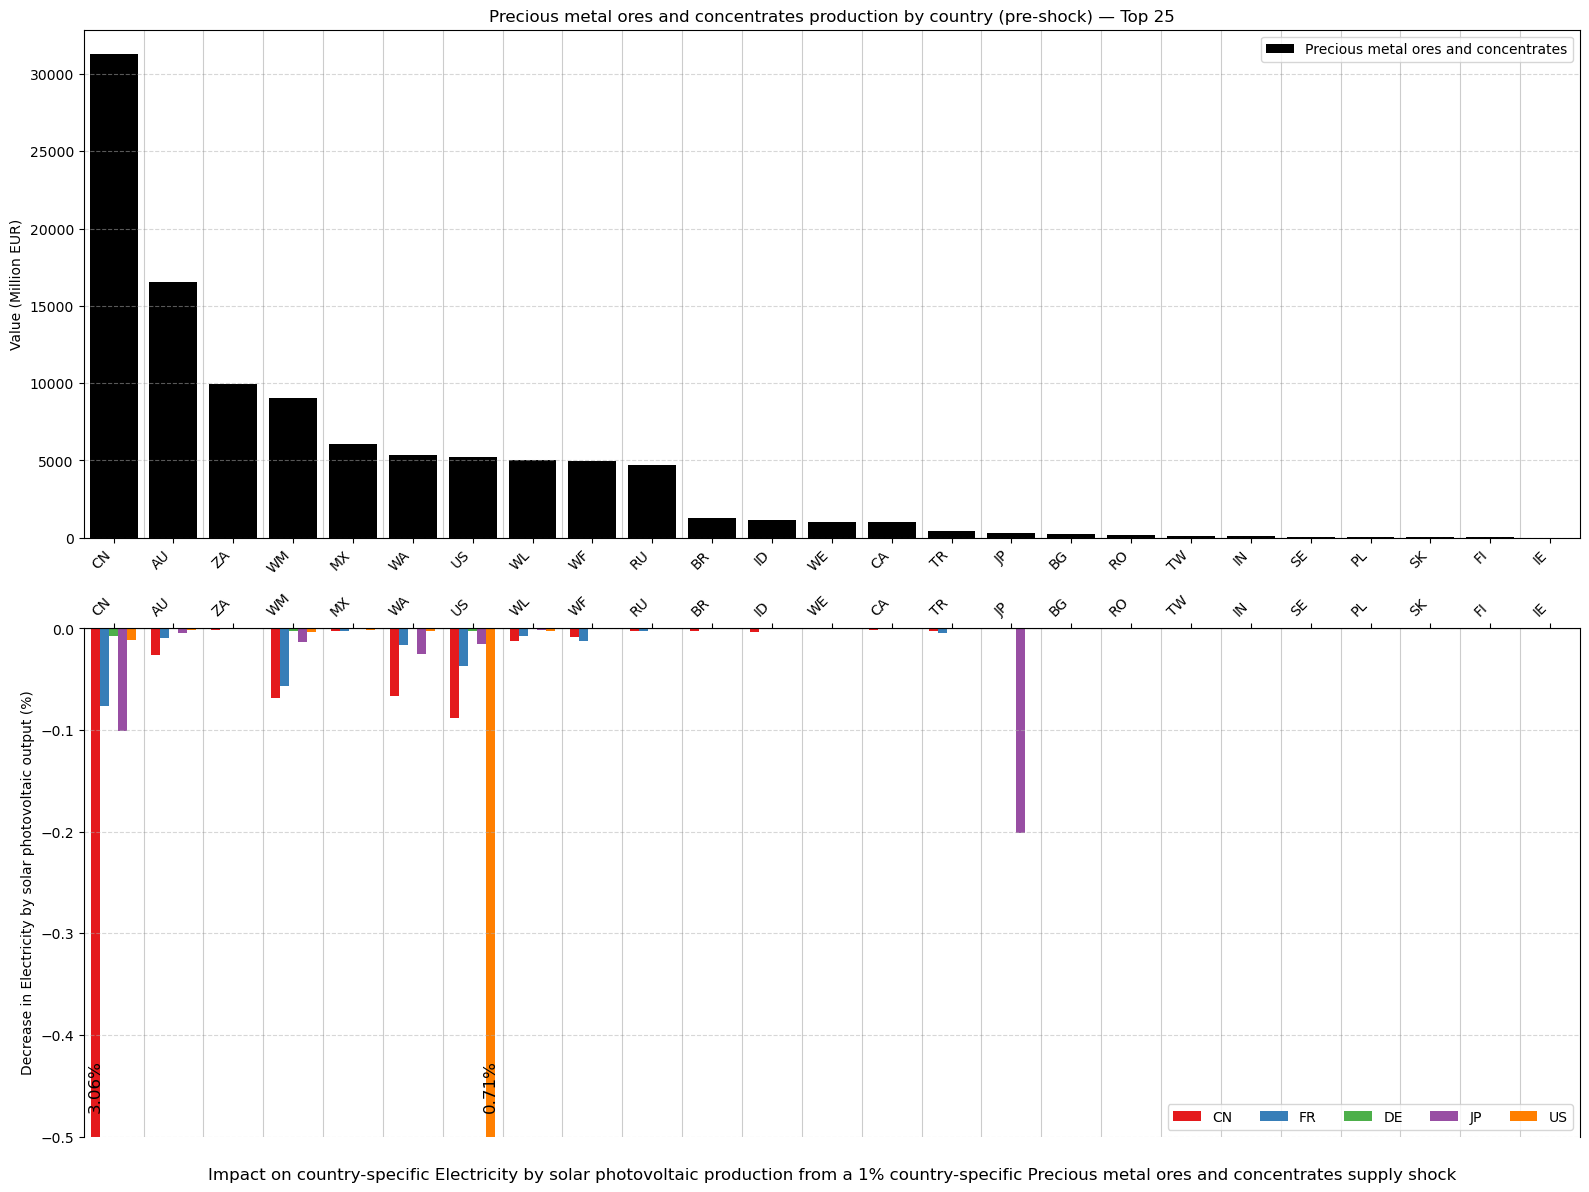

[Saved] ghosh_shocks_to_solar\Precious_metal_ores_and_concentrates\grouped_top25_Precious_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Aluminium and aluminium products
[Info] Top 25 producers of 'Aluminium and aluminium products': ['CN', 'US', 'DE', 'RU', 'JP', 'WA', 'AU', 'IN', 'CA', 'WM', 'IT', 'KR', 'GB', 'WL', 'ES', 'BR', 'WF', 'TW', 'FR', 'AT', 'NO', 'BE', 'PL', 'WE', 'CZ']


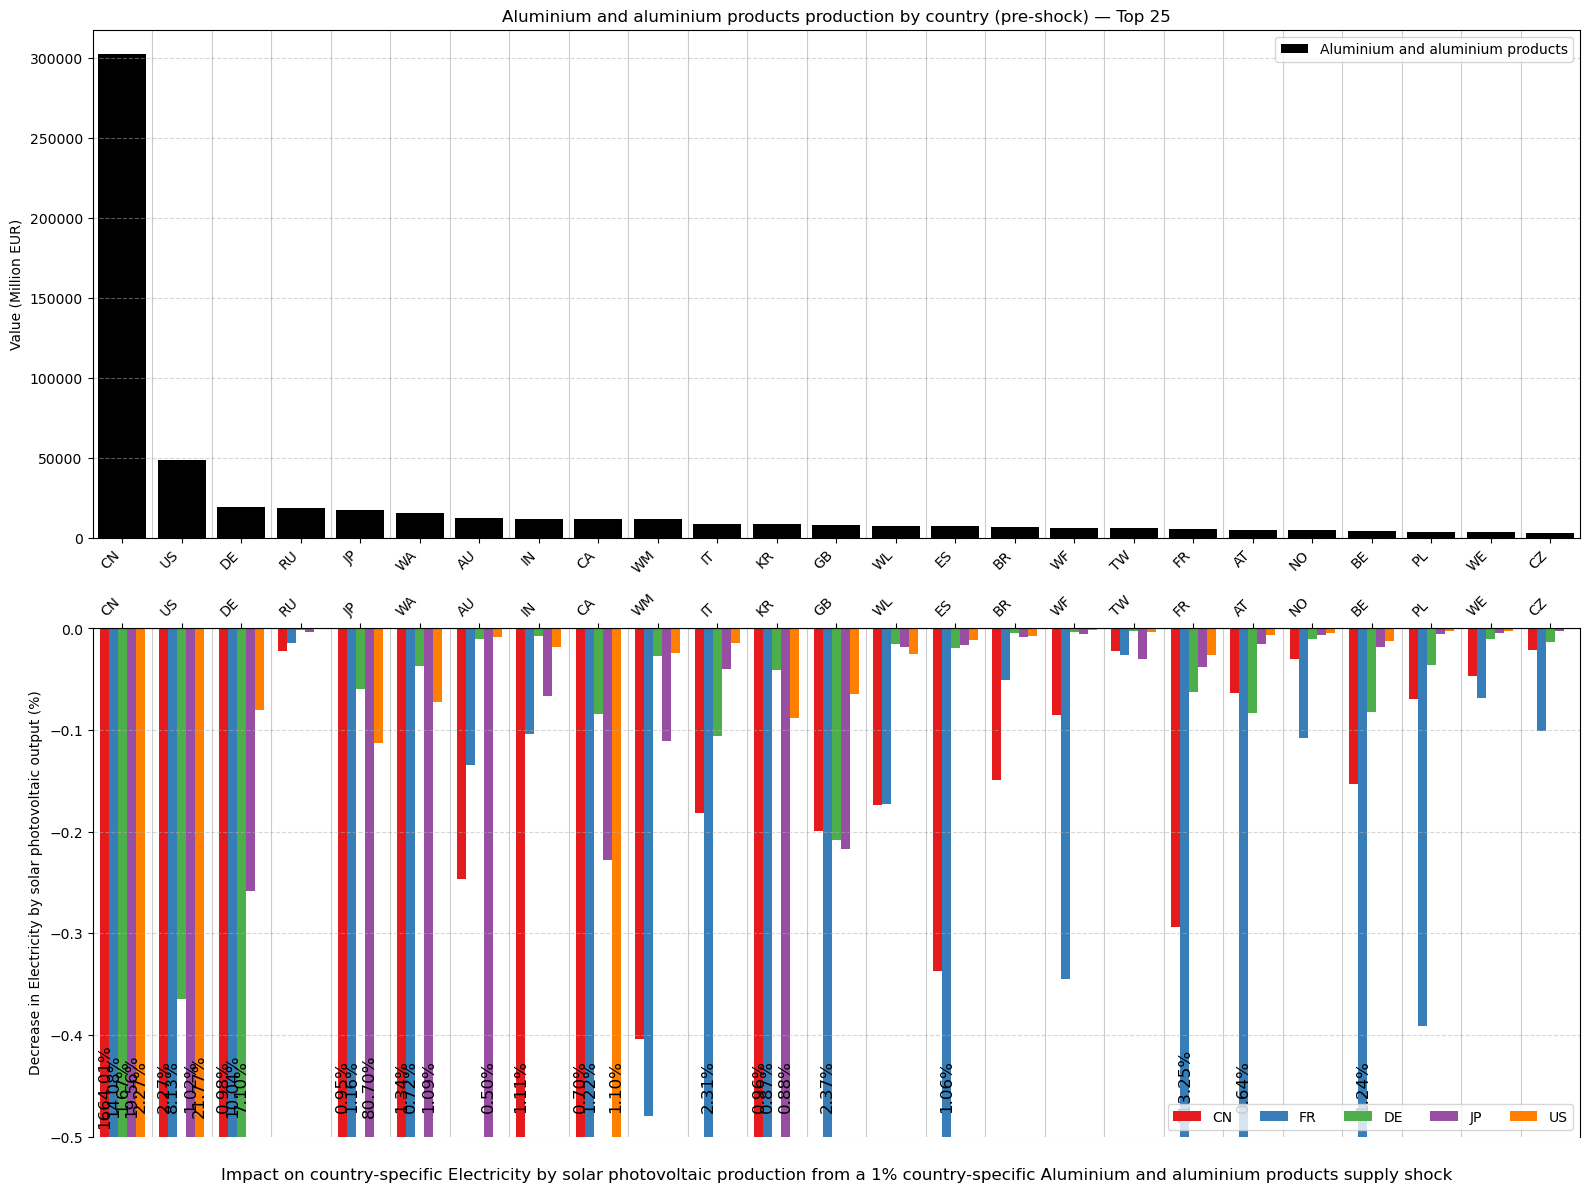

[Saved] ghosh_shocks_to_solar\Aluminium_and_aluminium_products\grouped_top25_Aluminium_and_aluminium_products_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Copper products
[Info] Top 25 producers of 'Copper products': ['CN', 'WL', 'US', 'KR', 'DE', 'IN', 'JP', 'BE', 'WA', 'RU', 'WM', 'MX', 'IT', 'FR', 'SE', 'AU', 'BG', 'ID', 'WF', 'CA', 'ES', 'GB', 'AT', 'TW', 'WE']


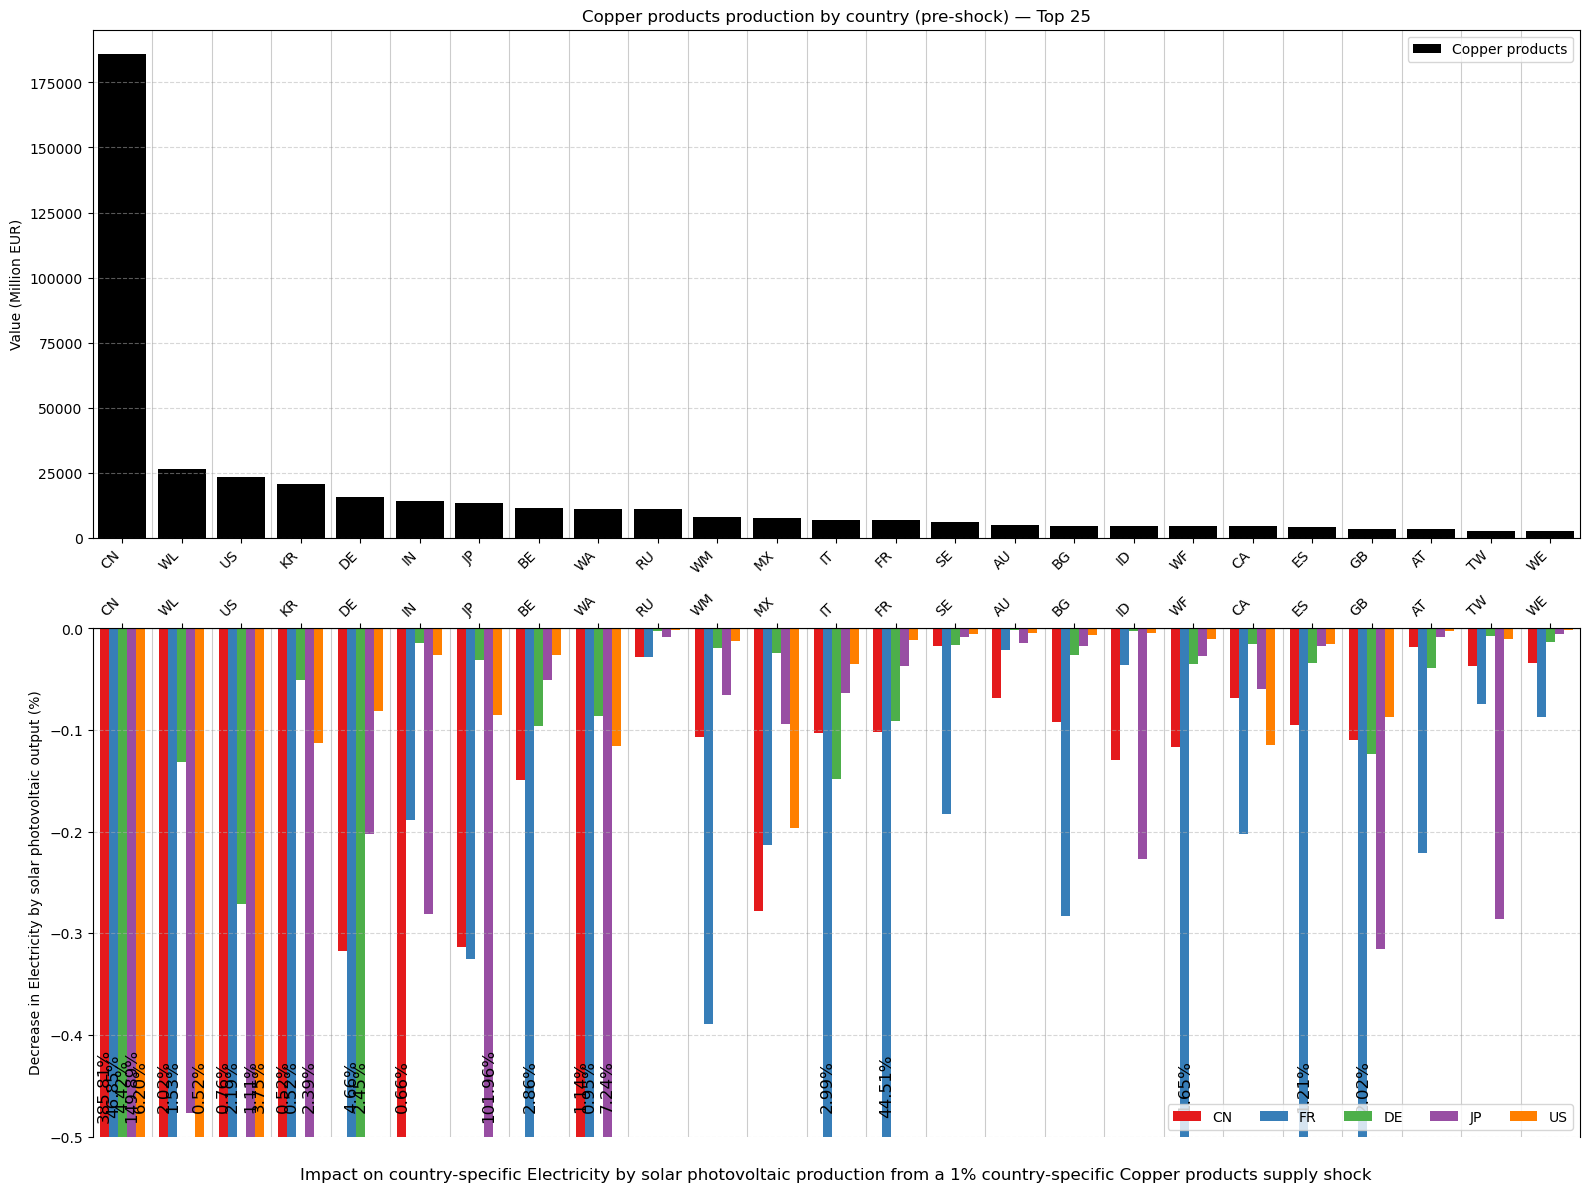

[Saved] ghosh_shocks_to_solar\Copper_products\grouped_top25_Copper_products_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Basic iron and steel and of ferro-alloys and first products thereof
[Info] Top 25 producers of 'Basic iron and steel and of ferro-alloys and first products thereof': ['CN', 'JP', 'KR', 'US', 'IN', 'WA', 'RU', 'TW', 'DE', 'WM', 'BR', 'IT', 'FR', 'ES', 'CA', 'WL', 'TR', 'MX', 'WF', 'PL', 'AU', 'ZA', 'WE', 'GB', 'ID']


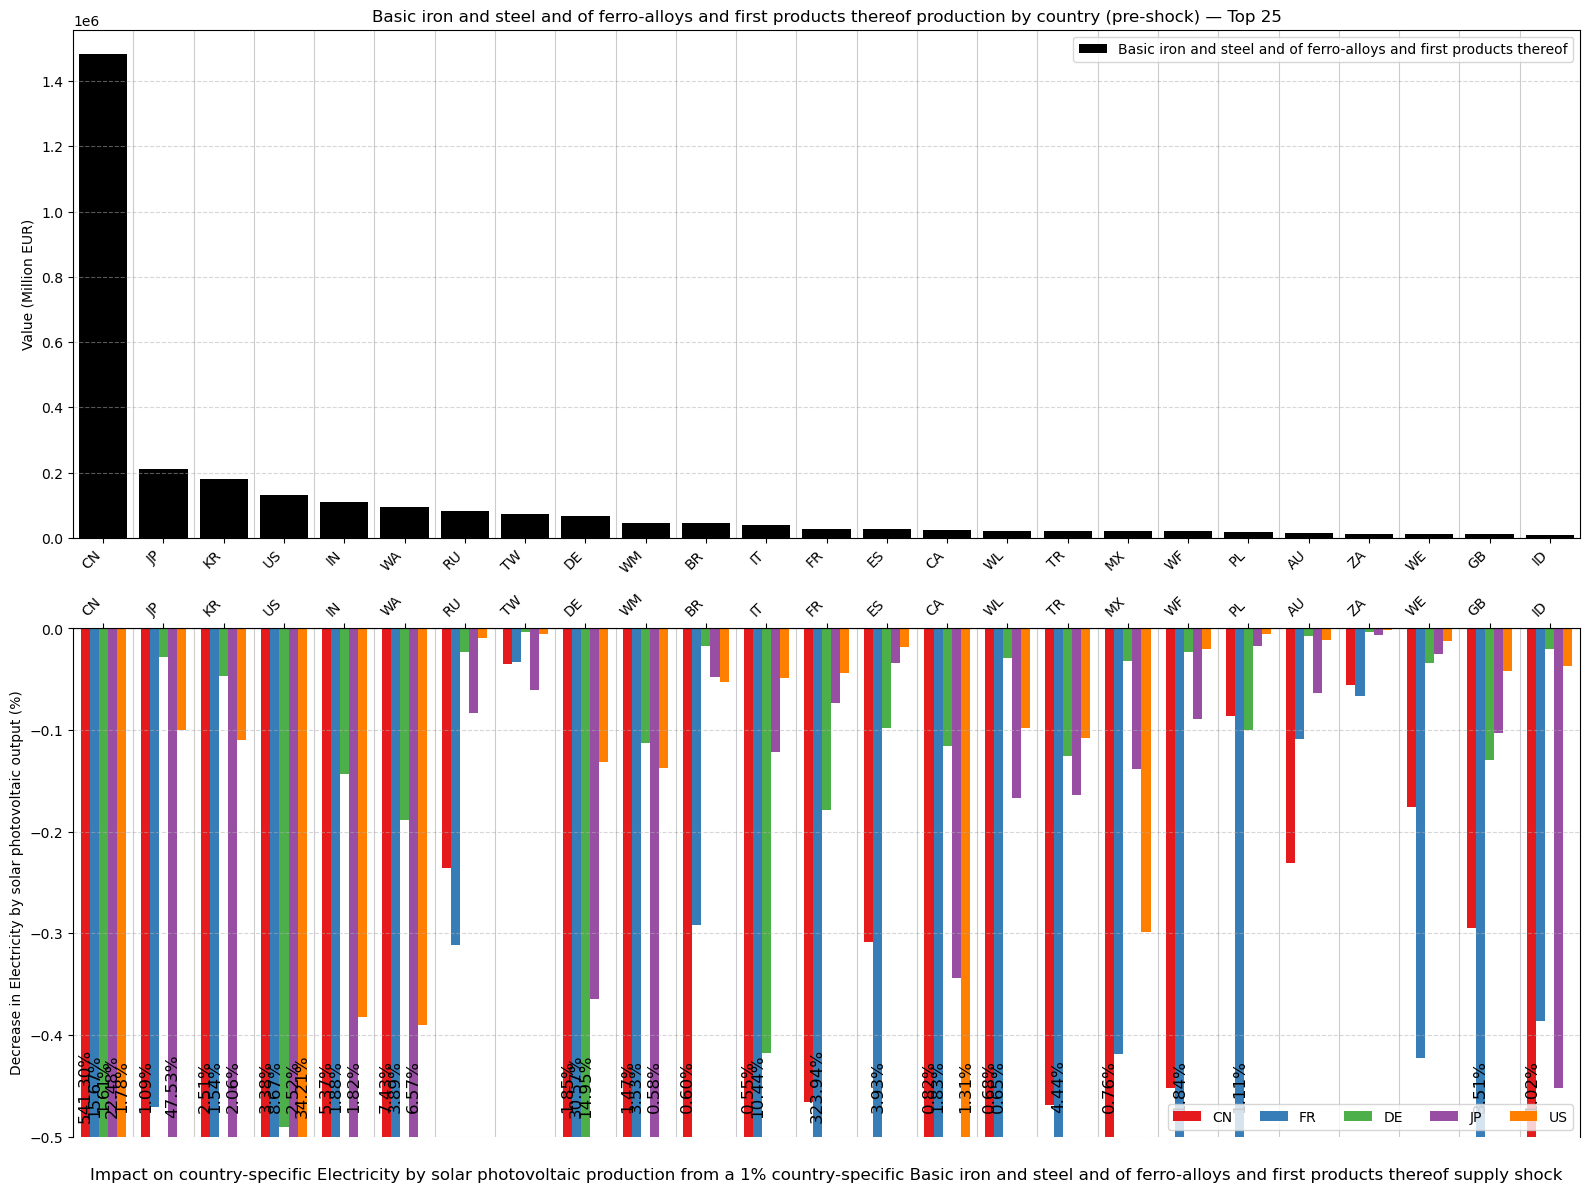

[Saved] ghosh_shocks_to_solar\Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof\grouped_top25_Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Lead, zinc and tin and products thereof
[Info] Top 25 producers of 'Lead, zinc and tin and products thereof': ['CN', 'KR', 'WA', 'MX', 'IN', 'DE', 'WM', 'AU', 'JP', 'CA', 'GB', 'ID', 'WL', 'IT', 'WF', 'PL', 'US', 'RO', 'TW', 'RU', 'SE', 'BG', 'WE', 'FI', 'ES']


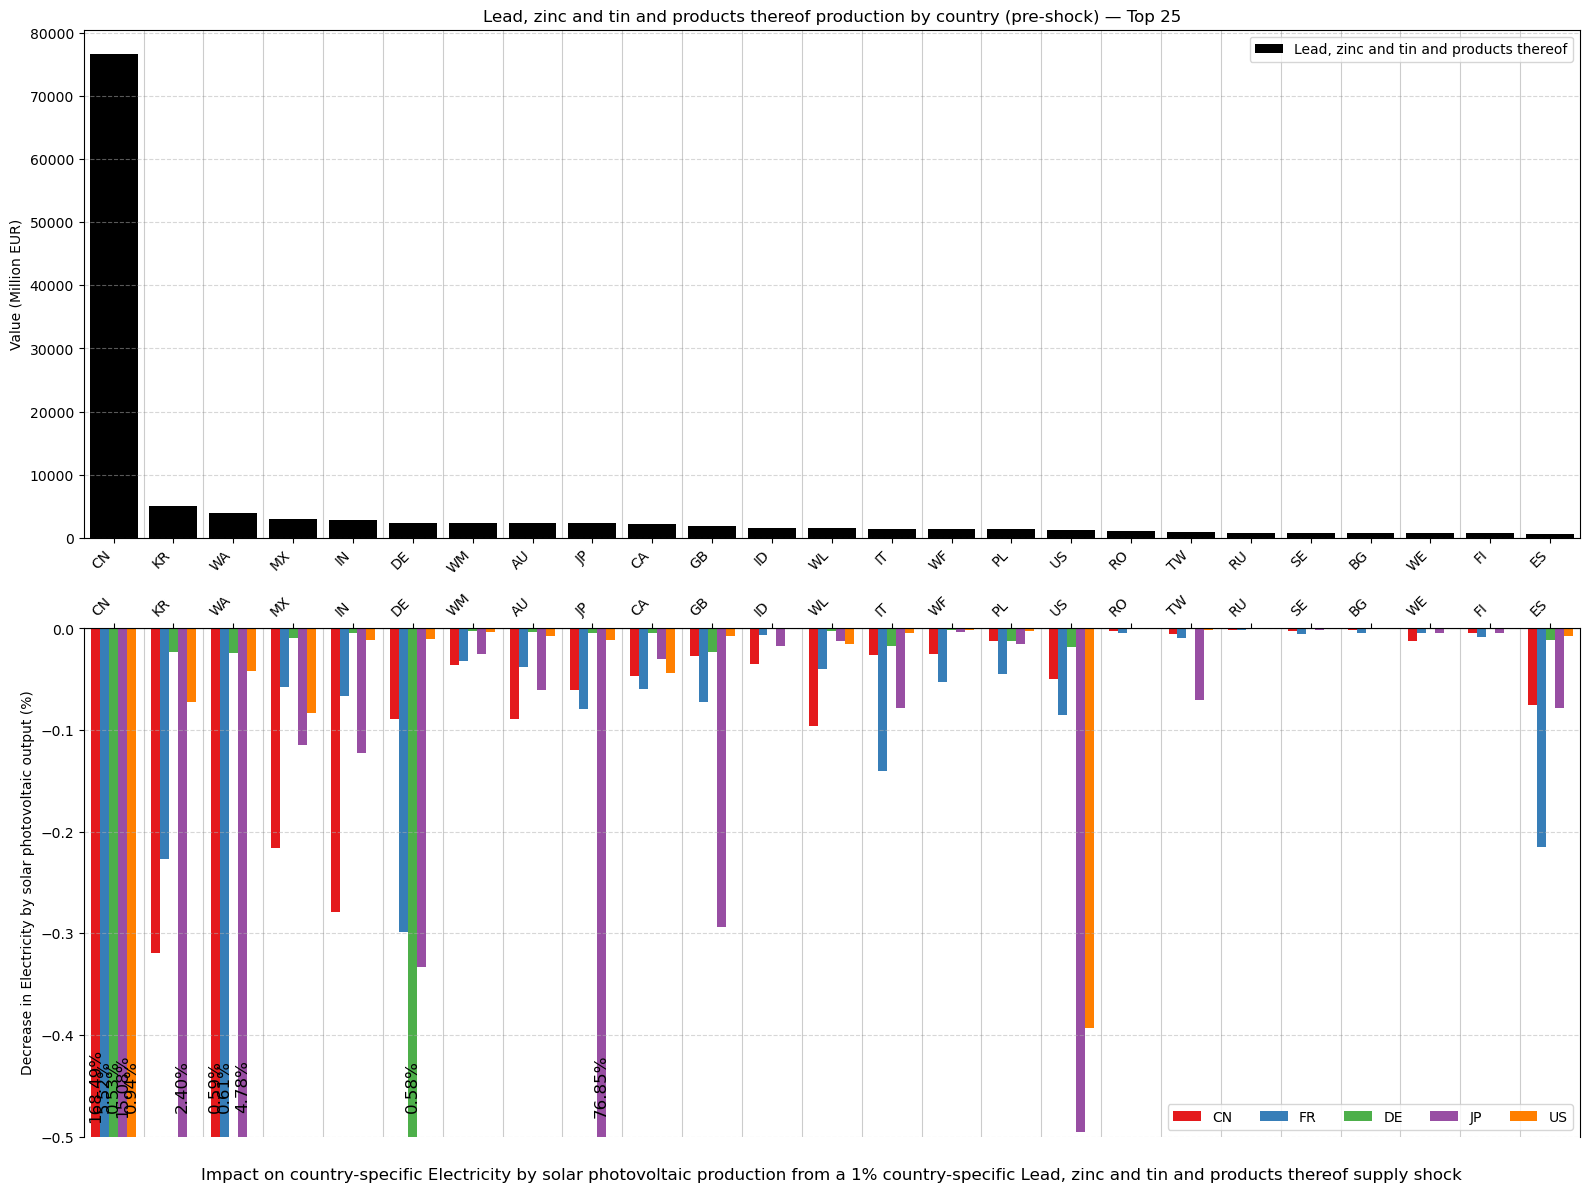

[Saved] ghosh_shocks_to_solar\Lead__zinc_and_tin_and_products_thereof\grouped_top25_Lead__zinc_and_tin_and_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Other non-ferrous metal products
[Info] Top 25 producers of 'Other non-ferrous metal products': ['CN', 'RU', 'WA', 'JP', 'AU', 'US', 'CA', 'WM', 'WF', 'ID', 'DE', 'WL', 'TW', 'AT', 'KR', 'NO', 'GB', 'FI', 'WE', 'BR', 'BE', 'NL', 'IN', 'MX', 'ZA']


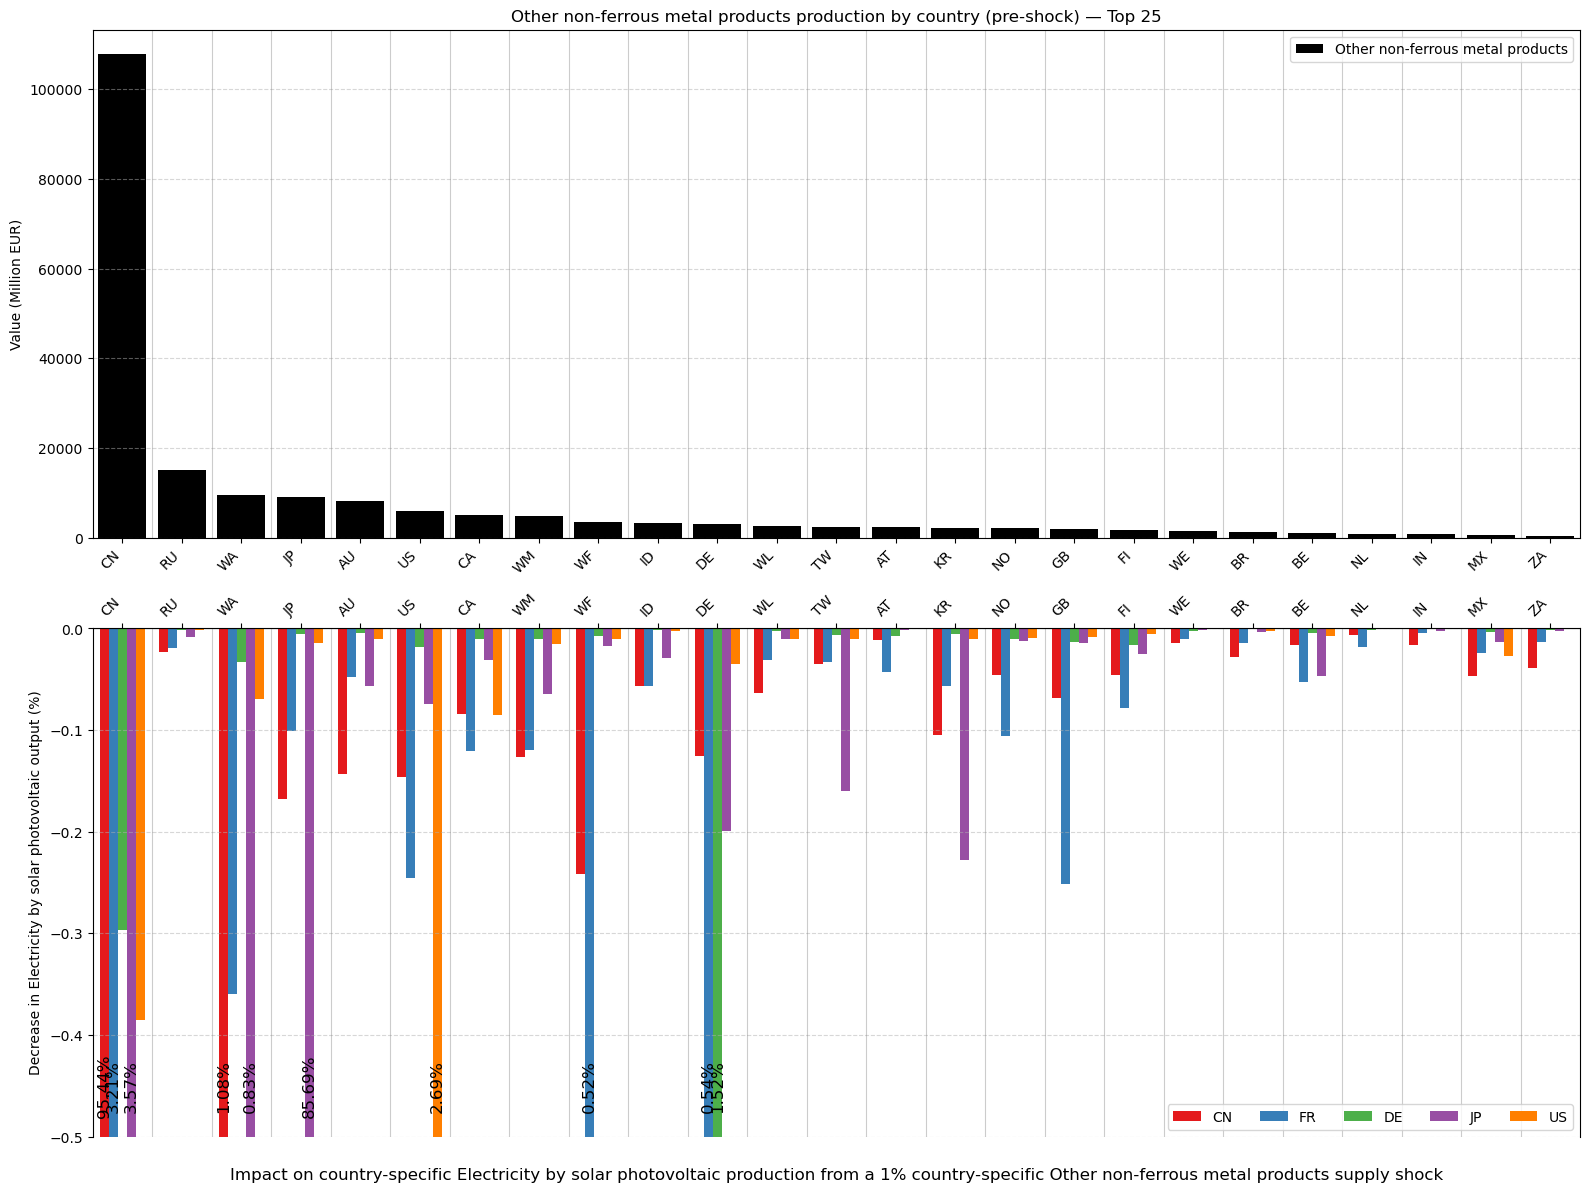

[Saved] ghosh_shocks_to_solar\Other_non-ferrous_metal_products\grouped_top25_Other_non-ferrous_metal_products_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Precious metals
[Info] Top 25 producers of 'Precious metals': ['CN', 'US', 'AU', 'IN', 'MX', 'RU', 'BE', 'CH', 'WA', 'KR', 'IT', 'WL', 'WM', 'ZA', 'WF', 'PL', 'JP', 'DE', 'TR', 'BR', 'GB', 'TW', 'WE', 'CA', 'NL']


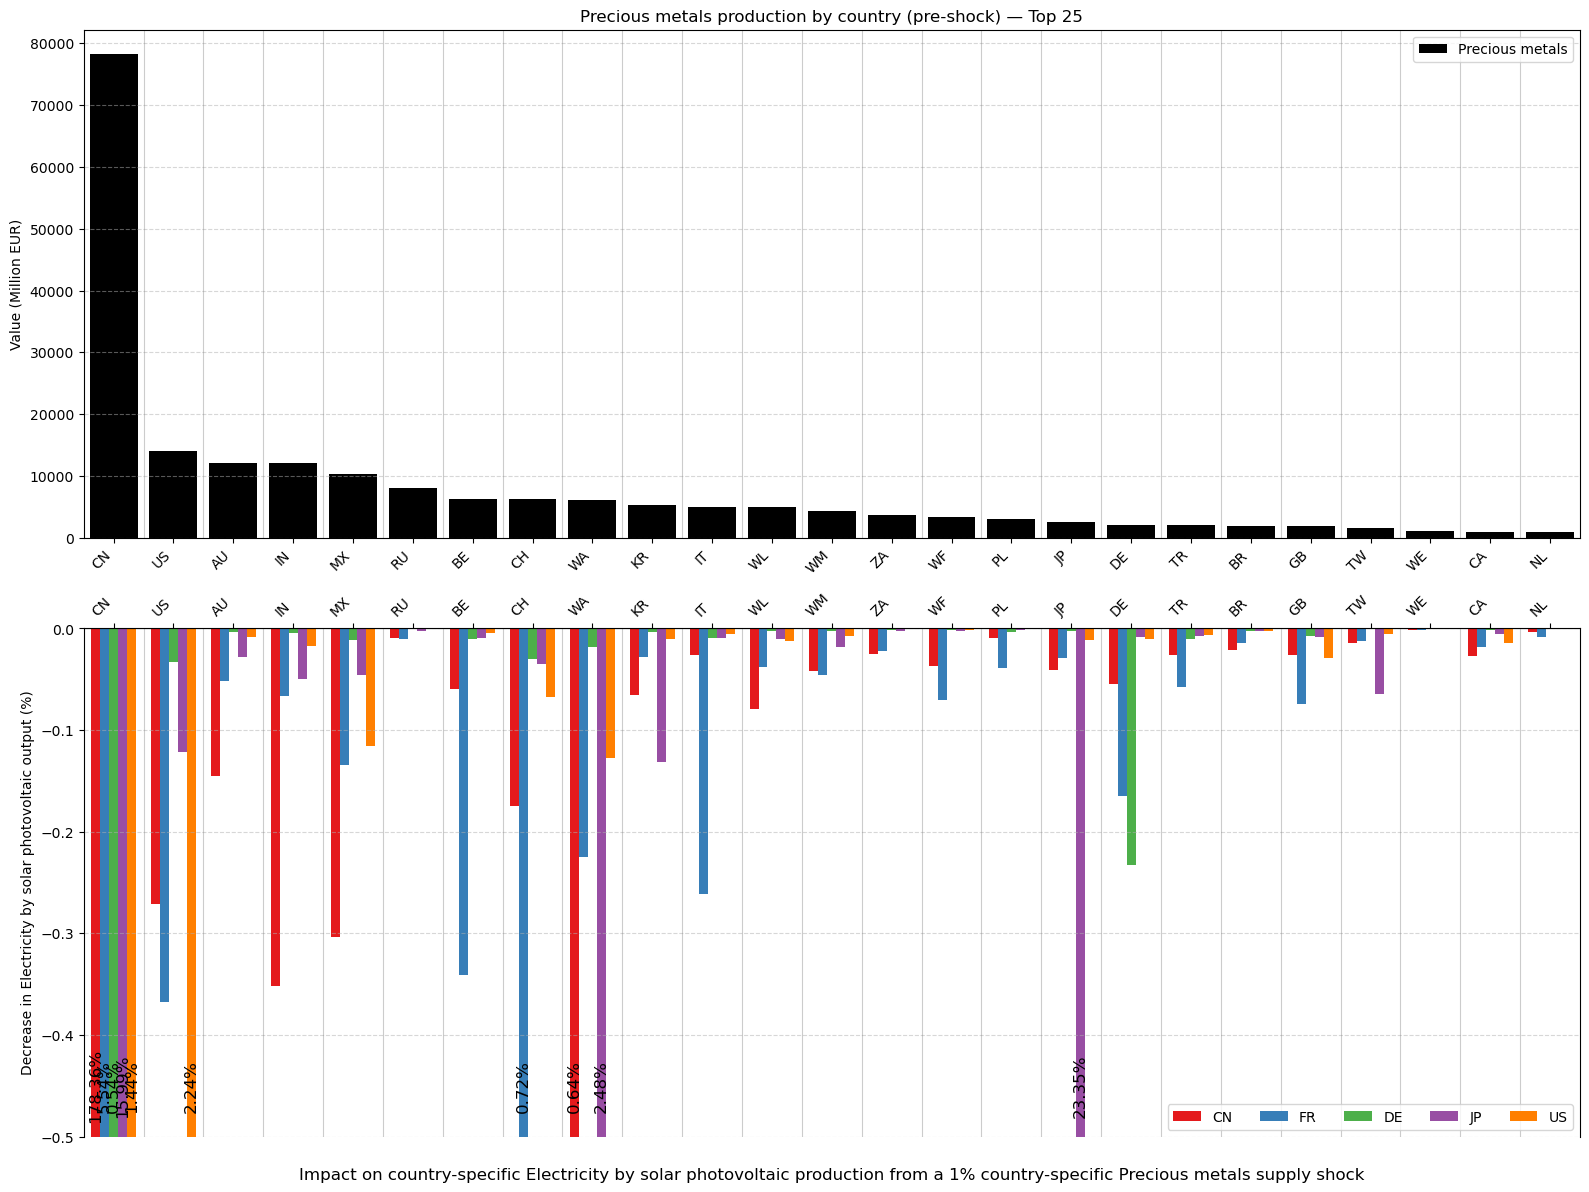

[Saved] ghosh_shocks_to_solar\Precious_metals\grouped_top25_Precious_metals_to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Electrical machinery and apparatus n.e.c. (31)
[Info] Top 25 producers of 'Electrical machinery and apparatus n.e.c. (31)': ['CN', 'JP', 'US', 'DE', 'IN', 'KR', 'WA', 'IT', 'FR', 'WM', 'MX', 'ES', 'TW', 'GB', 'WF', 'WL', 'PL', 'AU', 'CH', 'BR', 'ID', 'CZ', 'DK', 'TR', 'AT']


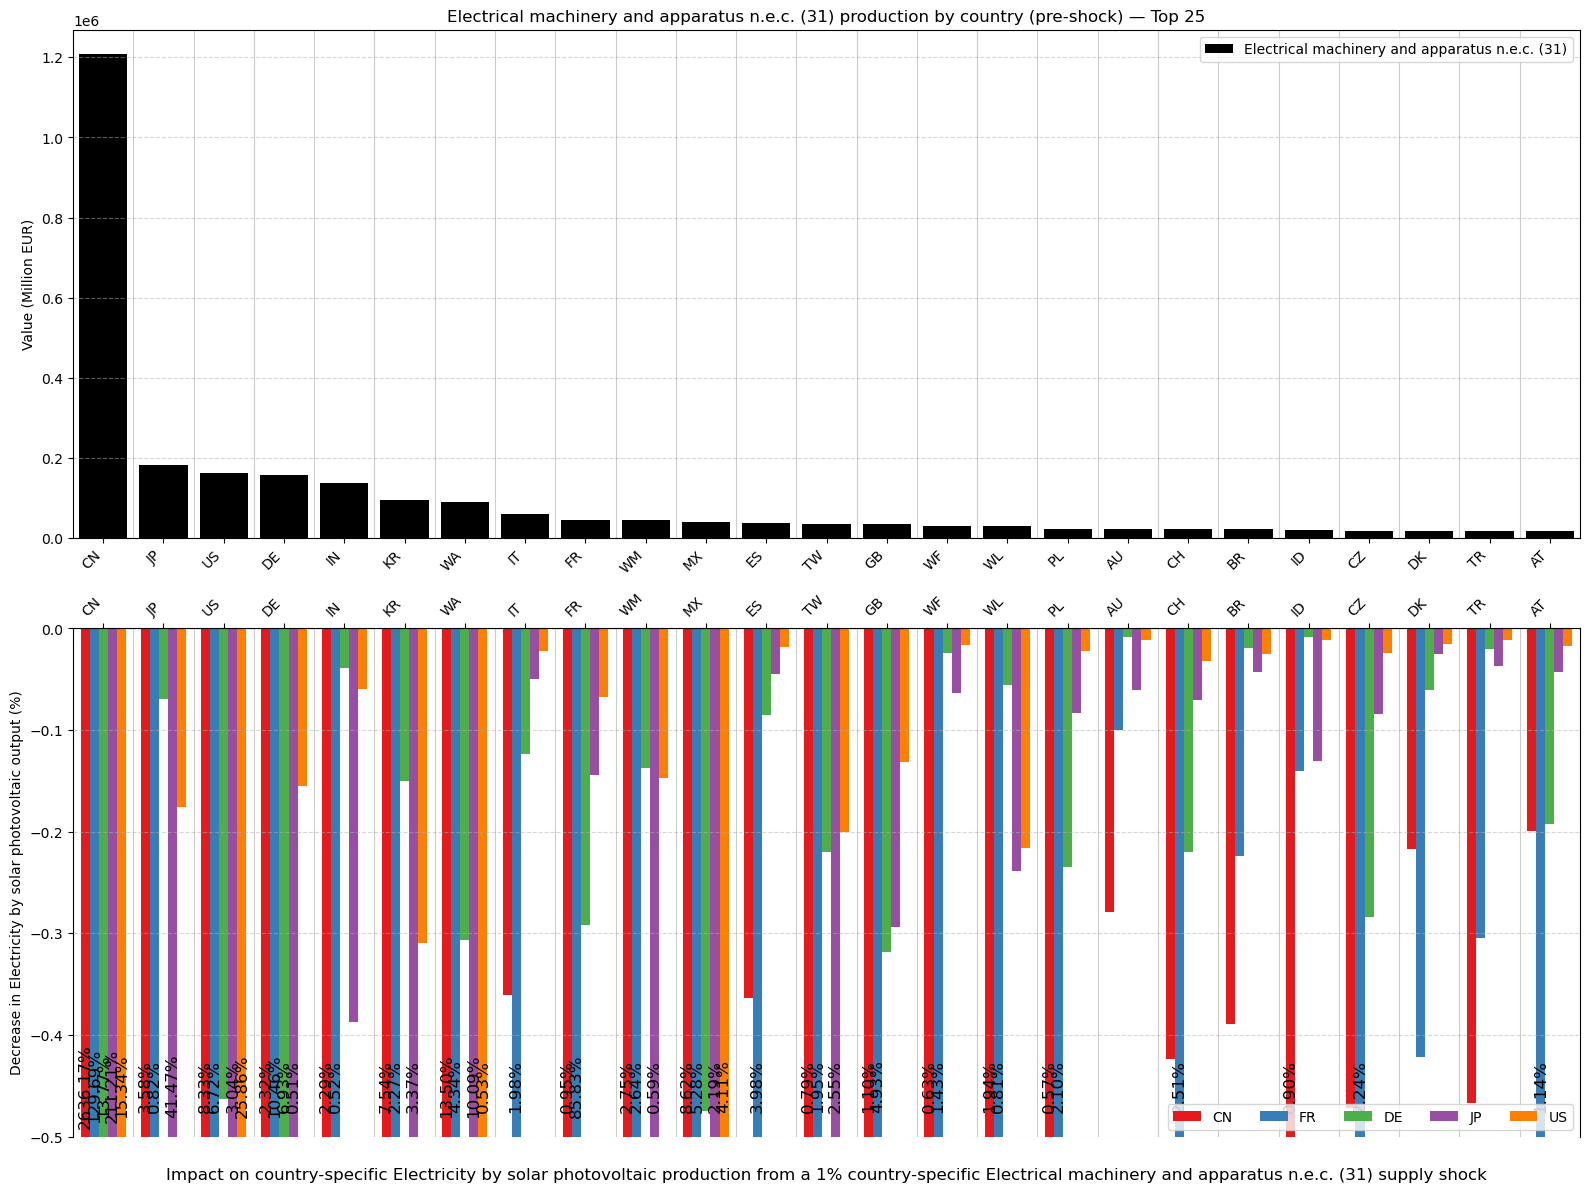

[Saved] ghosh_shocks_to_solar\Electrical_machinery_and_apparatus_n.e.c.__31_\grouped_top25_Electrical_machinery_and_apparatus_n.e.c.__31__to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Fabricated metal products, except machinery and equipment (28)
[Info] Top 25 producers of 'Fabricated metal products, except machinery and equipment (28)': ['CN', 'US', 'DE', 'JP', 'IN', 'IT', 'WA', 'KR', 'RU', 'WM', 'FR', 'WL', 'ES', 'GB', 'TW', 'PL', 'BR', 'WF', 'NL', 'ID', 'MX', 'CH', 'CA', 'CZ', 'TR']


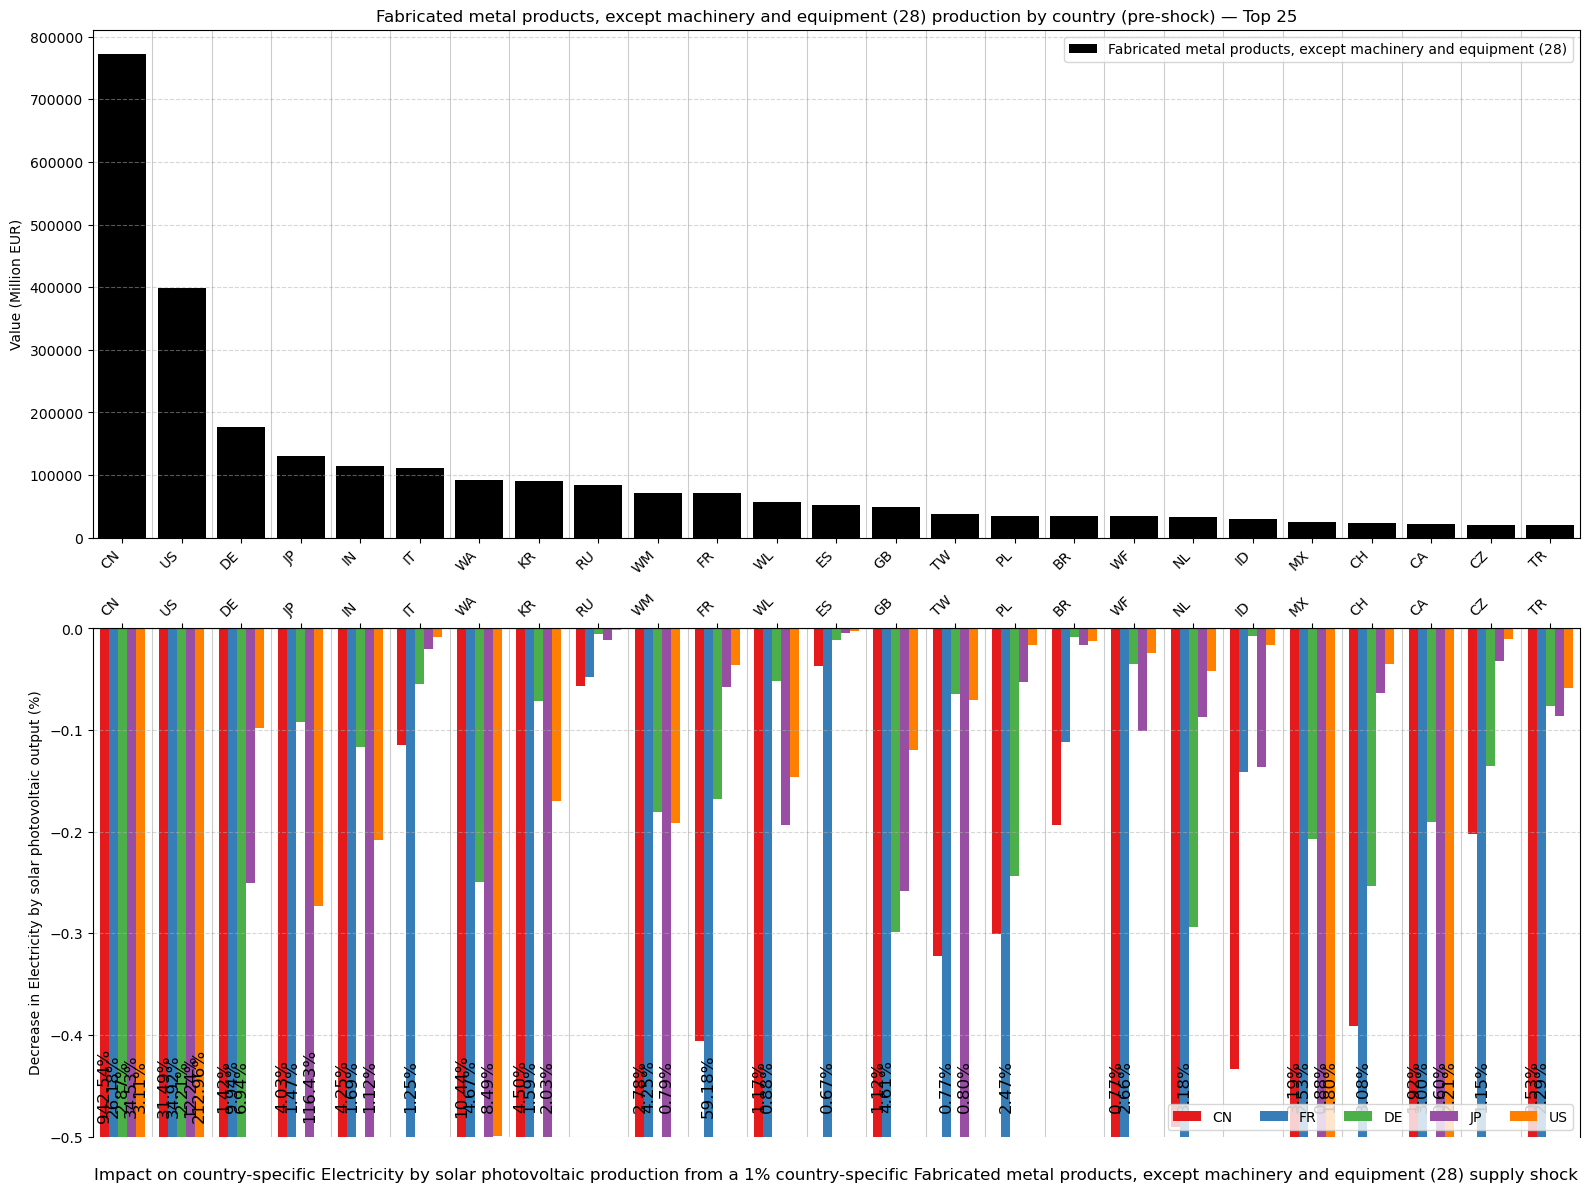

[Saved] ghosh_shocks_to_solar\Fabricated_metal_products__except_machinery_and_equipment__28_\grouped_top25_Fabricated_metal_products__except_machinery_and_equipment__28__to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png

[Run] Shock industry -> Machinery and equipment n.e.c. (29)
[Info] Top 25 producers of 'Machinery and equipment n.e.c. (29)': ['CN', 'US', 'JP', 'DE', 'WA', 'IN', 'KR', 'IT', 'WM', 'WL', 'FR', 'GB', 'WF', 'TW', 'BR', 'RU', 'CA', 'ES', 'NL', 'CH', 'AT', 'MX', 'SE', 'TR', 'PL']


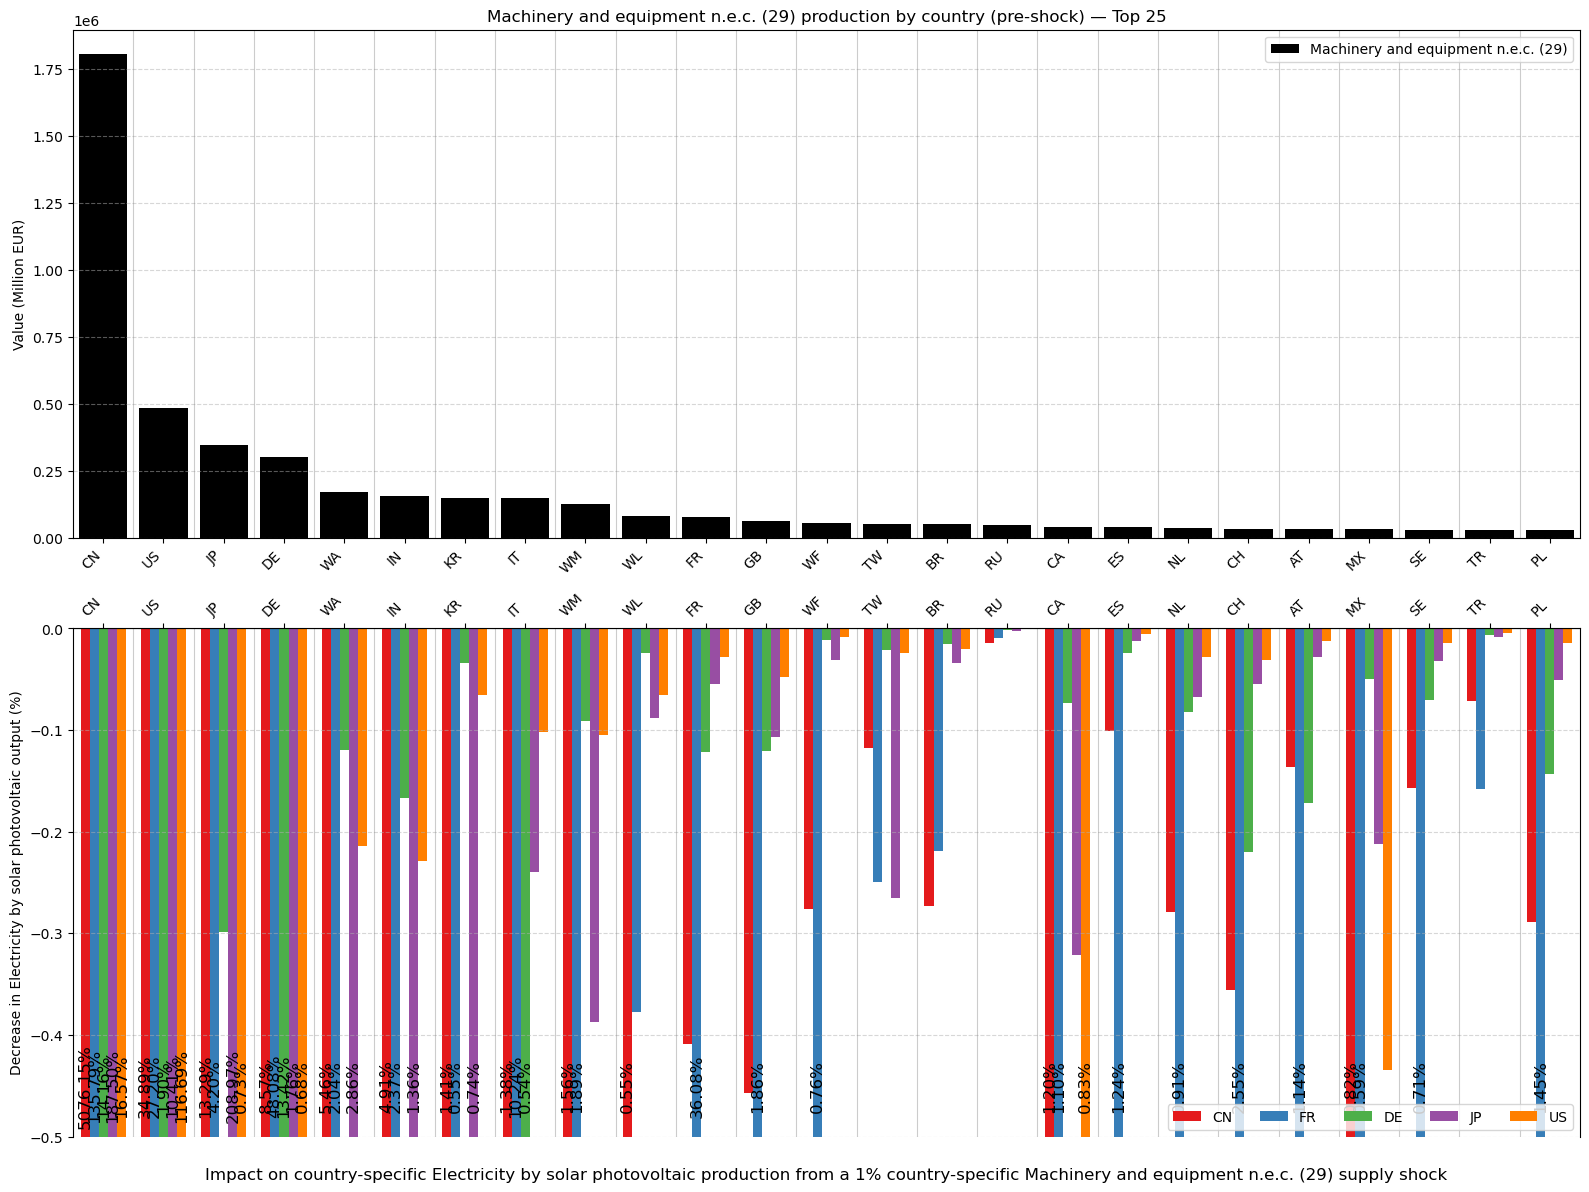

[Saved] ghosh_shocks_to_solar\Machinery_and_equipment_n.e.c.__29_\grouped_top25_Machinery_and_equipment_n.e.c.__29__to_Electricity_by_solar_photovoltaic_ghosh_1pct_20251218_0947.png


In [5]:
# ------------------ Helper: safe filenames ------------------
def safe_slug(s):
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(s))

# ------------------ Config ------------------
# Shock size (country-specific)
try:
    shock_pct
except NameError:
    shock_pct = 0.01  # 1% cut in the shocked industry's supply in each top-N country

# Target industry is Solar PV electricity
target_industry_substrings = ("electricity", "solar", "photovoltaic")

# Countries to show in grouped bars (bottom panel)
target_countries = ["CN", "FR", "DE", "JP", "US"]

# Show top-N producers of the shocked industry
TOP_N = 25

# Colors per target country
country_colors = {
    "CN": "#e41a1c",
    "FR": "#377eb8",
    "DE": "#4daf4a",
    "JP": "#984ea3",
    "US": "#ff7f00",
}

# Base output folder & timestamp
out_dir_base = "ghosh_shocks_to_solar"
os.makedirs(out_dir_base, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M")

# ------------------ Build SHOCK_INDUSTRIES from your categories ------------------
# We resolve these using robust substring matching via your find_industry_name helper,
# with a fallback to direct substring search on column labels.
industry_candidates = [
    # Primary
    ("Aluminium Ore", ("alum", "ore")),
    ("Copper Ore", ("copper", "ore")),
    ("Lead, Zinc & Tin Ore", ("lead", "zinc", "tin", "ore")),
    ("Nickel", ("nickel", "ore")),
    ("Other Non-Ferrous Metal Ore", ("non-ferrous", "ore")),
    ("Precious Metal Ore", ("precious", "metal", "ore")),
    # Secondary
    ("Aluminium Products", ("alum", "product")),
    ("Copper Products", ("copper", "product")),
    ("Basic Iron, Steel & Ferro-Alloy Products", ("iron", "steel", "ferro")),
    ("Lead, Zinc & Tin Products", ("lead", "zinc", "tin", "product")),
    ("Other Non-Ferrous Mineral Products", ("non-ferrous", "product")),
    ("Precious Metal Products", ("precious", "metals")),
    # Tertiary
    ("Electrical Machinery and Apparatus", ("electrical", "machinery", "apparatus")),
    ("Fabricated Metal Products", ("fabricated", "metal", "product")),
    ("Machinery and Equipment", ("machinery", "equipment", "n.e.c.")),
]

SHOCK_INDUSTRIES = []
not_found = []

# Column labels list for fallback search
if isinstance(A_df.columns, pd.MultiIndex):
    col_labels = A_df.columns.get_level_values(1)  # Industry level
else:
    col_labels = A_df.columns

for display_name, substrings in industry_candidates:
    resolved = None
    # Try your helper first
    try:
        resolved = find_industry_name(A_df.columns, industry_substrings=substrings)
    except Exception:
        resolved = None

    # Fallback: simple substring AND match
    if resolved is None:
        matches = [c for c in col_labels if all(s.lower() in str(c).lower() for s in substrings)]
        resolved = matches[0] if matches else None

    if resolved:
        SHOCK_INDUSTRIES.append(str(resolved))
    else:
        not_found.append(display_name)

# De-duplicate while preserving order
seen = set()
SHOCK_INDUSTRIES = [x for x in SHOCK_INDUSTRIES if not (x in seen or seen.add(x))]

print(f"[Shock list] Resolved {len(SHOCK_INDUSTRIES)} industries:")
for si in SHOCK_INDUSTRIES:
    print("  -", si)
if not_found:
    print("[Warn] Could not resolve these labels to EXIOBASE names:", not_found)

# ------------------ Prepare (I - B) and target Solar PV once ------------------
M = (I_df - B_df).values
index_MI = B_df.index  # MultiIndex (Country, Industry)

# Optional consistency check
resid = (I_df - B_df).dot(x_base) - s_base
print(f"[Diagnostics] ||(I-B)x - s||_∞ = {float(np.abs(resid).max()):.3e}")

# Resolve Solar PV industry (exact EXIOBASE label) and per-country labels
target_industry_name = find_industry_name(A_df.columns, industry_substrings=target_industry_substrings)
print(f"[Match] Target industry name -> {target_industry_name}")

target_labels = {}
for tc in target_countries:
    try:
        lbl = find_label(A_df.columns, country=tc, industry_substrings=target_industry_substrings)
        target_labels[tc] = lbl
    except KeyError:
        print(f"[Warn] No Solar PV label for country={tc}. Skipping.")
        target_labels[tc] = None

# Baseline outputs for percent calculation
x_baseline_targets = {}
for tc, lbl in target_labels.items():
    if lbl is None or lbl not in x_base.index:
        x_baseline_targets[tc] = np.nan
    else:
        x_baseline_targets[tc] = float(x_base.loc[lbl])

# ------------------ LOOP: shock each industry and plot ------------------
idx = pd.IndexSlice

for shock_industry in SHOCK_INDUSTRIES:
    print(f"\n[Run] Shock industry -> {shock_industry}")
    copper_industry = shock_industry  # alias so plotting text stays generic

    # Per-industry output folder
    out_dir = os.path.join(out_dir_base, safe_slug(copper_industry))
    os.makedirs(out_dir, exist_ok=True)

    # ---------- Find Top-N producers (by basic output x) ----------
    try:
        if isinstance(exio3.x, pd.Series):
            shock_output = exio3.x.loc[idx[:, copper_industry]].reset_index()
            shock_output.columns = ["Country", "Industry", "Shock_Output_EUR"]
            shock_by_country = shock_output.set_index("Country")["Shock_Output_EUR"]
        else:
            shock_output = exio3.x.loc[idx[:, copper_industry], :]
            shock_output = shock_output.iloc[:, [0]].reset_index()
            shock_output.columns = ["Country", "Industry", "Shock_Output_EUR"]
            shock_by_country = shock_output.set_index("Country")["Shock_Output_EUR"]
    except KeyError:
        print(f"[Skip] Industry not found in exio3.x: {copper_industry}")
        continue

    copper_topN = shock_by_country.sort_values(ascending=False).head(TOP_N)
    shock_countries_topN = list(copper_topN.index)
    if len(shock_countries_topN) == 0:
        print(f"[Skip] No producers found for {copper_industry}")
        continue
    print(f"[Info] Top {TOP_N} producers of '{copper_industry}': {shock_countries_topN}")

    # ---------- Apply country-specific supply shocks & collect Solar PV impacts ----------
    records = []
    for cc in shock_countries_topN:
        label_shock = (cc, copper_industry)
        rec = {"Shock_Country": cc, "Shock_Output_EUR": float(copper_topN.loc[cc])}

        if label_shock not in s_base.index:
            # Country lacks this industry in s/A
            for tc in target_countries:
                rec[f"pct_{tc}"] = np.nan
                rec[f"d_{tc}_EUR"] = np.nan
            records.append(rec)
            continue


        # --- Align to the matrix order before using .values (CRITICAL) ---
        s0 = s_base.reindex(index_MI)               # baseline s aligned to M
        x0 = x_base.reindex(index_MI)               # baseline x aligned to M

        # Apply a 1% cut only to the shocked element (on aligned s0)
        s_shock = s0.copy()
        s_shock.loc[label_shock] = s0.loc[label_shock] * (1 - shock_pct)

        # Work with Δs and solve (I - B) Δx = Δs
        ds = s_shock - s0                           # Δs (aligned)
        dx_vals = np.linalg.solve(M, ds.values)     # NumPy uses order -> we ensured alignment
        dx = pd.Series(dx_vals, index=index_MI)

        # New x' = x0 + Δx (aligned)
        x_shock = x0 + dx


        # Measure Solar PV impact in each target country
        for tc in target_countries:
            lbl = target_labels.get(tc, None)
            x_base_tc = x_baseline_targets.get(tc, np.nan)
            if (lbl is None) or (lbl not in x_shock.index) or (not np.isfinite(x_base_tc)) or (x_base_tc == 0.0):
                rec[f"pct_{tc}"] = np.nan
                rec[f"d_{tc}_EUR"] = np.nan
            else:
                d_tc = float(x_shock.loc[lbl] - x_base_tc)
                pct_tc = 100.0 * d_tc / x_base_tc
                rec[f"pct_{tc}"] = pct_tc
                rec[f"d_{tc}_EUR"] = d_tc
        records.append(rec)

    df_solar_multi = pd.DataFrame(records)

    # ================== Plot: two-panel grouped bar (Solar only) ==================
    fig = plt.figure(figsize=(16, 12))

    # ---- Top panel (production of shocked industry) ----
    ax_top = fig.add_subplot(2, 1, 1)
    ax_top.bar(shock_countries_topN, copper_topN.values, color="black", label=copper_industry)
    ax_top.set_title(f"{copper_industry} production by country (pre-shock) — Top {TOP_N}")
    ax_top.set_ylabel("Value (Million EUR)")
    ax_top.grid(axis="y", linestyle="--", alpha=0.5)
    ax_top.legend(loc="upper right")
    for tick in ax_top.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")

    # Vertical separators (top)
    xpos_top = np.arange(len(shock_countries_topN))
    ax_top.set_xlim(-0.5, len(shock_countries_topN) - 0.5)
    for k in range(len(shock_countries_topN) - 1):
        ax_top.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

    # ---- Bottom panel (percent decreases in Solar PV by country) ----
    ax_bot = fig.add_subplot(2, 1, 2)
    xpos = np.arange(len(shock_countries_topN))
    bar_width = 0.15
    offsets = np.linspace(-bar_width*(len(target_countries)-1)/2,
                          bar_width*(len(target_countries)-1)/2,
                          len(target_countries))

    all_vals = []
    df_by_shock = df_solar_multi.set_index("Shock_Country")

    for i, tc in enumerate(target_countries):
        colname = f"pct_{tc}"
        vals_raw = df_by_shock.loc[shock_countries_topN, colname].values
        vals_plot = np.where(np.isfinite(vals_raw), -np.abs(vals_raw), np.nan)  # plot strictly as decreases
        all_vals.append(vals_plot)
        ax_bot.bar(xpos + offsets[i], vals_plot, width=bar_width,
                   color=country_colors.get(tc, None), label=tc)

    # Axis cosmetics for bottom panel
    ax_bot.set_xticks(xpos)
    ax_bot.set_xticklabels(shock_countries_topN)
    ax_bot.xaxis.tick_top()
    ax_bot.xaxis.set_label_position('top')
    ax_bot.set_ylabel(f"Decrease in {target_industry_name} output (%)")

    # Bottom title placed below axis (dynamic wording)
    bottom_title = (
        f"Impact on country-specific {target_industry_name} production from a "
        f"{int(shock_pct*100)}% country-specific {copper_industry} supply shock"
    )
    ax_bot.set_title(bottom_title, y=-0.1)
    ax_bot.spines['bottom'].set_visible(False)

    # Leave room for the below-title
    plt.tight_layout(rect=[0, 0.06, 1, 1])

    # Grid and zero line
    ax_bot.grid(axis="y", linestyle="--", alpha=0.5)
    ax_bot.axhline(0, color="black", linewidth=0.8)

    # Legend
    ax_bot.legend(loc="lower right", ncol=min(len(target_countries), 5))

    # Rotate xticks on the (top) x-axis of the bottom panel
    for tick in ax_bot.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")

    # Y-limits to show up to -0.5 (and zero at top)
    vals_concat = np.nan_to_num(np.concatenate(all_vals), nan=0.0)
    min_neg = vals_concat.min() if vals_concat.size else -0.01
    ax_bot.set_ylim(-0.5, 0)

    # Vertical separators (bottom)
    ymin, ymax = ax_bot.get_ylim()
    for k in range(len(shock_countries_topN) - 1):
        ax_bot.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)
    ax_bot.set_xlim(-0.5, len(shock_countries_topN) - 0.5)

    # --- Annotations: label bars with |impact| > 0.5 at fixed y = -0.45 (black) ---
    label_fmt = "{:.2f}%"
    fixed_y = -0.45
    for i, tc in enumerate(target_countries):
        colname = f"pct_{tc}"
        vals_raw = df_by_shock.loc[shock_countries_topN, colname].values
        for j in range(len(shock_countries_topN)):
            v_raw = vals_raw[j]
            if not np.isfinite(v_raw):
                continue
            if abs(v_raw) > 0.5:
                x = xpos[j] + offsets[i]
                ax_bot.text(
                    x, fixed_y,
                    label_fmt.format(abs(v_raw)),  # change to v_raw for signed label
                    ha='center', va='center',
                    fontsize=12,
                    color='black',
                    rotation=90
                )

    # ------------------ Save per-industry outputs ------------------
    base_name = (
        f"grouped_top{TOP_N}_{safe_slug(copper_industry)}_to_{safe_slug(target_industry_name)}"
        f"_ghosh_{int(shock_pct*100)}pct_{ts}"
    )
    png_grouped = os.path.join(out_dir, base_name + ".png")
    csv_grouped = os.path.join(out_dir, "table_" + base_name + ".csv")
   
    plt.tight_layout()
    plt.savefig(png_grouped, dpi=300)
    plt.show()
    print(f"[Saved] {png_grouped}")

In [6]:
# Minimal Ghosh Diagnostic – single shock, multiple target countries
# Copy/paste and run this cell as-is.

# ==================== CONFIG ====================
shock_country = "CN"  # country to shock
shock_sector  = "Other non-ferrous metal ores and concentrates"  # sector to shock
target_sector = "Electricity by solar photovoltaic"  # sector to read impact on
shock_pct = 0.01  # 1% cut in the shocked sector's supply

# Targets to print diagnostics for:
target_countries = ["CN", "FR", "DE", "JP", "US"]

# ==================== PRECHECKS ====================
# Basic presence checks (so the script fails fast with friendly messages)
def must_have_series(name, obj):
    if not isinstance(obj, pd.Series):
        raise TypeError(f"{name} must be a pandas Series with MultiIndex (Country, Industry).")

def must_have_dataframe(name, obj):
    if not isinstance(obj, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame with rows=(Country, Industry) and cols=(Country, Industry).")

must_have_dataframe("A_df", A_df)
must_have_series("x_base", x_base)
must_have_series("s_base", s_base)

if not isinstance(A_df.columns, pd.MultiIndex) or not isinstance(A_df.index, pd.MultiIndex):
    raise ValueError("A_df should have MultiIndex rows and columns: (Country, Industry).")

# ==================== BUILD B FROM Z (ROW NORMALIZED) ====================
# A_df is typically column-normalized (Leontief). To get Ghosh B, reconstruct Z and row-normalize.

# Reconstruct Z from A and column outputs (users on columns)
x_cols = x_base.reindex(A_df.columns)             # align outputs with A_df columns
Z_df = A_df.mul(x_cols, axis=1)                   # Z = A * diag(x_cols)

# Row-normalize to get B (supplier i on rows)
x_rows = x_base.reindex(Z_df.index)               # align outputs with rows
B_df = Z_df.divide(x_rows, axis=0).fillna(0.0)    # B_ij = Z_ij / x_i

# (I - B)
I_df = pd.DataFrame(np.eye(B_df.shape[0]), index=B_df.index, columns=B_df.columns)
M = (I_df - B_df).values
index_MI = B_df.index  # master order for vectors

# ==================== CONSISTENCY CHECKS ====================
# Check (I-B)x = s and spectral radius ρ(B)
s0_chk = s_base.reindex(index_MI)
x0_chk = x_base.reindex(index_MI)
resid = (I_df - B_df).dot(x0_chk) - s0_chk
rho = float(np.max(np.abs(np.linalg.eigvals(B_df.values))))

print("=== Matrix diagnostics ===")
print(f"||(I-B)x - s||_∞ = {float(np.abs(resid).max()):.3e}")
print(f"spectral radius ρ(B) = {rho:.6f}")
if rho >= 1.0:
    print("[WARN] ρ(B) ≥ 1. The system may be ill-conditioned (normalization/orientation/units issue).")

# ==================== APPLY SHOCK (ALIGNED VECTORS) ====================
label_shock = (shock_country, shock_sector)
if label_shock not in s_base.index:
    raise KeyError(f"Shocked label {label_shock} not found in s_base index.")

# Align baselines to index_MI before taking .values (CRITICAL)
s0 = s_base.reindex(index_MI)
x0 = x_base.reindex(index_MI)

# Apply a 1% cut to the shocked element in s
s_shock = s0.copy()
s_shock.loc[label_shock] = s0.loc[label_shock] - shock_pct * abs(s0.loc[label_shock])

# Solve for Δx: (I - B) Δx = Δs
ds = s_shock - s0
dx = pd.Series(np.linalg.solve(M, ds.values), index=index_MI)

# New output x' = x0 + Δx
x_new = x0 + dx

# ==================== PRINT DIAGNOSTICS FOR TARGETS ====================
print("\n=== Shock setup ===")
print(f"Shock: {shock_pct*100:.1f}% cut in '{shock_sector}' in {shock_country}")
print(f"Baseline s(shocked) = {float(s0.loc[label_shock]):.6g}")
print(f"B row sum (shocked row) = {float(B_df.loc[label_shock].sum()):.6f}")

def safe_percent(change, baseline, eps=1e-9):
    if not np.isfinite(baseline) or baseline <= eps:
        return np.nan
    return 100.0 * change / baseline

print("\n=== Impacts on target sector ===")
for tc in target_countries:
    target_label = (tc, target_sector)
    if target_label not in x0.index:
        print(f"{tc}: target label missing -> skip")
        continue

    baseline = float(x0.loc[target_label])
    change   = float(x_new.loc[target_label] - x0.loc[target_label])
    pct      = safe_percent(change, baseline)

    # Impact factor: Δx_target / ( -shock_pct * s_shocked )
    denom_if = -shock_pct * float(s0.loc[label_shock])
    impact_factor = (change / denom_if) if denom_if != 0 else np.nan

    print(f"{tc}: baseline={baseline:.6g}, Δx={change:.6g}, %Δ={pct if np.isnan(pct) else f'{pct:.6g}%'} , "
          f"impact_factor={impact_factor:.6g}")

# ==================== INTERPRETATION GUIDE ====================
# If %Δ is NaN or extremely large in magnitude:
#   - Check baseline for that target (printed above). If near zero -> % explodes (denominator issue).
# If impact_factor >> 10 while baseline is not tiny:
#   - Likely wrong normalization/orientation in B (but we rebuilt B from Z above).
# If B row sum for shocked label ≥ 1 or ρ(B) ≥ 1:
#   - The system is near-singular (units/margins mismatch or data inconsistency).

KeyboardInterrupt: 

In [66]:
# Adjust the substring to match your EXIOBASE label for solar PV
solar_label_substring = "electricity by solar photovoltaic"

# Find all rows in x_base that correspond to solar PV
solar_rows = [idx for idx in x_base.index if solar_label_substring.lower() in str(idx[1]).lower()]

# Build a DataFrame of country and baseline output
solar_baseline = pd.DataFrame({
    "Country": [idx[0] for idx in solar_rows],
    "Solar_PV_Output": [float(x_base.loc[idx]) for idx in solar_rows]
})

# Sort by output (descending)
solar_baseline = solar_baseline.sort_values(by="Solar_PV_Output", ascending=False)

## Print nicely
print("=== Baseline Solar PV Output by Country ===")
print(solar_baseline)


=== Baseline Solar PV Output by Country ===
   Country  Solar_PV_Output
5       DE       434.016280
44      WA       364.446425
8       ES       129.135235
47      WF       123.940197
28      US       104.776842
48      WM        91.740614
26      SK        78.052085
29      JP        51.702090
37      AU        43.380093
4       CZ        37.642967
15      IT        35.946305
1       BE        35.168037
10      FR        34.832993
22      PT        15.381325
38      CH        14.784428
32      KR        14.598924
0       AT        12.832715
31      CA        12.574860
30      CN        11.607796
20      NL        11.185800
17      LU         5.916247
2       BG         5.469100
27      GB         4.705897
34      IN         4.203806
25      SI         3.094295
35      MX         2.625980
19      MT         1.648538
9       FI         1.125924
3       CY         1.076825
45      WL         0.759082
11      GR         0.737239
24      SE         0.698450
43      ZA         0.578703
36  

[Shock list] Resolved 15 industries:
  - Aluminium ores and concentrates
  - Copper ores and concentrates
  - Lead, zinc and tin ores and concentrates
  - Nickel ores and concentrates
  - Other non-ferrous metal ores and concentrates
  - Precious metal ores and concentrates
  - Aluminium and aluminium products
  - Copper products
  - Basic iron and steel and of ferro-alloys and first products thereof
  - Lead, zinc and tin and products thereof
  - Other non-ferrous metal products
  - Precious metals
  - Electrical machinery and apparatus n.e.c. (31)
  - Fabricated metal products, except machinery and equipment (28)
  - Machinery and equipment n.e.c. (29)
=== Matrix diagnostics ===
||(I-B)x - s||_∞ = 0.000e+00
Spectral radius ρ(B) = 0.972891
[Match] Target industry name -> Electricity by solar photovoltaic
[Baselines] CN=11.6078, FR=34.833, DE=434.016, JP=51.7021, US=104.777

[Run] Shock industry -> Aluminium ores and concentrates
[Info] Top 25 producers of 'Aluminium ores and concentra

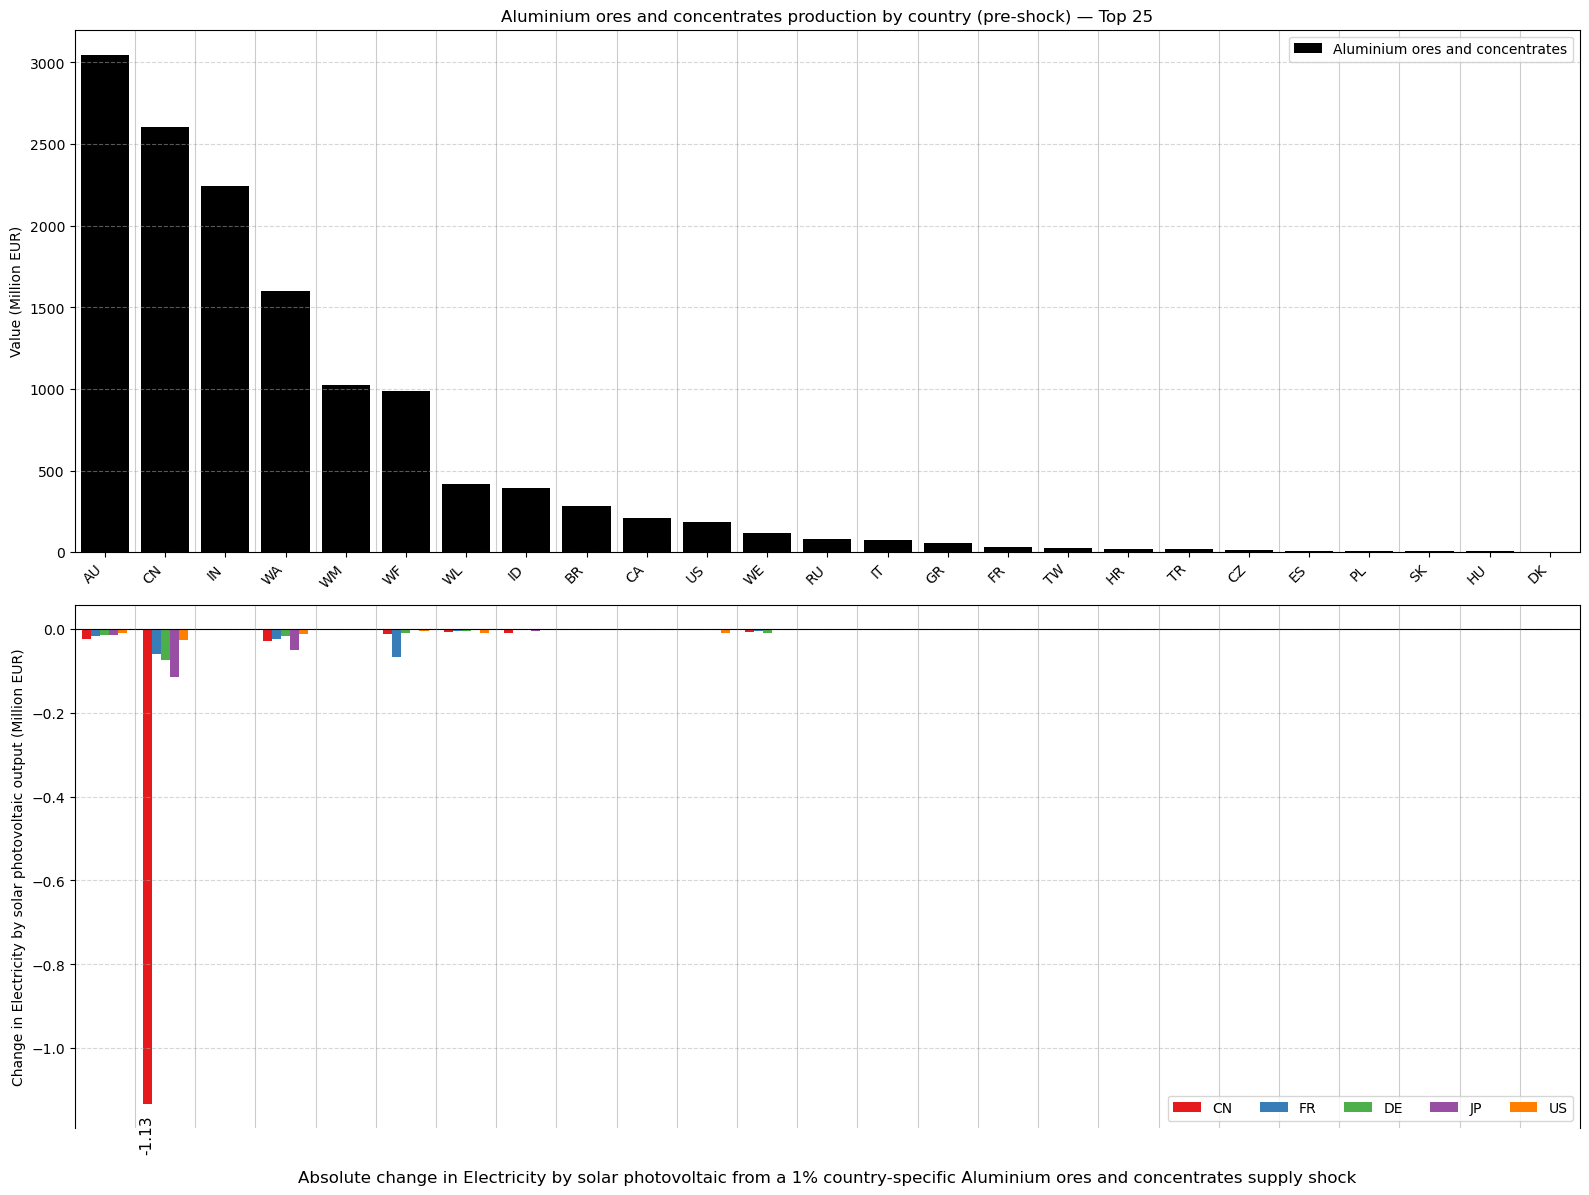

[Saved] ghosh_abs_changes_to_solar\Aluminium_ores_and_concentrates\grouped_top25_Aluminium_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Aluminium_ores_and_concentrates\table_grouped_top25_Aluminium_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Copper ores and concentrates
[Info] Top 25 producers of 'Copper ores and concentrates': ['CN', 'WL', 'AU', 'WM', 'WA', 'CA', 'MX', 'US', 'WF', 'PL', 'ID', 'RU', 'SE', 'BR', 'WE', 'BG', 'RO', 'ZA', 'FI', 'ES', 'IN', 'TR', 'TW', 'PT', 'BE']


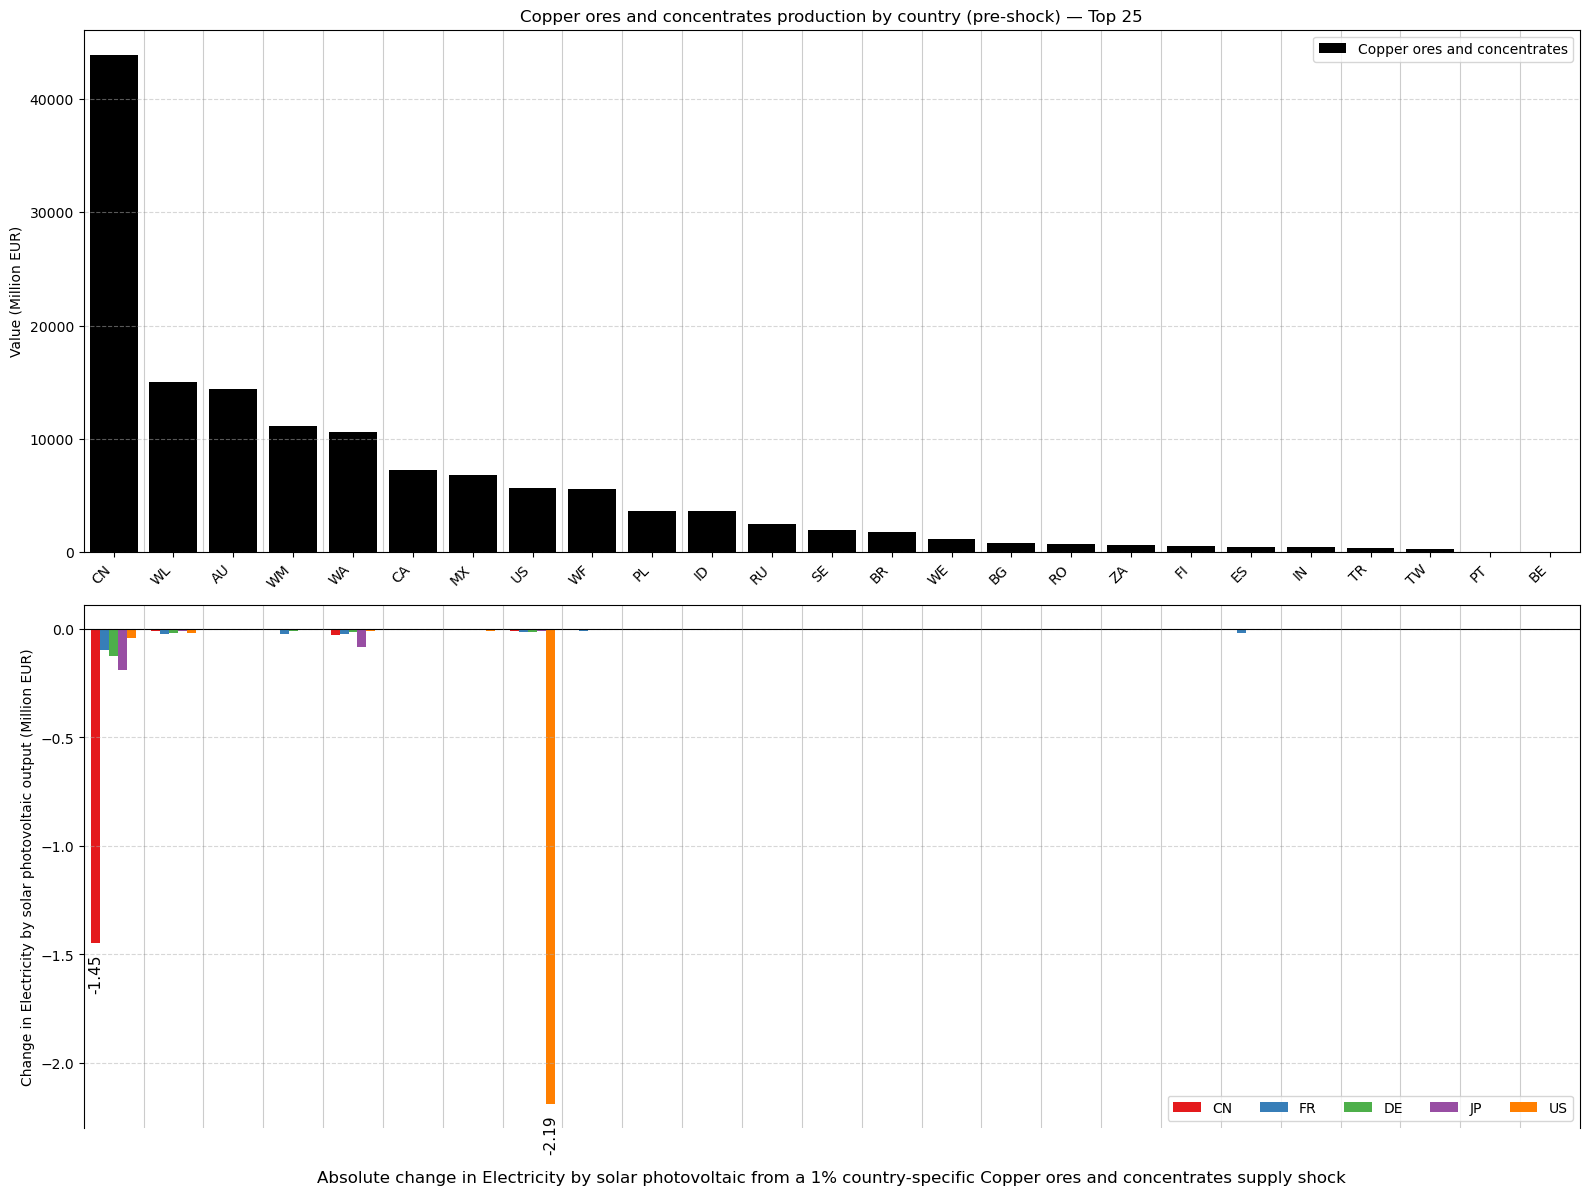

[Saved] ghosh_abs_changes_to_solar\Copper_ores_and_concentrates\grouped_top25_Copper_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Copper_ores_and_concentrates\table_grouped_top25_Copper_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Lead, zinc and tin ores and concentrates
[Info] Top 25 producers of 'Lead, zinc and tin ores and concentrates': ['CN', 'WA', 'AU', 'WM', 'ID', 'WF', 'WL', 'CA', 'RU', 'US', 'SE', 'WE', 'IN', 'BR', 'MX', 'DE', 'TW', 'RO', 'IE', 'PL', 'ZA', 'TR', 'PT', 'BG', 'FI']


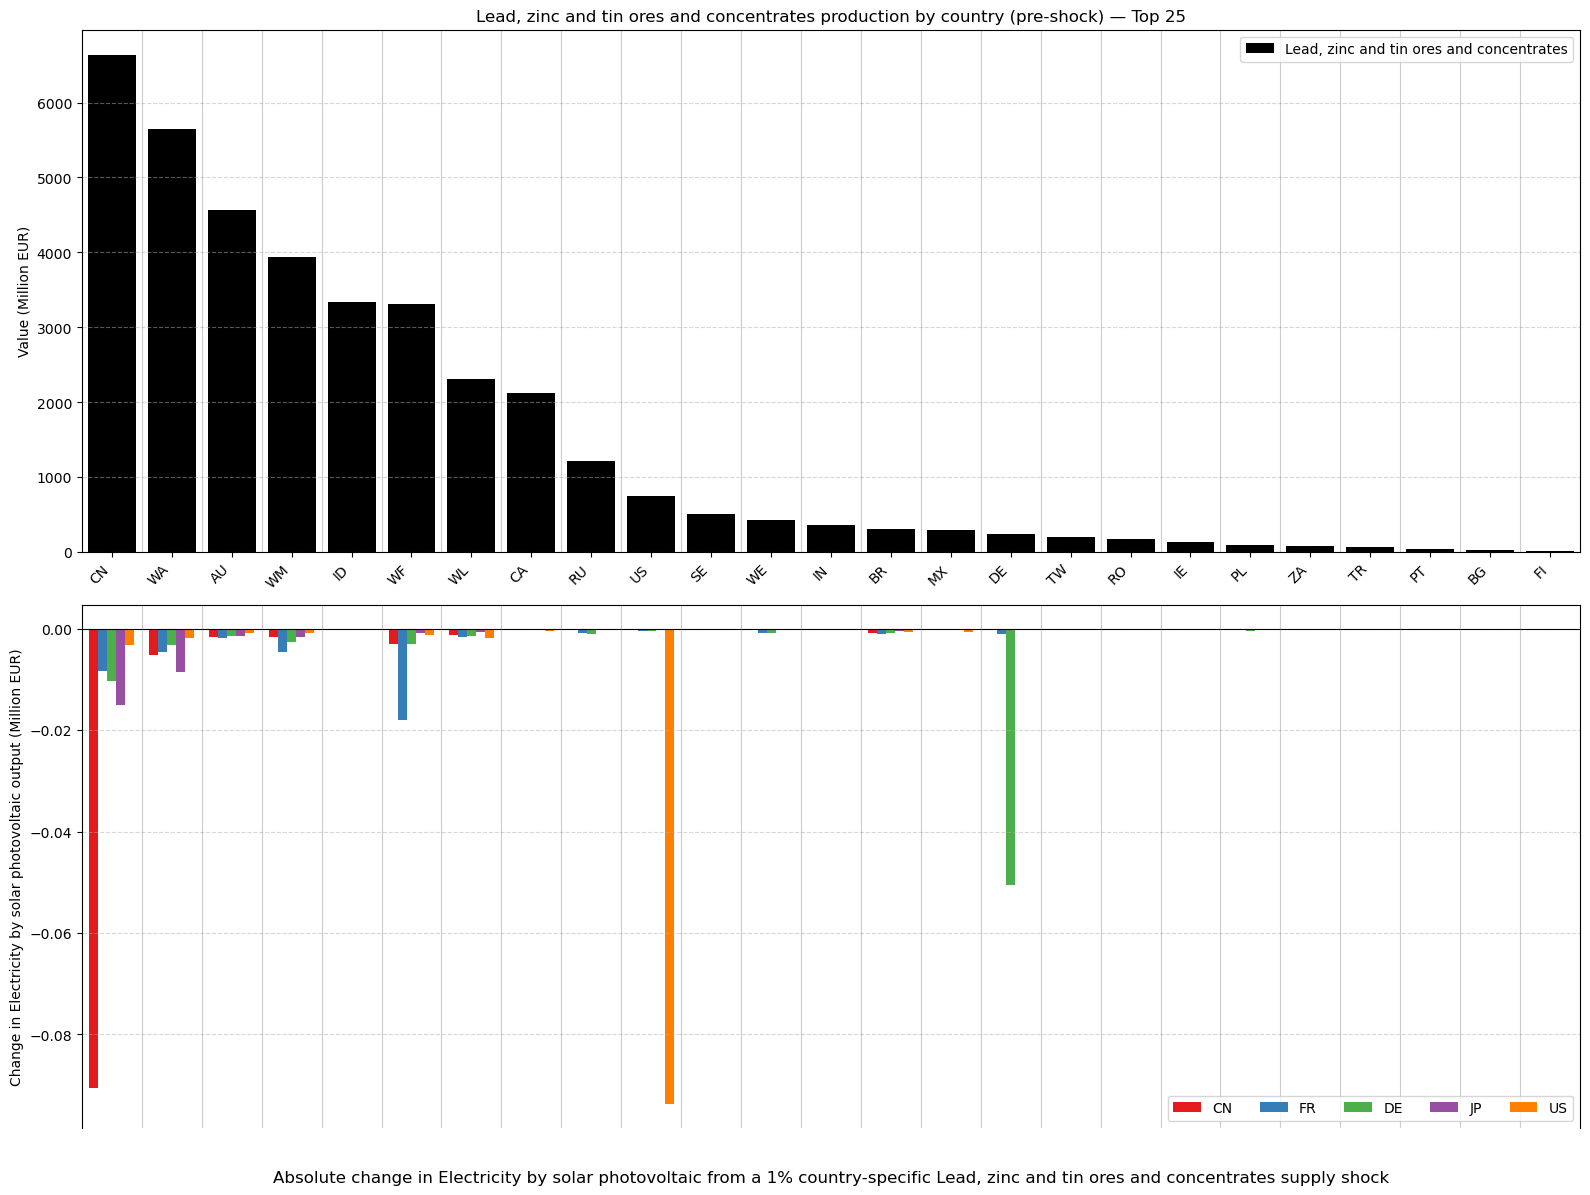

[Saved] ghosh_abs_changes_to_solar\Lead__zinc_and_tin_ores_and_concentrates\grouped_top25_Lead__zinc_and_tin_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Lead__zinc_and_tin_ores_and_concentrates\table_grouped_top25_Lead__zinc_and_tin_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Nickel ores and concentrates
[Info] Top 25 producers of 'Nickel ores and concentrates': ['CN', 'WA', 'ID', 'AU', 'WF', 'CA', 'BR', 'WL', 'RU', 'WE', 'ZA', 'WM', 'ES', 'GB', 'KR', 'SE', 'IE', 'FI', 'DE', 'CZ', 'SI', 'GR', 'MX', 'TR', 'RO']


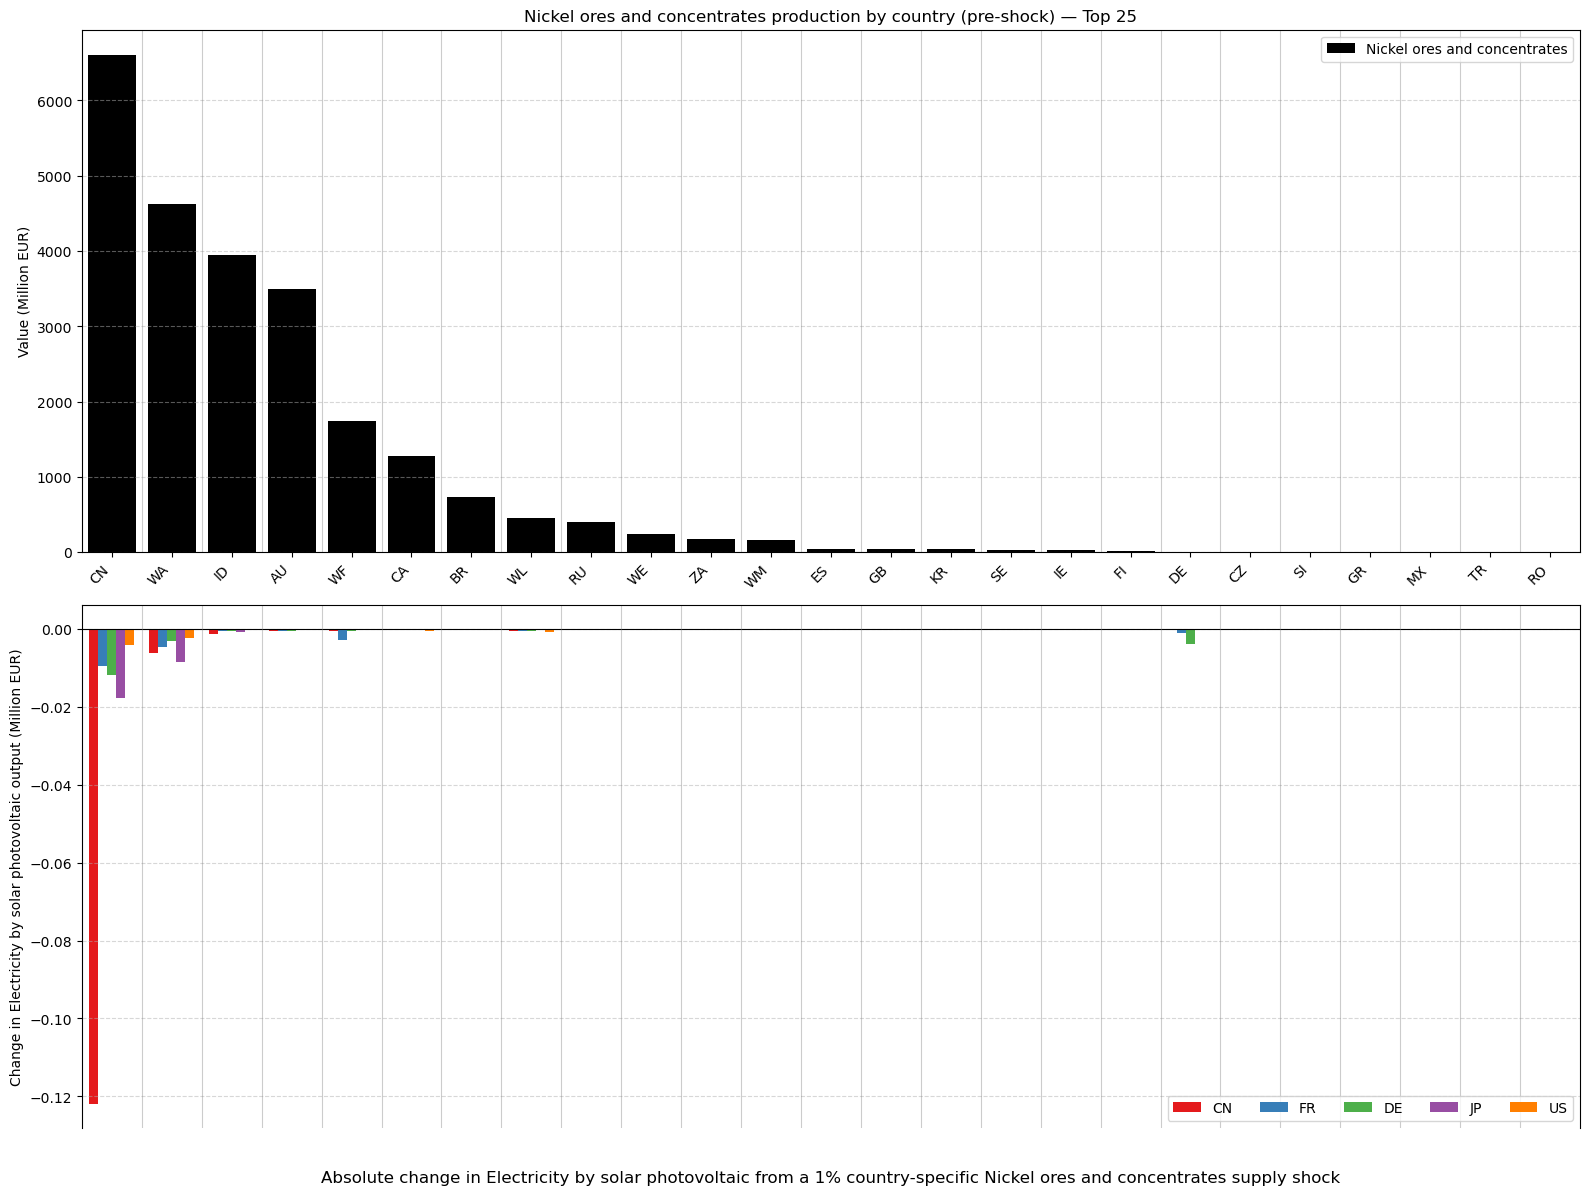

[Saved] ghosh_abs_changes_to_solar\Nickel_ores_and_concentrates\grouped_top25_Nickel_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Nickel_ores_and_concentrates\table_grouped_top25_Nickel_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Other non-ferrous metal ores and concentrates
[Info] Top 25 producers of 'Other non-ferrous metal ores and concentrates': ['CN', 'WA', 'AU', 'ZA', 'WM', 'WF', 'IN', 'WL', 'BR', 'BE', 'CA', 'RU', 'AT', 'US', 'TR', 'MX', 'RO', 'WE', 'NO', 'ES', 'JP', 'PT', 'SE', 'TW', 'FI']


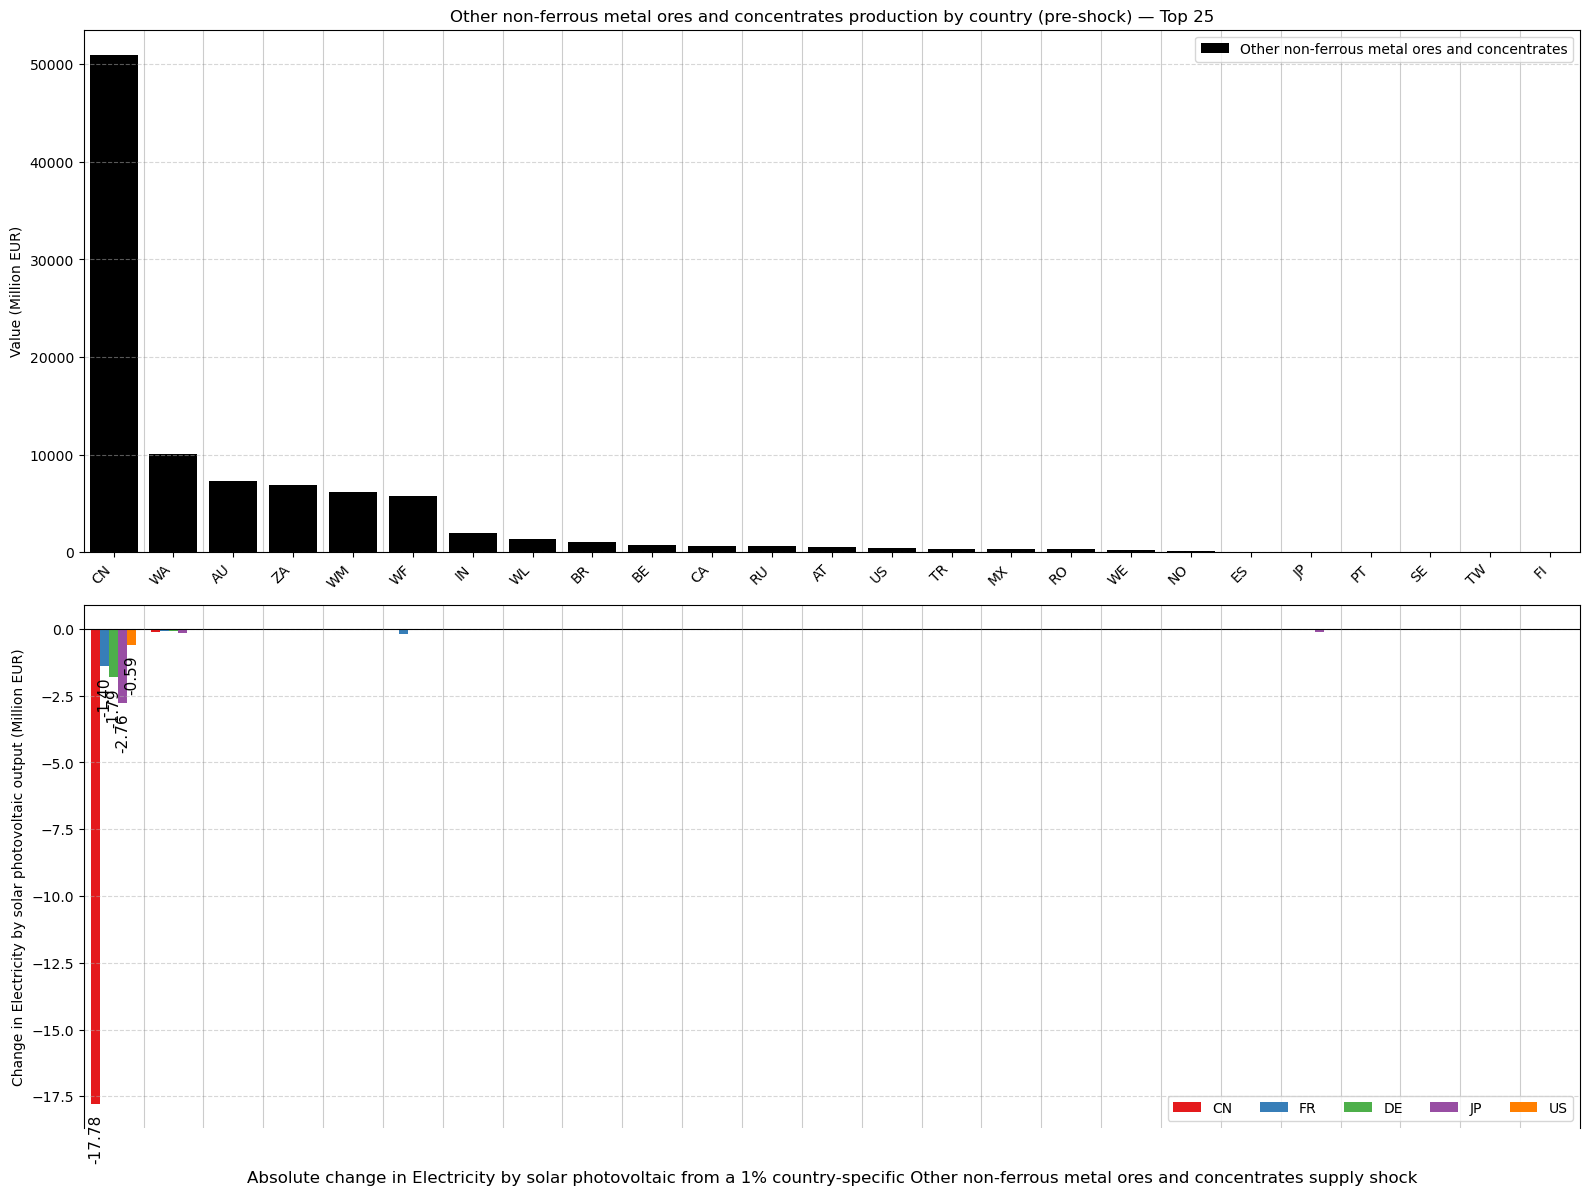

[Saved] ghosh_abs_changes_to_solar\Other_non-ferrous_metal_ores_and_concentrates\grouped_top25_Other_non-ferrous_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Other_non-ferrous_metal_ores_and_concentrates\table_grouped_top25_Other_non-ferrous_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Precious metal ores and concentrates
[Info] Top 25 producers of 'Precious metal ores and concentrates': ['CN', 'AU', 'ZA', 'WM', 'MX', 'WA', 'US', 'WL', 'WF', 'RU', 'BR', 'ID', 'WE', 'CA', 'TR', 'JP', 'BG', 'RO', 'TW', 'IN', 'SE', 'PL', 'SK', 'FI', 'IE']


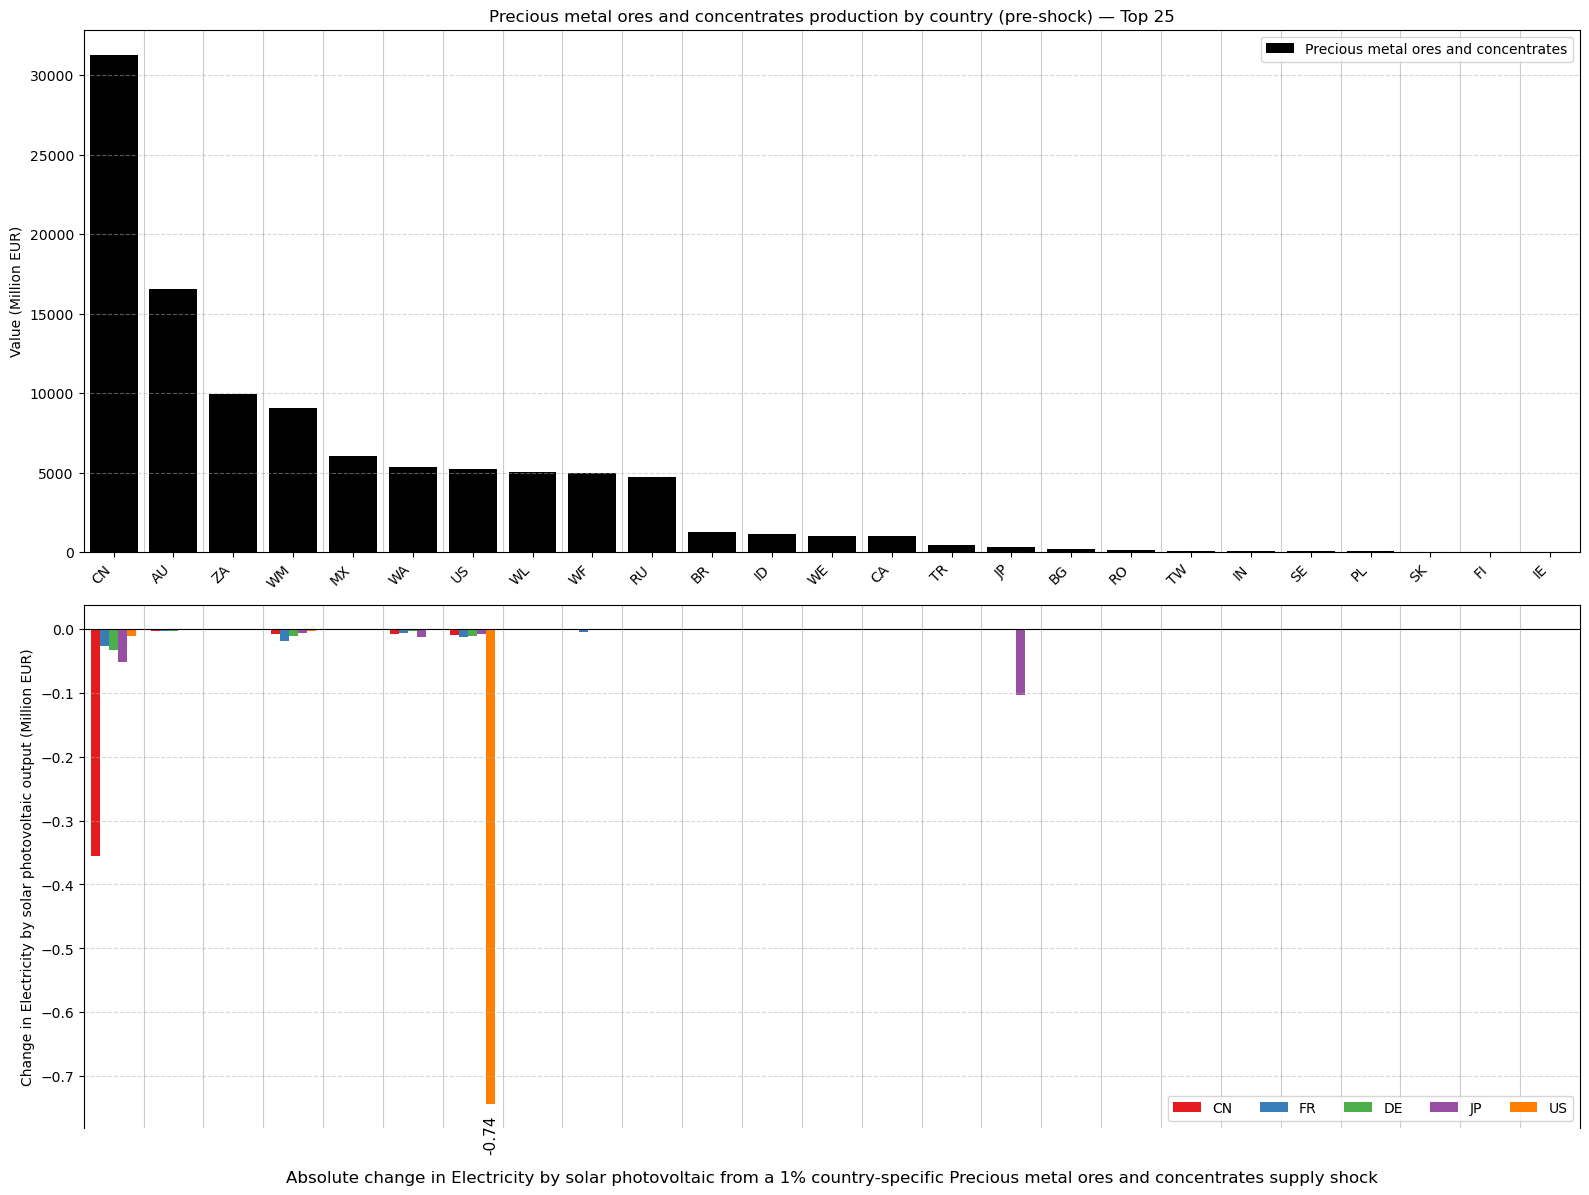

[Saved] ghosh_abs_changes_to_solar\Precious_metal_ores_and_concentrates\grouped_top25_Precious_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Precious_metal_ores_and_concentrates\table_grouped_top25_Precious_metal_ores_and_concentrates_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Aluminium and aluminium products
[Info] Top 25 producers of 'Aluminium and aluminium products': ['CN', 'US', 'DE', 'RU', 'JP', 'WA', 'AU', 'IN', 'CA', 'WM', 'IT', 'KR', 'GB', 'WL', 'ES', 'BR', 'WF', 'TW', 'FR', 'AT', 'NO', 'BE', 'PL', 'WE', 'CZ']


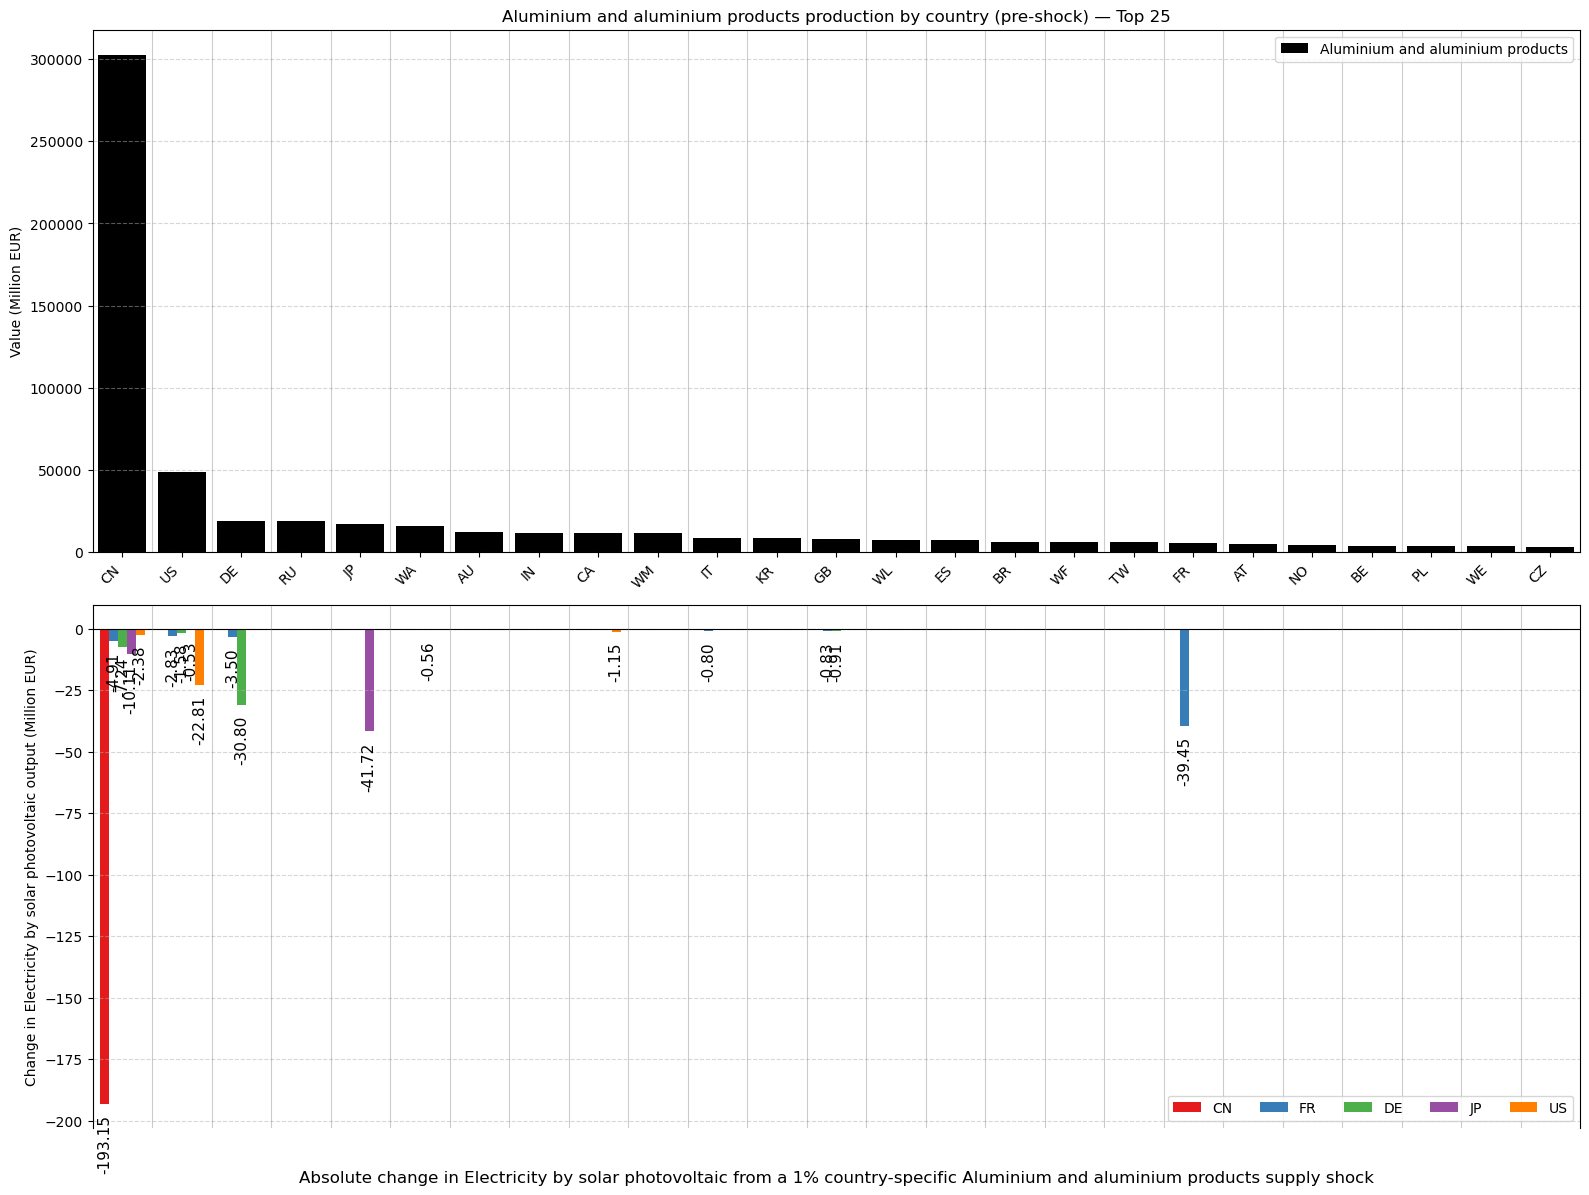

[Saved] ghosh_abs_changes_to_solar\Aluminium_and_aluminium_products\grouped_top25_Aluminium_and_aluminium_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Aluminium_and_aluminium_products\table_grouped_top25_Aluminium_and_aluminium_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Copper products
[Info] Top 25 producers of 'Copper products': ['CN', 'WL', 'US', 'KR', 'DE', 'IN', 'JP', 'BE', 'WA', 'RU', 'WM', 'MX', 'IT', 'FR', 'SE', 'AU', 'BG', 'ID', 'WF', 'CA', 'ES', 'GB', 'AT', 'TW', 'WE']


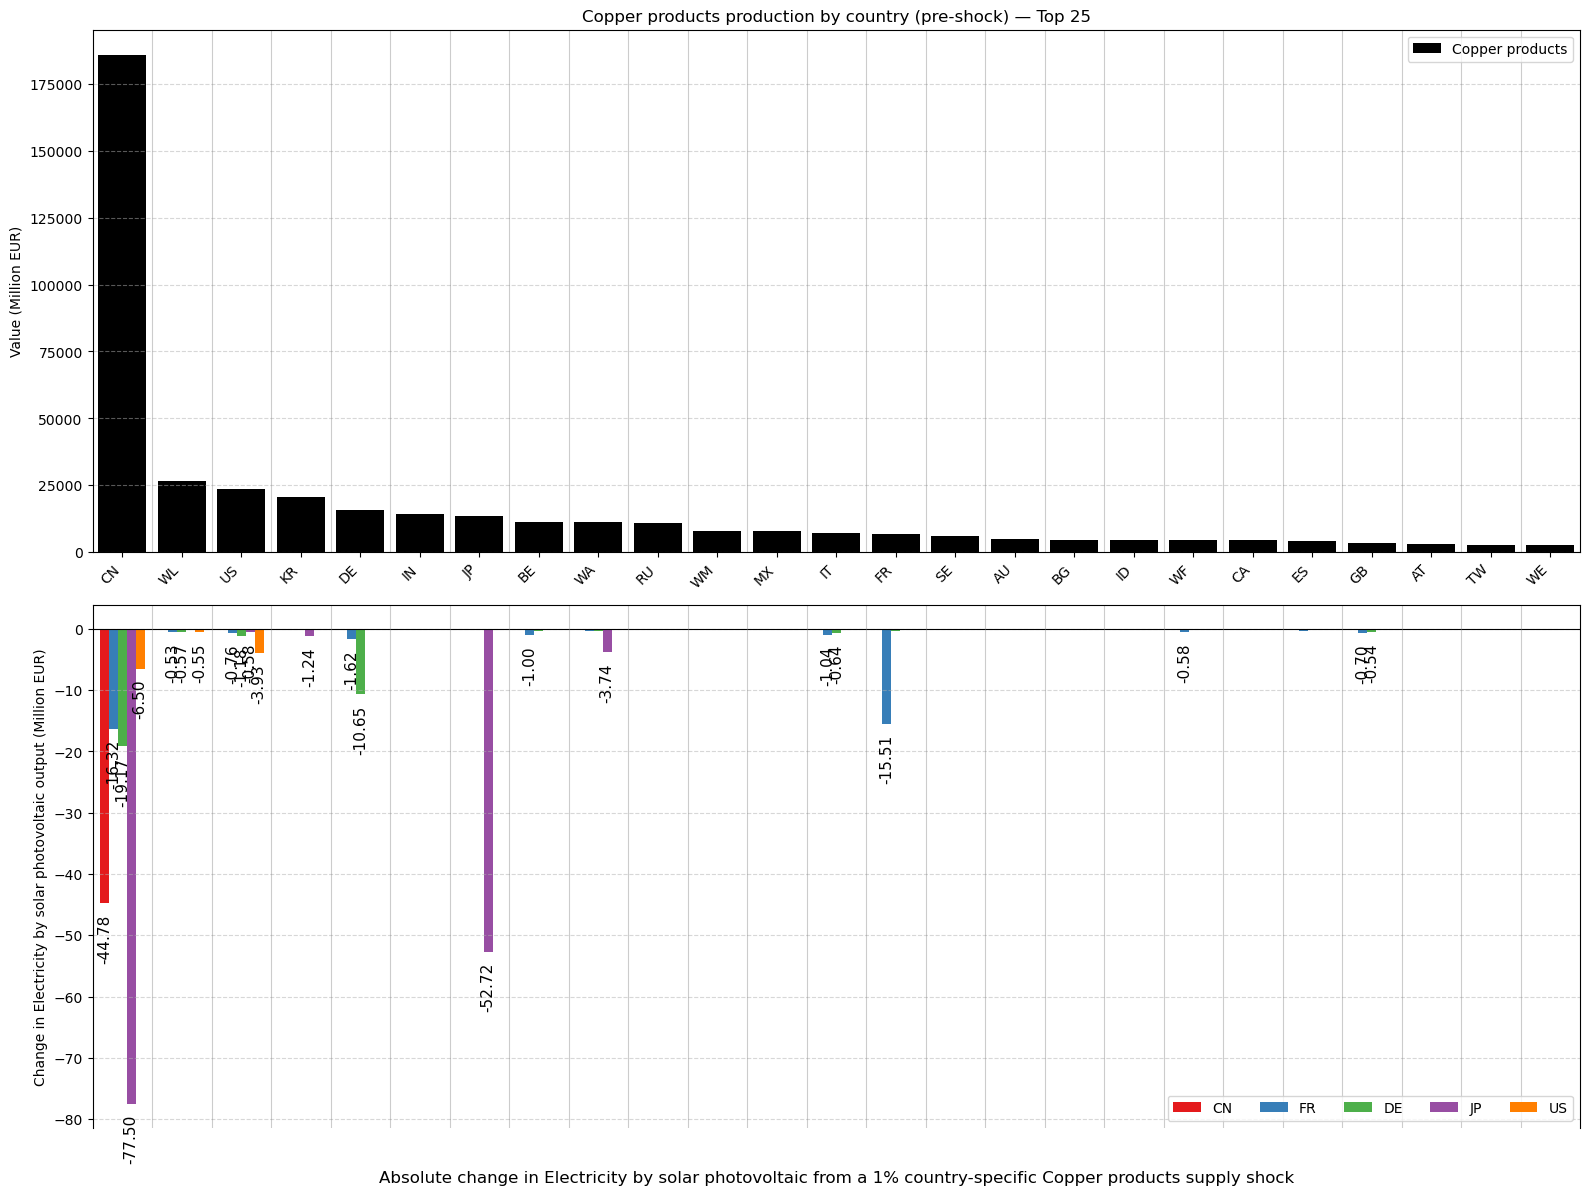

[Saved] ghosh_abs_changes_to_solar\Copper_products\grouped_top25_Copper_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Copper_products\table_grouped_top25_Copper_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Basic iron and steel and of ferro-alloys and first products thereof
[Info] Top 25 producers of 'Basic iron and steel and of ferro-alloys and first products thereof': ['CN', 'JP', 'KR', 'US', 'IN', 'WA', 'RU', 'TW', 'DE', 'WM', 'BR', 'IT', 'FR', 'ES', 'CA', 'WL', 'TR', 'MX', 'WF', 'PL', 'AU', 'ZA', 'WE', 'GB', 'ID']


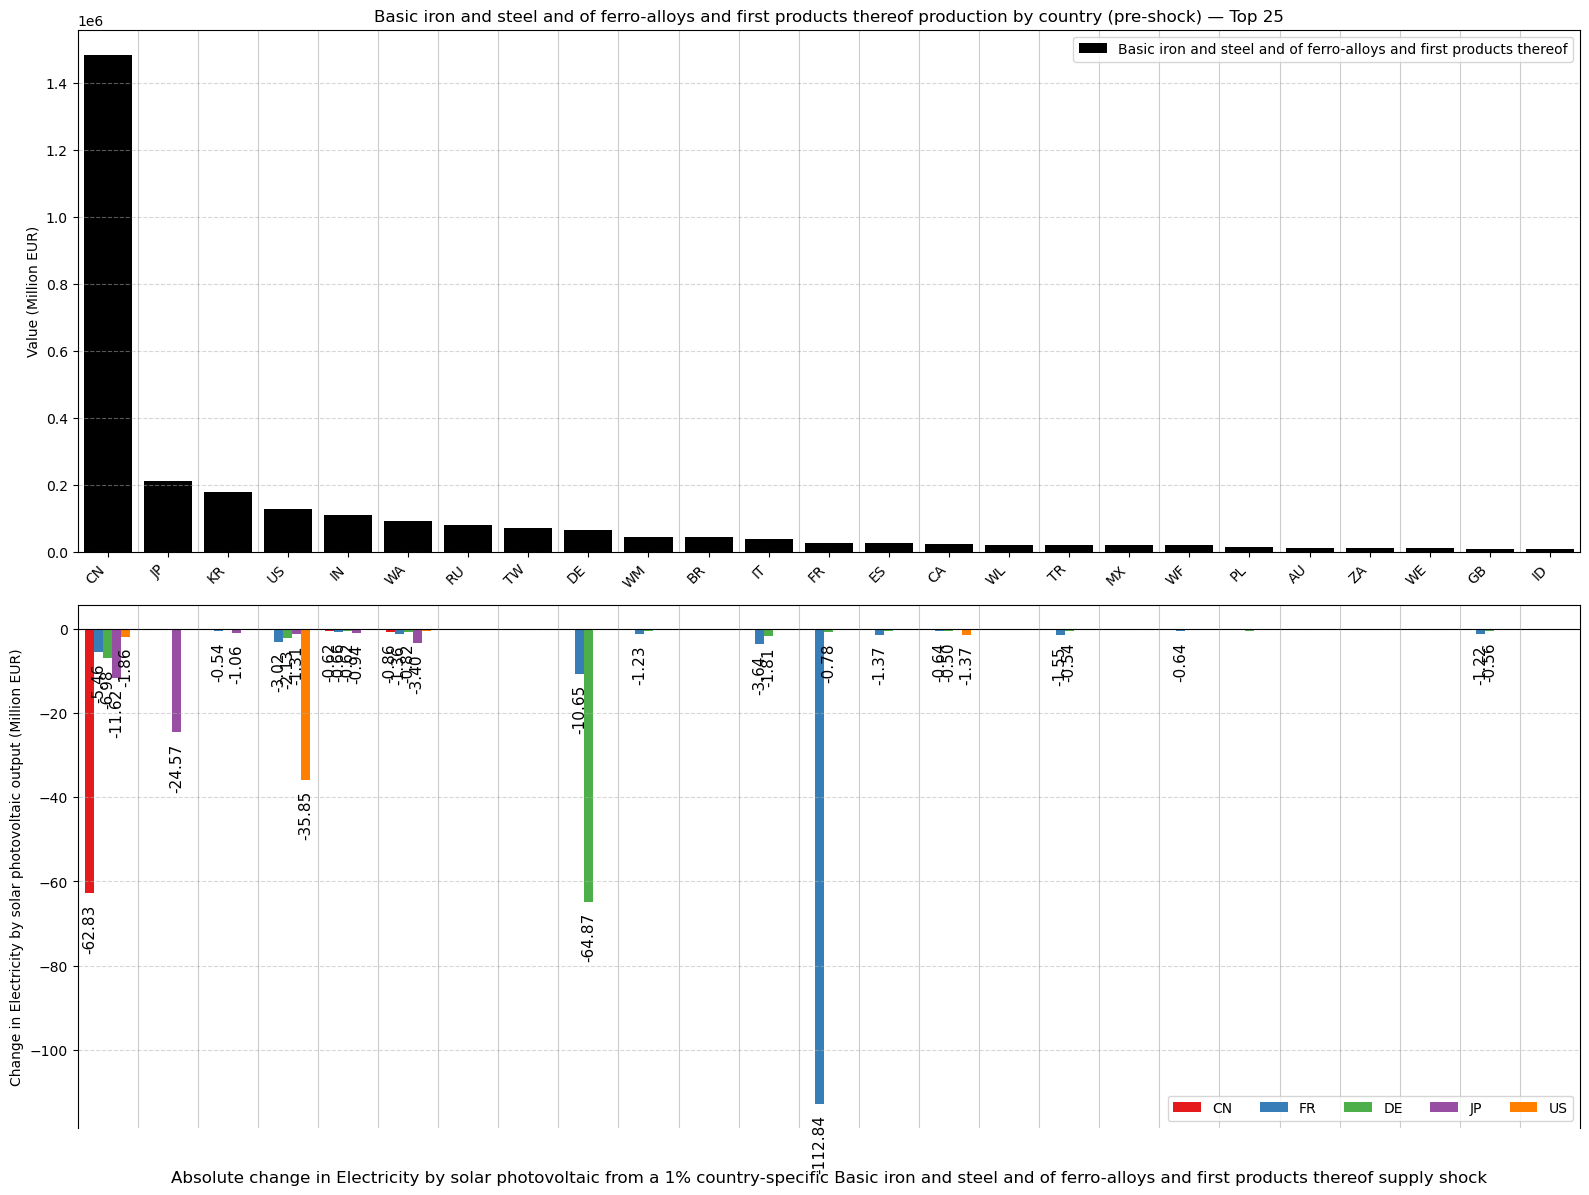

[Saved] ghosh_abs_changes_to_solar\Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof\grouped_top25_Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof\table_grouped_top25_Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Lead, zinc and tin and products thereof
[Info] Top 25 producers of 'Lead, zinc and tin and products thereof': ['CN', 'KR', 'WA', 'MX', 'IN', 'DE', 'WM', 'AU', 'JP', 'CA', 'GB', 'ID', 'WL', 'IT', 'WF', 'PL', 'US', 'RO', 'TW', 'RU', 'SE', 'BG', 'WE', 'FI', 'ES']


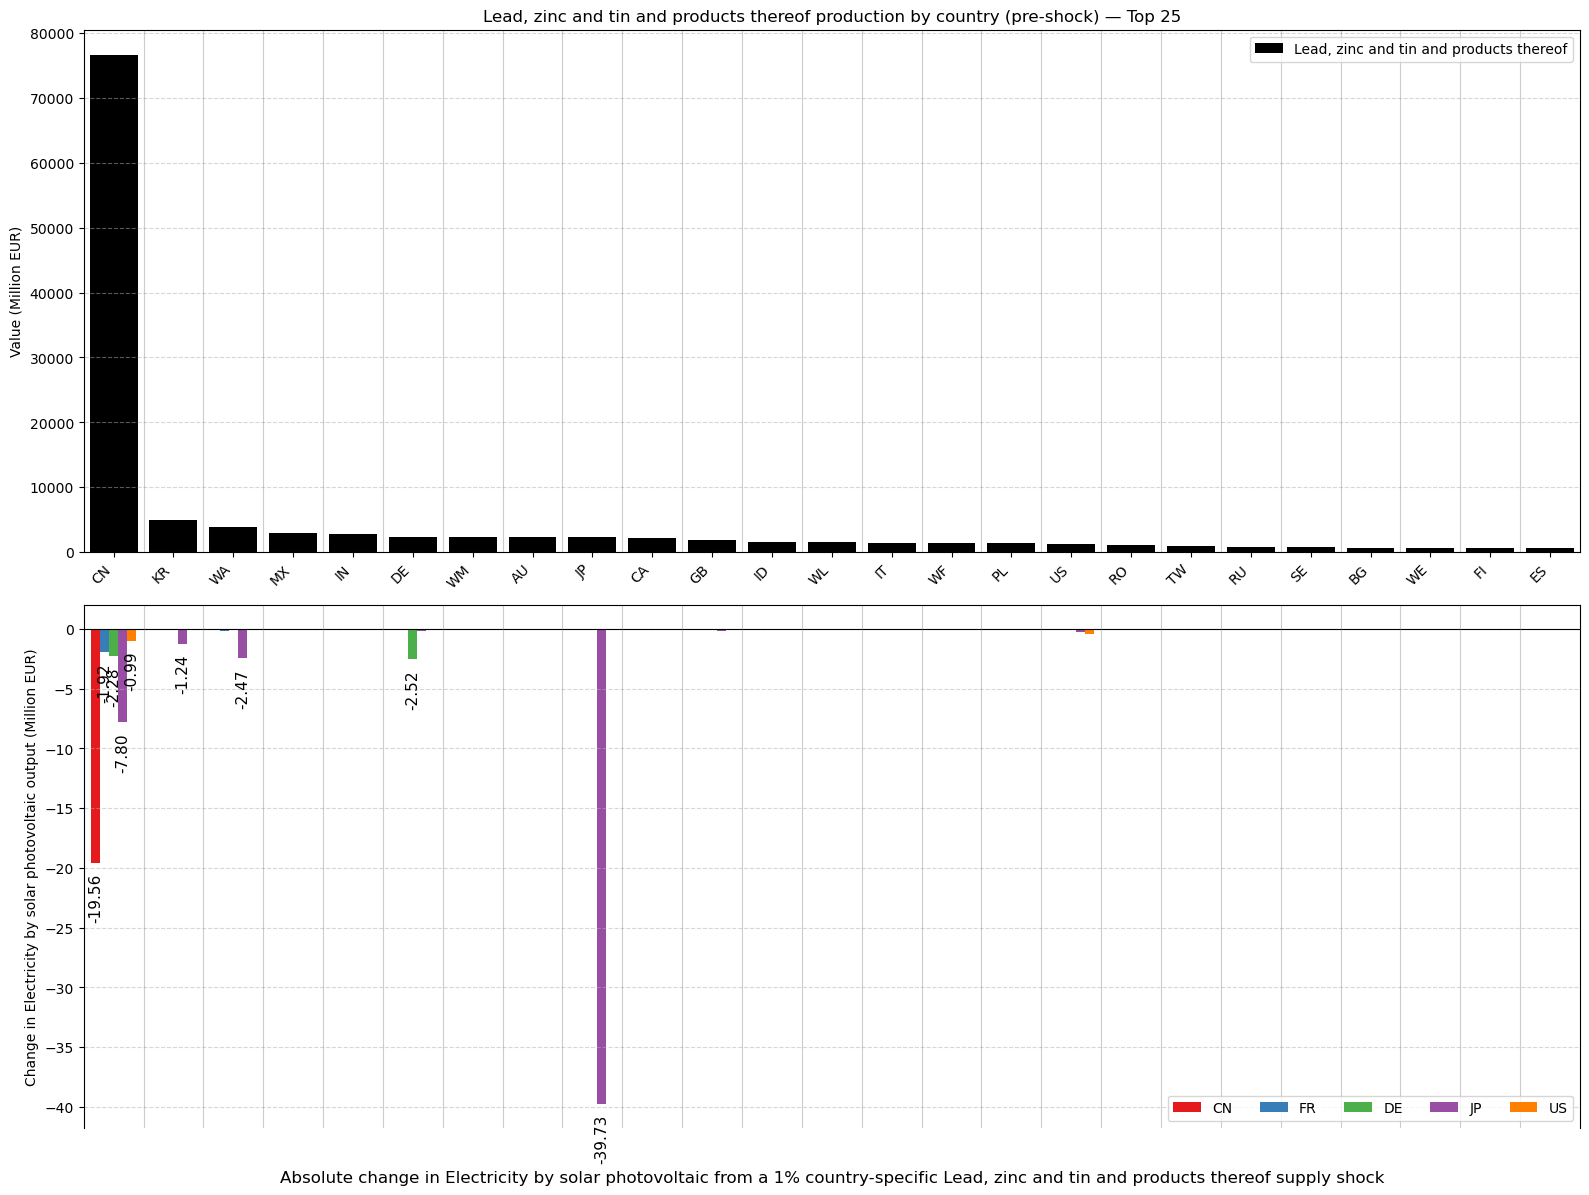

[Saved] ghosh_abs_changes_to_solar\Lead__zinc_and_tin_and_products_thereof\grouped_top25_Lead__zinc_and_tin_and_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Lead__zinc_and_tin_and_products_thereof\table_grouped_top25_Lead__zinc_and_tin_and_products_thereof_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Other non-ferrous metal products
[Info] Top 25 producers of 'Other non-ferrous metal products': ['CN', 'RU', 'WA', 'JP', 'AU', 'US', 'CA', 'WM', 'WF', 'ID', 'DE', 'WL', 'TW', 'AT', 'KR', 'NO', 'GB', 'FI', 'WE', 'BR', 'BE', 'NL', 'IN', 'MX', 'ZA']


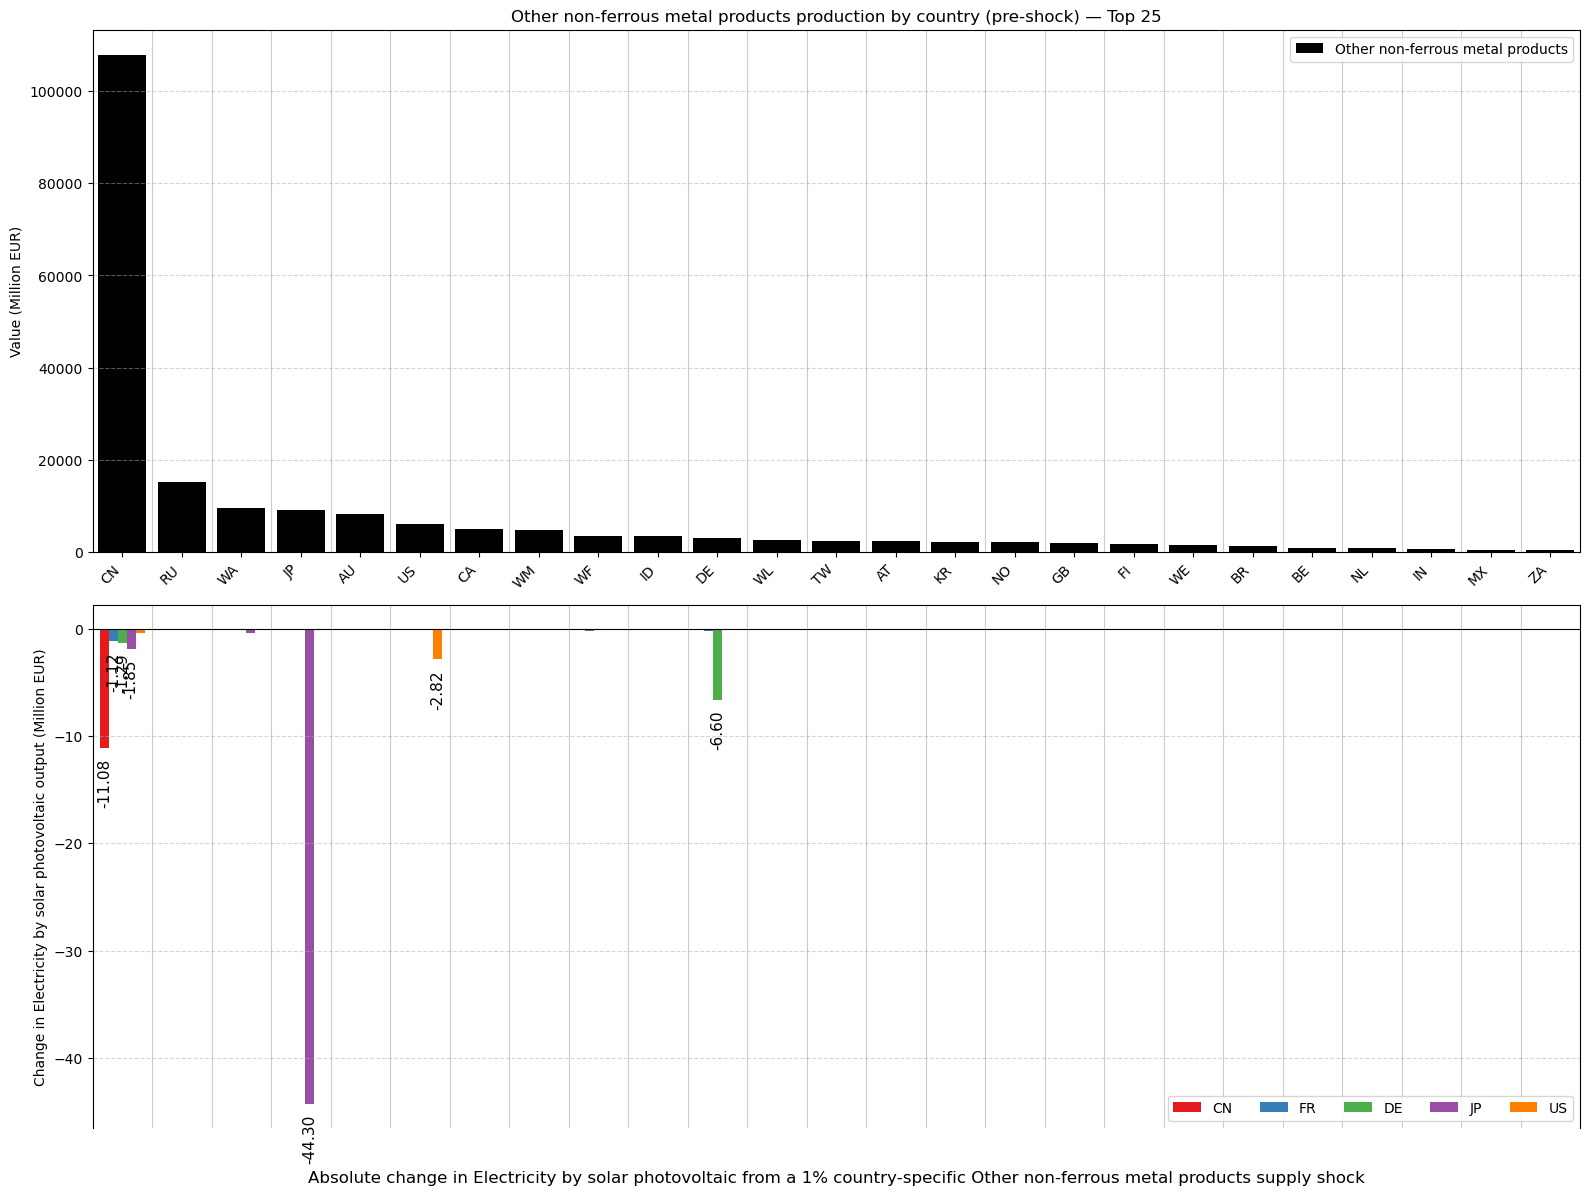

[Saved] ghosh_abs_changes_to_solar\Other_non-ferrous_metal_products\grouped_top25_Other_non-ferrous_metal_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Other_non-ferrous_metal_products\table_grouped_top25_Other_non-ferrous_metal_products_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Precious metals
[Info] Top 25 producers of 'Precious metals': ['CN', 'US', 'AU', 'IN', 'MX', 'RU', 'BE', 'CH', 'WA', 'KR', 'IT', 'WL', 'WM', 'ZA', 'WF', 'PL', 'JP', 'DE', 'TR', 'BR', 'GB', 'TW', 'WE', 'CA', 'NL']


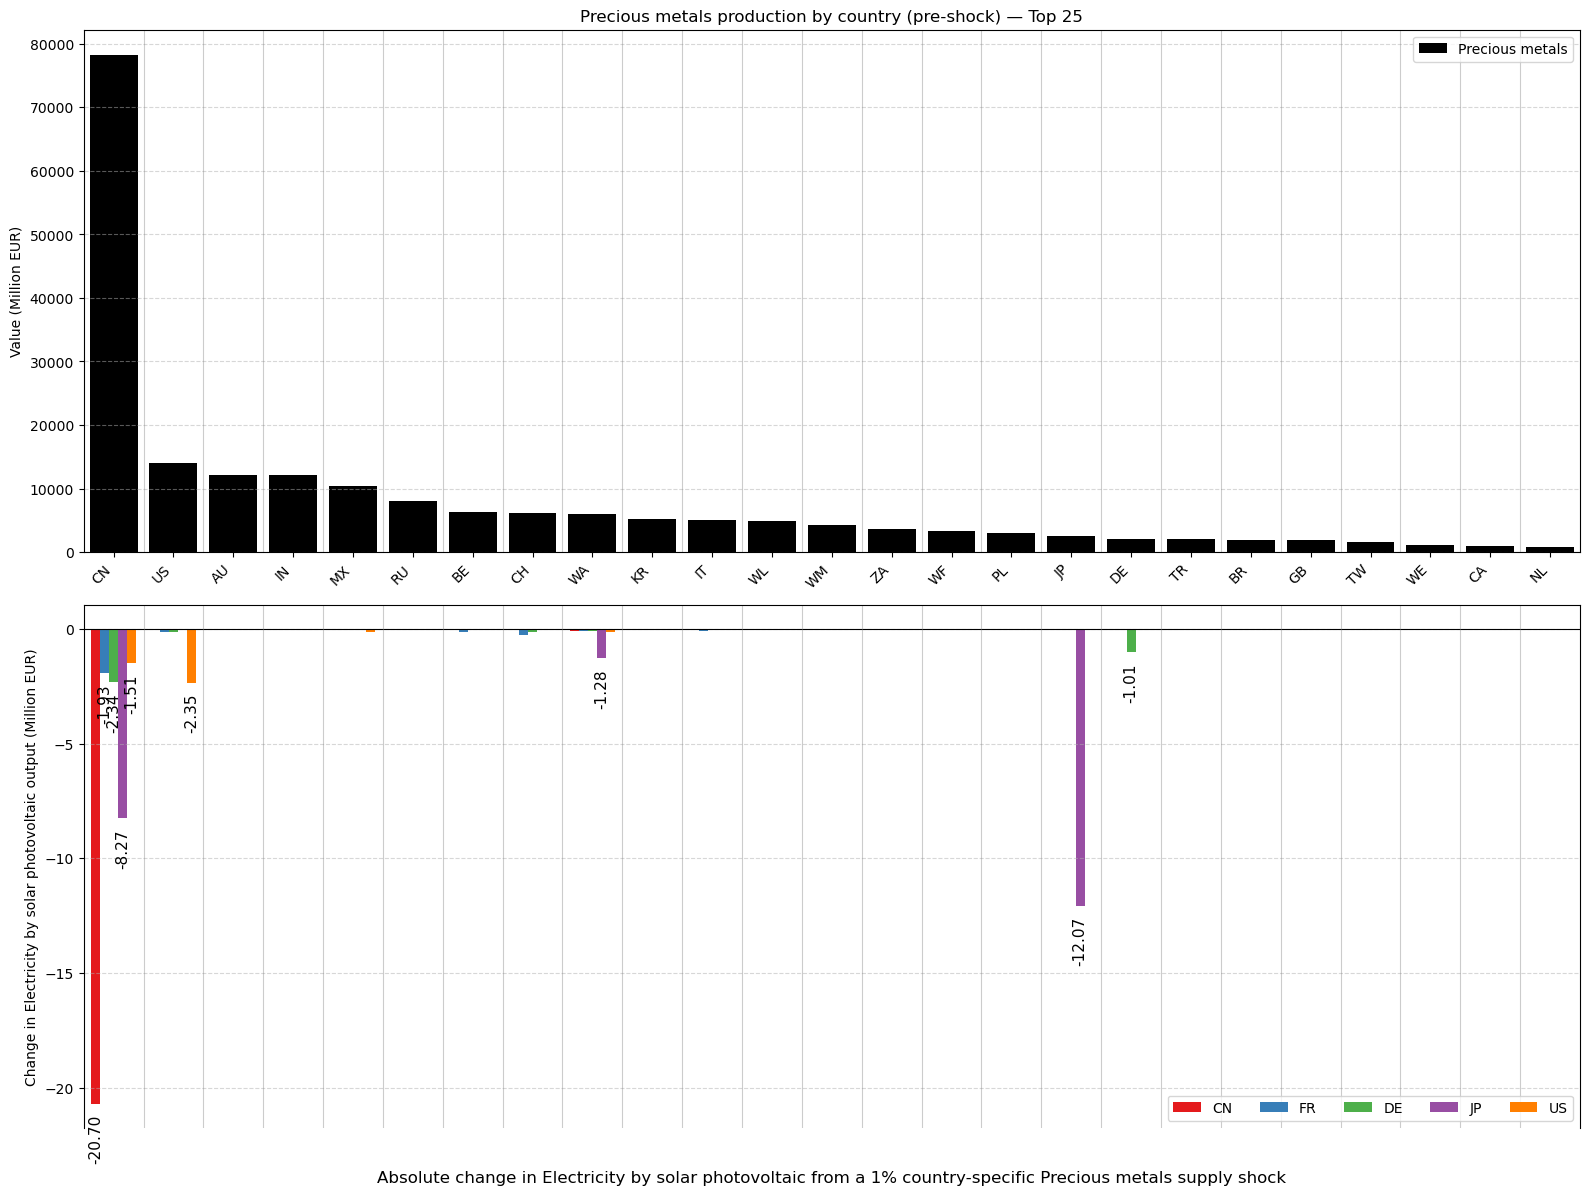

[Saved] ghosh_abs_changes_to_solar\Precious_metals\grouped_top25_Precious_metals_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Precious_metals\table_grouped_top25_Precious_metals_to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Electrical machinery and apparatus n.e.c. (31)
[Info] Top 25 producers of 'Electrical machinery and apparatus n.e.c. (31)': ['CN', 'JP', 'US', 'DE', 'IN', 'KR', 'WA', 'IT', 'FR', 'WM', 'MX', 'ES', 'TW', 'GB', 'WF', 'WL', 'PL', 'AU', 'CH', 'BR', 'ID', 'CZ', 'DK', 'TR', 'AT']


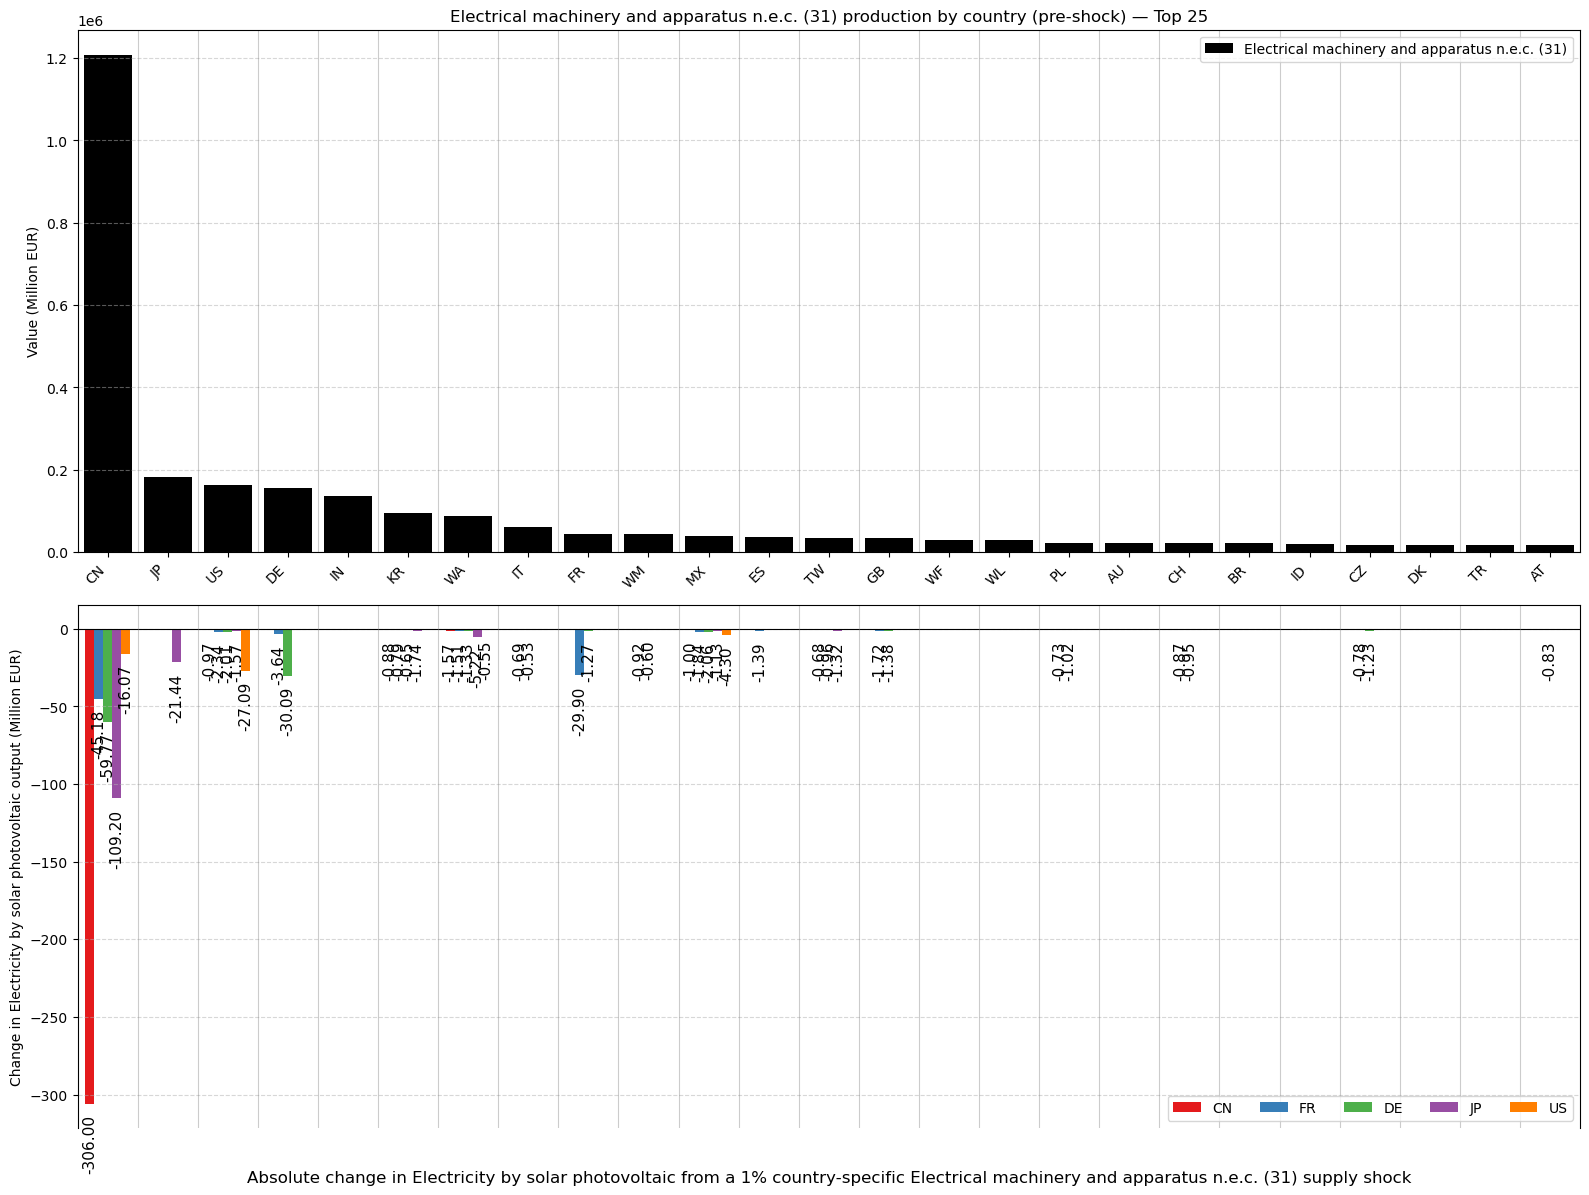

[Saved] ghosh_abs_changes_to_solar\Electrical_machinery_and_apparatus_n.e.c.__31_\grouped_top25_Electrical_machinery_and_apparatus_n.e.c.__31__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Electrical_machinery_and_apparatus_n.e.c.__31_\table_grouped_top25_Electrical_machinery_and_apparatus_n.e.c.__31__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Fabricated metal products, except machinery and equipment (28)
[Info] Top 25 producers of 'Fabricated metal products, except machinery and equipment (28)': ['CN', 'US', 'DE', 'JP', 'IN', 'IT', 'WA', 'KR', 'RU', 'WM', 'FR', 'WL', 'ES', 'GB', 'TW', 'PL', 'BR', 'WF', 'NL', 'ID', 'MX', 'CH', 'CA', 'CZ', 'TR']


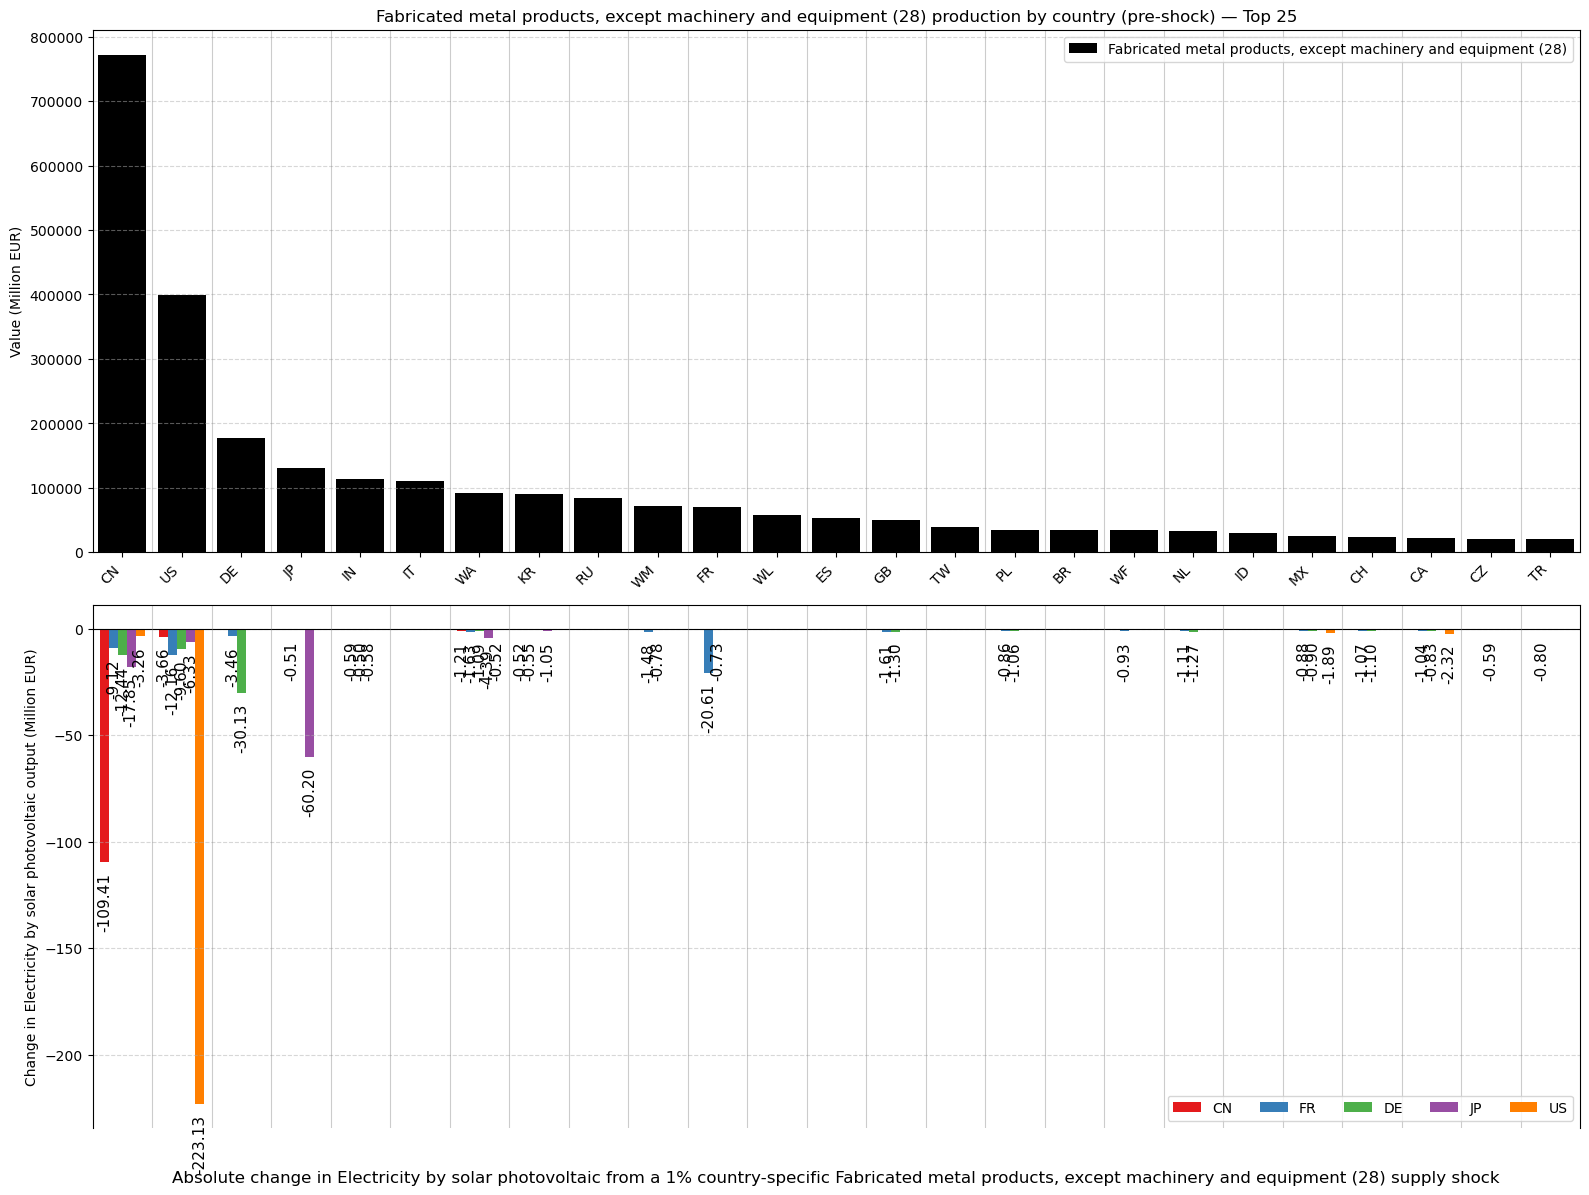

[Saved] ghosh_abs_changes_to_solar\Fabricated_metal_products__except_machinery_and_equipment__28_\grouped_top25_Fabricated_metal_products__except_machinery_and_equipment__28__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Fabricated_metal_products__except_machinery_and_equipment__28_\table_grouped_top25_Fabricated_metal_products__except_machinery_and_equipment__28__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv

[Run] Shock industry -> Machinery and equipment n.e.c. (29)
[Info] Top 25 producers of 'Machinery and equipment n.e.c. (29)': ['CN', 'US', 'JP', 'DE', 'WA', 'IN', 'KR', 'IT', 'WM', 'WL', 'FR', 'GB', 'WF', 'TW', 'BR', 'RU', 'CA', 'ES', 'NL', 'CH', 'AT', 'MX', 'SE', 'TR', 'PL']


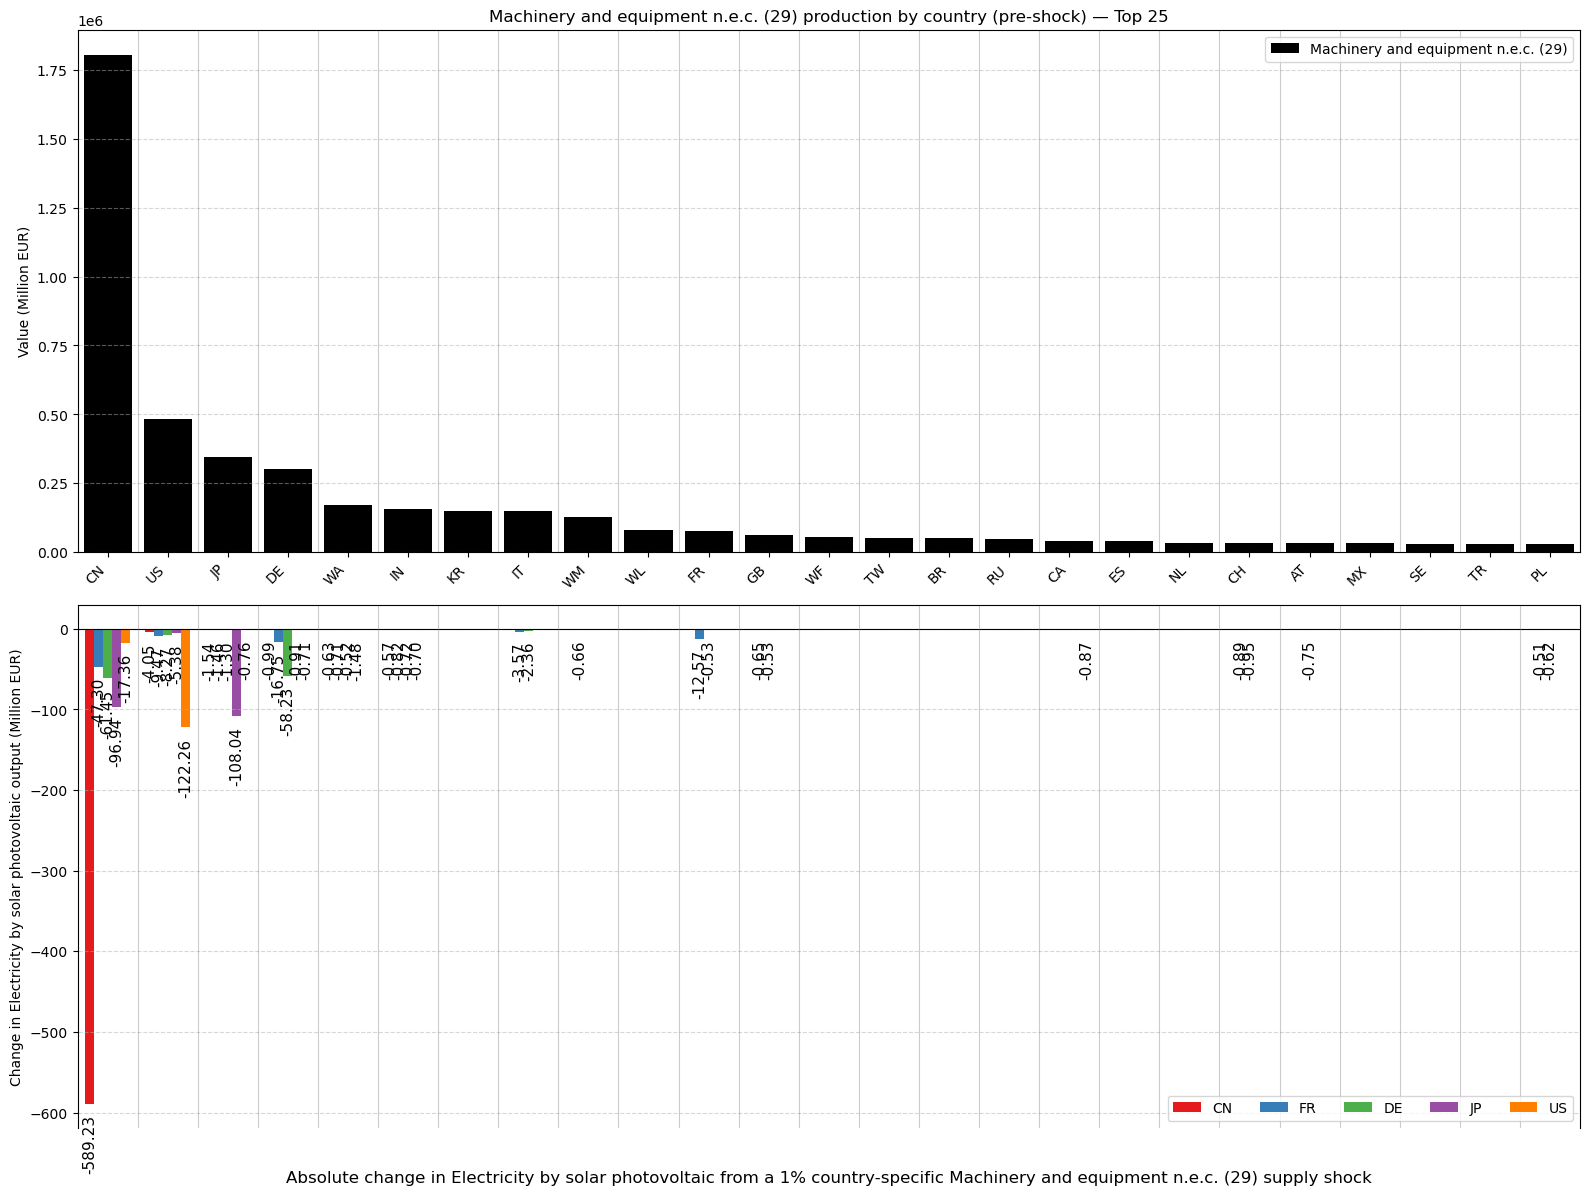

[Saved] ghosh_abs_changes_to_solar\Machinery_and_equipment_n.e.c.__29_\grouped_top25_Machinery_and_equipment_n.e.c.__29__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.png
[Saved] ghosh_abs_changes_to_solar\Machinery_and_equipment_n.e.c.__29_\table_grouped_top25_Machinery_and_equipment_n.e.c.__29__to_Electricity_by_solar_photovoltaic_ghosh_abs_1pct_20251218_1028.csv


In [7]:

# -*- coding: utf-8 -*-
"""
Ghosh shocks -> absolute changes in Solar PV (Million EUR)
Loop over 15 shock industries, country-specific 1% cuts, Top-N producers,
and plot/save grouped bars of ABSOLUTE changes for target countries.

Requirements in memory:
    A_df : pd.DataFrame (rows=(Country,Industry), cols=(Country,Industry)), technical coeffs
    x_base : pd.Series (MultiIndex (Country,Industry)), baseline outputs (Million EUR)
    s_base : pd.Series (MultiIndex (Country,Industry)), baseline primary inputs/value added
Optional:
    exio3.x : Series or DataFrame with outputs by (Country, Industry) for Top-N resolution

Author: You
"""
# ------------------ Helper: safe filenames ------------------
def safe_slug(s):
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(s))

# ------------------ Config ------------------
# Shock size (country-specific)
try:
    shock_pct
except NameError:
    shock_pct = 0.01  # 1% cut in the shocked industry's supply in each Top-N country

# Target industry is Solar PV electricity (adjust substring if your label differs)
target_industry_substrings = ("electricity", "solar", "photovoltaic")

# Countries to show in grouped bars (bottom panel)
target_countries = ["CN", "FR", "DE", "JP", "US"]

# Show top-N producers of the shocked industry
TOP_N = 25

# Colors per target country
country_colors = {
    "CN": "#e41a1c",
    "FR": "#377eb8",
    "DE": "#4daf4a",
    "JP": "#984ea3",
    "US": "#ff7f00",
}

# Label bars if |absolute change| >= this threshold (Million EUR)
LABEL_THRESHOLD = 0.5

# Base output folder & timestamp
out_dir_base = "ghosh_abs_changes_to_solar"
os.makedirs(out_dir_base, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M")

# ------------------ Robust matching helpers ------------------
def find_industry_name(columns_multiindex, industry_substrings=("copper", "ore")):
    """Return the first Industry label in columns whose string contains all substrings (case-insensitive)."""
    if not isinstance(columns_multiindex, pd.MultiIndex):
        # columns are industry-level only
        candidates = [c for c in columns_multiindex if all(s.lower() in str(c).lower() for s in industry_substrings)]
        return candidates[0] if candidates else None
    # MultiIndex: (Country, Industry) -> use the Industry level
    inds = columns_multiindex.get_level_values(1)
    matches = [ind for ind in inds.unique() if all(s.lower() in str(ind).lower() for s in industry_substrings)]
    return matches[0] if matches else None

def find_label(index_multiindex, country, industry_substrings=("electricity", "solar", "photovoltaic")):
    """Return a (Country, Industry) label in index that matches country and contains all substrings."""
    matches = [idx for idx in index_multiindex if (idx[0] == country) and all(s.lower() in str(idx[1]).lower() for s in industry_substrings)]
    if not matches:
        raise KeyError(f"No label for country={country} with substrings={industry_substrings}")
    return matches[0]

# ------------------ Build SHOCK_INDUSTRIES from your categories ------------------
industry_candidates = [
    # Primary
    ("Aluminium Ore", ("alum", "ore")),
    ("Copper Ore", ("copper", "ore")),
    ("Lead, Zinc & Tin Ore", ("lead", "zinc", "tin", "ore")),
    ("Nickel", ("nickel", "ore")),
    ("Other Non-Ferrous Metal Ore", ("non-ferrous", "ore")),
    ("Precious Metal Ore", ("precious", "metal", "ore")),
    # Secondary
    ("Aluminium Products", ("alum", "product")),
    ("Copper Products", ("copper", "product")),
    ("Basic Iron, Steel & Ferro-Alloy Products", ("iron", "steel", "ferro")),
    ("Lead, Zinc & Tin Products", ("lead", "zinc", "tin", "product")),
    ("Other Non-Ferrous Mineral Products", ("non-ferrous", "product")),
    ("Precious Metal Products", ("precious", "metals")),
    # Tertiary
    ("Electrical Machinery and Apparatus", ("electrical", "machinery", "apparatus")),
    ("Fabricated Metal Products", ("fabricated", "metal", "product")),
    ("Machinery and Equipment", ("machinery", "equipment", "n.e.c.")),
]

SHOCK_INDUSTRIES = []
not_found = []

# Column labels list for fallback search
if isinstance(A_df.columns, pd.MultiIndex):
    col_labels = A_df.columns.get_level_values(1)  # Industry level
else:
    col_labels = A_df.columns

for display_name, substrings in industry_candidates:
    resolved = None
    try:
        resolved = find_industry_name(A_df.columns, industry_substrings=substrings)
    except Exception:
        resolved = None

    # Fallback: simple substring AND match directly on industry names
    if resolved is None:
        matches = [c for c in col_labels.unique() if all(s.lower() in str(c).lower() for s in substrings)]
        resolved = matches[0] if matches else None

    if resolved:
        SHOCK_INDUSTRIES.append(str(resolved))
    else:
        not_found.append(display_name)

# De-duplicate while preserving order
seen = set()
SHOCK_INDUSTRIES = [x for x in SHOCK_INDUSTRIES if not (x in seen or seen.add(x))]

print(f"[Shock list] Resolved {len(SHOCK_INDUSTRIES)} industries:")
for si in SHOCK_INDUSTRIES:
    print("  -", si)
if not_found:
    print("[Warn] Could not resolve these display names to EXIOBASE industries:", not_found)

# ------------------ Build B from Z (row-normalized, Ghosh) ------------------
# Reconstruct Z from A and column outputs (users on columns)
x_cols = x_base.reindex(A_df.columns)                 # align outputs with A_df columns
Z_df = A_df.mul(x_cols, axis=1)                       # Z = A * diag(x_cols)

# Row-normalize to get B (supplier i on rows)
x_rows = x_base.reindex(Z_df.index)                   # align outputs with rows
B_df = Z_df.divide(x_rows, axis=0).fillna(0.0)        # B_ij = Z_ij / x_i

# (I - B)
I_df = pd.DataFrame(np.eye(B_df.shape[0]), index=B_df.index, columns=B_df.columns)
M = (I_df - B_df).values
index_MI = B_df.index  # master order for vectors

# Diagnostics
s0_chk = s_base.reindex(index_MI)
x0_chk = x_base.reindex(index_MI)
resid = (I_df - B_df).dot(x0_chk) - s0_chk
rho = float(np.max(np.abs(np.linalg.eigvals(B_df.values))))
print("=== Matrix diagnostics ===")
print(f"||(I-B)x - s||_∞ = {float(np.abs(resid).max()):.3e}")
print(f"Spectral radius ρ(B) = {rho:.6f}")

# ------------------ Resolve Solar PV industry & per-country labels ------------------
target_industry_name = find_industry_name(A_df.columns, industry_substrings=target_industry_substrings)
print(f"[Match] Target industry name -> {target_industry_name}")

# Labels per target country
target_labels = {}
for tc in target_countries:
    try:
        lbl = find_label(x_base.index, country=tc, industry_substrings=target_industry_substrings)
        target_labels[tc] = lbl
    except KeyError:
        print(f"[Warn] No Solar PV label for country={tc}. Skipping.")
        target_labels[tc] = None

# Baseline outputs (for info only; absolute changes don't divide by these)
x_baseline_targets = {}
for tc, lbl in target_labels.items():
    if (lbl is None) or (lbl not in x_base.index):
        x_baseline_targets[tc] = np.nan
    else:
        x_baseline_targets[tc] = float(x_base.loc[lbl])
print("[Baselines] " + ", ".join(f"{tc}={x_baseline_targets[tc]:.6g}" for tc in target_countries if np.isfinite(x_baseline_targets[tc])))

# ------------------ Helper: get Top-N producer countries for a shock industry ------------------
def get_topN_producers(industry_name, topN=25):
    idx = pd.IndexSlice
    # Try exio3.x first if present
    try:
        exio_x = exio3.x
        if isinstance(exio_x, pd.Series):
            shock_output = exio_x.loc[idx[:, industry_name]].reset_index()
            shock_output.columns = ["Country", "Industry", "Shock_Output_EUR"]
            shock_by_country = shock_output.set_index("Country")["Shock_Output_EUR"]
        else:
            shock_output = exio_x.loc[idx[:, industry_name], :]
            shock_output = shock_output.iloc[:, [0]].reset_index()
            shock_output.columns = ["Country", "Industry", "Shock_Output_EUR"]
            shock_by_country = shock_output.set_index("Country")["Shock_Output_EUR"]
    except Exception:
        # Fallback to x_base
        sub = x_base.loc[idx[:, industry_name]]
        shock_by_country = sub.reset_index().set_index("level_0")[0]  # level_0 is Country, 0 is value
        shock_by_country.index.name = "Country"

    topN_series = shock_by_country.sort_values(ascending=False).head(topN)
    return topN_series

# ------------------ LOOP: shock each industry and plot ABSOLUTE changes ------------------
idx = pd.IndexSlice

for shock_industry in SHOCK_INDUSTRIES:
    print(f"\n[Run] Shock industry -> {shock_industry}")
    shock_industry_display = shock_industry  # for titles/labels

    # Per-industry output folder
    out_dir = os.path.join(out_dir_base, safe_slug(shock_industry_display))
    os.makedirs(out_dir, exist_ok=True)

    # ---------- Find Top-N producers (by output x) ----------
    try:
        top_series = get_topN_producers(shock_industry, topN=TOP_N)
    except KeyError:
        print(f"[Skip] Industry not found: {shock_industry}")
        continue

    shock_countries_topN = list(top_series.index)
    if len(shock_countries_topN) == 0:
        print(f"[Skip] No producers found for {shock_industry}")
        continue
    print(f"[Info] Top {TOP_N} producers of '{shock_industry_display}': {shock_countries_topN}")

    # ---------- Apply country-specific supply shocks & collect Solar PV ABSOLUTE changes ----------
    records = []

    # Aligned baselines once per industry run
    s0 = s_base.reindex(index_MI)
    x0 = x_base.reindex(index_MI)

    for cc in shock_countries_topN:
        label_shock = (cc, shock_industry)
        rec = {"Shock_Country": cc, "Shock_Output_EUR": float(top_series.loc[cc])}

        if label_shock not in s0.index:
            # Country lacks this industry in s/A
            for tc in target_countries:
                rec[f"abs_{tc}_EUR"] = np.nan
            records.append(rec)
            continue

        # --- Sign-aware supply cut: reduce the magnitude of s by 1% (works for negative or positive s) ---
        s_shock = s0.copy()
        base_val = s0.loc[label_shock]
        s_shock.loc[label_shock] = base_val - shock_pct * abs(base_val)

        # Solve (I - B) Δx = Δs, then x' = x0 + Δx
        ds = s_shock - s0
        dx_vals = np.linalg.solve(M, ds.values)  # aligned order because we reindexed to index_MI
        dx = pd.Series(dx_vals, index=index_MI)
        x_shock = x0 + dx

        # Measure Solar PV ABSOLUTE impact in each target country
        for tc in target_countries:
            lbl = target_labels.get(tc, None)
            if (lbl is None) or (lbl not in x_shock.index):
                rec[f"abs_{tc}_EUR"] = np.nan
            else:
                d_tc = float(x_shock.loc[lbl] - x_base.loc[lbl])  # absolute change (Million EUR)
                rec[f"abs_{tc}_EUR"] = d_tc

        records.append(rec)

    df_solar_multi = pd.DataFrame(records)

    # ================== Plot: two-panel grouped bar (Solar only, ABSOLUTE changes) ==================
    fig = plt.figure(figsize=(16, 12))

    # ---- Top panel (production of shocked industry, baseline) ----
    ax_top = fig.add_subplot(2, 1, 1)
    ax_top.bar(shock_countries_topN, top_series.values, color="black", label=shock_industry_display)
    ax_top.set_title(f"{shock_industry_display} production by country (pre-shock) — Top {TOP_N}")
    ax_top.set_ylabel("Value (Million EUR)")
    ax_top.grid(axis="y", linestyle="--", alpha=0.5)
    ax_top.legend(loc="upper right")
    for tick in ax_top.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")

    # Vertical separators (top)
    ax_top.set_xlim(-0.5, len(shock_countries_topN) - 0.5)
    for k in range(len(shock_countries_topN) - 1):
        ax_top.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

    # ---- Bottom panel (ABSOLUTE changes in Solar PV by country) ----
    ax_bot = fig.add_subplot(2, 1, 2)
    xpos = np.arange(len(shock_countries_topN))
    bar_width = 0.15
    offsets = np.linspace(-bar_width*(len(target_countries)-1)/2,
                          bar_width*(len(target_countries)-1)/2,
                          len(target_countries))

    df_by_shock = df_solar_multi.set_index("Shock_Country")
    all_vals = []

    for i, tc in enumerate(target_countries):
        colname = f"abs_{tc}_EUR"
        vals_raw = df_by_shock.loc[shock_countries_topN, colname].values
        # Absolute changes can be +/-; plot as-is
        vals_plot = np.where(np.isfinite(vals_raw), vals_raw, np.nan)
        all_vals.append(vals_plot)
        ax_bot.bar(xpos + offsets[i], vals_plot, width=bar_width,
                   color=country_colors.get(tc, None), label=tc)

    # Axis cosmetics for bottom panel
    ax_bot.set_xticks(xpos)
    # Optional: remove bottom x-ticks (since top panel already shows countries)
    ax_bot.set_xticklabels([])
    ax_bot.tick_params(axis='x', length=0)
    ax_bot.xaxis.set_label_position('top')
    ax_bot.set_ylabel(f"Change in {target_industry_name} output (Million EUR)")

    # Bottom title placed below axis (dynamic wording)
    bottom_title = (
        f"Absolute change in {target_industry_name} from a "
        f"{int(shock_pct*100)}% country-specific {shock_industry_display} supply shock"
    )
    ax_bot.set_title(bottom_title, y=-0.12)
    ax_bot.spines['bottom'].set_visible(False)

    # Leave room for the below-title
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    # Grid and zero line
    ax_bot.grid(axis="y", linestyle="--", alpha=0.5)
    ax_bot.axhline(0, color="black", linewidth=0.8)

    # Legend
    ax_bot.legend(loc="lower right", ncol=min(len(target_countries), 5))

    # Y-limits: auto with small margin based on data
    vals_concat = np.nan_to_num(np.concatenate(all_vals), nan=0.0)
    if vals_concat.size:
        vmin, vmax = float(vals_concat.min()), float(vals_concat.max())
        pad = 0.05 * max(abs(vmin), abs(vmax))
        ax_bot.set_ylim(vmin - pad, vmax + pad)
    else:
        ax_bot.set_ylim(-1, 1)

    # Vertical separators (bottom)
    ymin, ymax = ax_bot.get_ylim()
    ax_bot.set_xlim(-0.5, len(shock_countries_topN) - 0.5)
    for k in range(len(shock_countries_topN) - 1):
        ax_bot.axvline(k + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)

    # --- Annotations: label bars with |impact| >= LABEL_THRESHOLD (rotate for readability) ---
    label_fmt = "{:.2f}"
    fixed_y = None  # auto place near bar tops

    for i, tc in enumerate(target_countries):
        colname = f"abs_{tc}_EUR"
        vals_raw = df_by_shock.loc[shock_countries_topN, colname].values
        for j in range(len(shock_countries_topN)):
            v_raw = vals_raw[j]
            if not np.isfinite(v_raw):
                continue
            if abs(v_raw) >= LABEL_THRESHOLD:
                x = xpos[j] + offsets[i]
                y = v_raw + (0.02 * (ymax - ymin)) * (1 if v_raw >= 0 else -1)
                ax_bot.text(
                    x, y,
                    label_fmt.format(v_raw),
                    ha='center', va='bottom' if v_raw >= 0 else 'top',
                    fontsize=11,
                    color='black',
                    rotation=90
                )

    # ------------------ Save per-industry outputs ------------------
    base_name = (
        f"grouped_top{TOP_N}_{safe_slug(shock_industry_display)}_to_{safe_slug(target_industry_name)}"
        f"_ghosh_abs_{int(shock_pct*100)}pct_{ts}"
    )
    png_grouped = os.path.join(out_dir, base_name + ".png")
    csv_grouped = os.path.join(out_dir, "table_" + base_name + ".csv")

    # Table: keep absolute changes (wide format per target country)
    df_solar_multi.to_csv(csv_grouped, index=False)

    plt.tight_layout()
    plt.savefig(png_grouped, dpi=300)
    plt.show()
    print(f"[Saved] {png_grouped}")
    print(f"[Saved] {csv_grouped}")

In [7]:

# ================== ALL-country shocks → Solar PV absolute changes (no plots) ==================

# --- Guards for output base and timestamp (in case not already set) ---
import os
from datetime import datetime

try:
    out_dir_base
except NameError:
    out_dir_base = "ghosh_shocks_to_solar"
os.makedirs(out_dir_base, exist_ok=True)

try:
    ts
except NameError:
    ts = datetime.now().strftime("%Y%m%d_%H%M")

# --- Collect ALL countries from x_base index ---
if not isinstance(x_base.index, pd.MultiIndex):
    raise ValueError("x_base.index must be a MultiIndex (Country, Industry).")
all_countries = list(pd.Index(x_base.index).get_level_values(0).unique())

# --- Resolve exact Solar PV label and per-country destination labels on x_base index ---
target_industry_name = find_industry_name(A_df.columns, industry_substrings=target_industry_substrings)
print(f"[Match] Target industry name -> {target_industry_name}")

target_labels = {}
for cc in all_countries:
    try:
        lbl = find_label(x_base.index, country=cc, industry_substrings=target_industry_substrings)
        target_labels[cc] = lbl
    except KeyError:
        target_labels[cc] = None  # country may lack a Solar PV line

# --- Prepare matrix order & alignment (CRITICAL) ---
index_MI = B_df.index
M = (I_df - B_df).values

# Align baselines to matrix order ONCE
s0 = s_base.reindex(index_MI)
x0 = x_base.reindex(index_MI)

# Optional consistency check (aligned)
resid = (I_df - B_df).dot(x0) - s0
print(f"[Diagnostics] ||(I-B)x - s||_∞ = {float(np.abs(resid).max()):.3e}")

# --- Output folders ---
per_country_dir = os.path.join(out_dir_base, "per_country")
os.makedirs(per_country_dir, exist_ok=True)

# --- Label → row position mapping for fast extraction ---
pos_map = {lab: i for i, lab in enumerate(index_MI)}

# --- Destination row positions (Solar PV per country) ---
dest_pos = {
    dest: (pos_map[target_labels[dest]] if (target_labels[dest] is not None and target_labels[dest] in pos_map) else None)
    for dest in all_countries
}

# --- Collect results across all shock industries ---
records_all = []
idx = pd.IndexSlice

for shock_industry in SHOCK_INDUSTRIES:
    print(f"\n[Run] Shock industry -> {shock_industry}")

    # ---------- Baseline output by country for reporting ----------
    # Prefer exio3.x if present, else x_base.
    try:
        exio_x = exio3.x
        if isinstance(exio_x, pd.Series):
            shock_out_series = (
                exio_x.loc[idx[:, shock_industry]]
                .reset_index()
                .set_index("level_0")[0]  # Country at level_0; value in column 0
            )
            shock_out_series.index.name = "Country"
        else:
            tmp = exio_x.loc[idx[:, shock_industry], :]
            # If exio_x is a DF with multiple columns (valuations/layers), sum as fallback
            shock_out_series = tmp.sum(axis=1).reset_index().set_index("level_0")[0]
            shock_out_series.index.name = "Country"
    except Exception:
        # Fallback: use x_base
        sub = x_base.loc[idx[:, shock_industry]]
        shock_out_series = sub.reset_index().set_index("level_0")[0]
        shock_out_series.index.name = "Country"

    # Reindex to all countries (report 0 for missing)
    shock_out_series = shock_out_series.reindex(all_countries).fillna(0.0)

    # ---------- Shock labels: ALL countries ----------
    shock_labels = [(cc, shock_industry) for cc in all_countries]

    # Keep only those that exist in the model index for solving
    existing_labels = [lab for lab in shock_labels if lab in s0.index]
    if not existing_labels:
        print(f"[Warn] No (country, '{shock_industry}') labels in system index. Skipping.")
        continue
    existing_pos = [pos_map[lab] for lab in existing_labels]

    # ---------- Build batched RHS ΔS ----------
    n = len(index_MI)
    k = len(existing_labels)
    dS = np.zeros((n, k), dtype=float)

    # Sign-aware 1% magnitude cut for each shock label
    for j, irow in enumerate(existing_pos):
        base_val = float(s0.iloc[irow])
        dS[irow, j] = -shock_pct * abs(base_val)

    # ---------- Solve (I - B) ΔX = ΔS in batch ----------
    dX = np.linalg.solve(M, dS)

    # Map label -> column index in dX for tidy extraction
    col_index_map = {lab: j for j, lab in enumerate(existing_labels)}

    # ---------- Build records (one per shock country) covering ALL destinations ----------
    for cc in all_countries:
        rec = {
            "Shock_Industry": shock_industry,
            "Shock_Country": cc,
            "Shock_Output_EUR": float(shock_out_series.loc[cc]),
        }

        lab = (cc, shock_industry)
        if lab not in col_index_map:
            # shock label not in model index; fill NaNs for all destinations
            for dest in all_countries:
                rec[f"abs_{dest}_EUR"] = np.nan
            records_all.append(rec)
            continue

        jcol = col_index_map[lab]
        # Absolute change in Solar PV output per destination country
        for dest in all_countries:
            rpos = dest_pos.get(dest, None)
            rec[f"abs_{dest}_EUR"] = float(dX[rpos, jcol]) if rpos is not None else np.nan

        records_all.append(rec)

# ================== Build & save master and per-country CSVs ==================
df_master = pd.DataFrame(records_all).sort_values(["Shock_Industry", "Shock_Country"], ascending=True)

# Save master (wide format: one col per destination country)
master_name = f"master__solar_impacts_allcountries__{int(shock_pct*100)}pct__{ts}.csv"
master_path = os.path.join(out_dir_base, master_name)
df_master.to_csv(master_path, index=False)
print(f"[Saved master] {master_path}")

# Save one CSV per destination country
for dest in all_countries:
    colname = f"abs_{dest}_EUR"
    if colname not in df_master.columns:
        print(f"[Skip per-country] Missing column for destination={dest}")
        continue

    df_dest = (
        df_master[["Shock_Industry", "Shock_Country", "Shock_Output_EUR", colname]]
        .rename(columns={colname: "Abs_Change_EUR"})
        .sort_values(["Shock_Industry", "Shock_Country"], ascending=True)
    )

    fname = f"{safe_slug(dest)}__solar_impacts_allcountries__{int(shock_pct*100)}pct__{ts}.csv"
    fpath = os.path.join(per_country_dir, fname)
    df_dest.to_csv(fpath, index=False)
    print(f"[Saved per-country] {fpath}")

[Match] Target industry name -> Electricity by solar photovoltaic
[Diagnostics] ||(I-B)x - s||_∞ = 0.000e+00


NameError: name 'SHOCK_INDUSTRIES' is not defined

In [82]:
# ==================== CONFIG ====================
IN_ROOT = "ghosh_abs_changes_to_solar"   # folder you used to save per-industry CSVs
TARGET_COUNTRIES = ["CN", "FR", "DE", "JP", "US"]
TOP_COUNTRIES_FOR_HEATMAP = 25          # rows in the heatmap (choose 15–30)
ANNOTATE_THRESHOLD = 5.0                # label cells with |Δ| >= this (Million EUR)
CMAP = "RdBu_r"                         # diverging colormap centered at zero
FIGSIZE = (18, 10)                      # per-target-country heatmap size
OUT_DIR = "ghosh_heatmaps_abs"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== HELPERS ====================
def find_csvs(root):
    """Find all per-industry CSVs created by your earlier script."""
    pattern = os.path.join(root, "**", "table_grouped_top*.csv")
    return glob.glob(pattern, recursive=True)

def parse_industry_from_filename(path):
    """
    Extract the shock industry from the filename:
    table_grouped_top{N}_{industry_slug}_to_{solar_slug}_ghosh_abs_{pct}pct_{ts}.csv
    """
    fname = os.path.basename(path)
    m = re.search(r"table_grouped_top\d+_(.+?)_to_", fname)
    return m.group(1) if m else None

def collect_aggregates(csv_paths, target_countries):
    """
    Read all per-industry CSVs. Build:
      - impacts[(shock_industry, shock_country)][tc] = abs change for target country tc (Million EUR)
      - country_weight[shock_country] += Shock_Output_EUR (to rank countries for rows)
      - industry_names: preserve an ordered list of shock industries encountered
    """
    impacts = {}  # key: (industry, shock_country) -> dict of abs changes by TC
    country_weight = {}  # to choose TOP_COUNTRIES_FOR_HEATMAP rows
    industry_names = []

    for p in csv_paths:
        ind = parse_industry_from_filename(p) or os.path.basename(os.path.dirname(p))
        if ind not in industry_names:
            industry_names.append(ind)

        df = pd.read_csv(p)
        # Expect columns: Shock_Country, Shock_Output_EUR, abs_CN_EUR, abs_FR_EUR, ...
        for _, row in df.iterrows():
            sc = str(row["Shock_Country"])
            # accumulate weight for ranking
            w = float(row.get("Shock_Output_EUR", 0.0))
            country_weight[sc] = country_weight.get(sc, 0.0) + w

            key = (ind, sc)
            if key not in impacts:
                impacts[key] = {}
            for tc in target_countries:
                col = f"abs_{tc}_EUR"
                val = row[col] if col in df.columns else np.nan
                try:
                    impacts[key][tc] = float(val)
                except Exception:
                    impacts[key][tc] = np.nan

    return impacts, country_weight, industry_names

def build_matrix_for_target(impacts, industry_names, selected_countries, target_country):
    """
    Build a rectangular DataFrame with rows=selected shock countries, columns=shock industries,
    values=absolute change in target_country's Solar PV (Million EUR).
    """
    mat = pd.DataFrame(index=selected_countries, columns=industry_names, dtype=float)
    for (ind, sc), d in impacts.items():
        if sc in mat.index and ind in mat.columns:
            mat.loc[sc, ind] = d.get(target_country, np.nan)
    return mat

def robust_limits_symmetric(matrix, clip_pct=99.0):
    """
    Compute symmetric vmin/vmax around zero using the clip_pct percentile of absolute values.
    """
    vals = matrix.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 1.0)
    vmax = np.percentile(np.abs(vals), clip_pct)
    return (-vmax, vmax)

def plot_heatmap(matrix, title, outpath, annotate_threshold=5.0, cmap="RdBu_r", figsize=(18, 10)):
    """
    Plot and save a zero-centered heatmap with labels for extreme cells.
    """
    # Order rows by total baseline weight? Already chosen externally.
    # Order columns by average magnitude to help readability:
    col_order = matrix.abs().mean(axis=0).sort_values(ascending=False).index
    mat2 = matrix[col_order]

    vmin, vmax = robust_limits_symmetric(mat2, clip_pct=99.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat2.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # ticks
    ax.set_xticks(np.arange(mat2.shape[1]))
    ax.set_xticklabels(mat2.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(np.arange(mat2.shape[0]))
    ax.set_yticklabels(mat2.index, fontsize=10)

    # grid lines between cells
    for k in range(mat2.shape[1]-1):
        ax.axvline(k+0.5, color="grey", lw=0.8, alpha=0.3)
    for k in range(mat2.shape[0]-1):
        ax.axhline(k+0.5, color="grey", lw=0.8, alpha=0.3)

    ax.set_title(title, fontsize=14, pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Absolute change (Million EUR)", rotation=90)

    # annotate large |Δ| cells
    H, W = mat2.shape
    for i in range(H):
        for j in range(W):
            v = mat2.iat[i, j]
            if np.isfinite(v) and abs(v) >= annotate_threshold:
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        fontsize=9, color="black",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))

    fig.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close(fig)
    print(f"[Saved] {outpath}")

# ==================== MAIN ====================
csv_paths = find_csvs(IN_ROOT)
if not csv_paths:
    raise FileNotFoundError("No per-industry CSVs found under '{IN_ROOT}'. "
                            "Run the absolute-change script first to generate them.")


impacts, country_weight, industry_names = collect_aggregates(csv_paths, TARGET_COUNTRIES)

# Choose the rows for the heatmap: TOP_COUNTRIES_FOR_HEATMAP by aggregate shock output across industries
selected_countries = pd.Series(country_weight).sort_values(ascending=False).head(TOP_COUNTRIES_FOR_HEATMAP).index.tolist()

# For each target country, build a matrix (rows=countries, cols=industries) and plot a heatmap
for tc in TARGET_COUNTRIES:
    mat_tc = build_matrix_for_target(impacts, industry_names, selected_countries, tc)

    # Optional: re-order rows by average magnitude of the impact for this country
    row_order = mat_tc.abs().mean(axis=1).sort_values(ascending=False).index
    mat_tc = mat_tc.loc[row_order]

    title = f"Absolute change in Solar PV (Million EUR) — Target country: {tc}\n" \
            f"Rows: shock countries (Top {TOP_COUNTRIES_FOR_HEATMAP}, ranked by shocked output), " \
            f"Cols: 15 shock industries"
    outpng = os.path.join(OUT_DIR, f"heatmap_abs_changes_{tc}.png")
    plot_heatmap(mat_tc, title, outpng, annotate_threshold=ANNOTATE_THRESHOLD, cmap=CMAP, figsize=FIGSIZE)



[Saved] ghosh_heatmaps_abs\heatmap_abs_changes_CN.png
[Saved] ghosh_heatmaps_abs\heatmap_abs_changes_FR.png
[Saved] ghosh_heatmaps_abs\heatmap_abs_changes_DE.png
[Saved] ghosh_heatmaps_abs\heatmap_abs_changes_JP.png
[Saved] ghosh_heatmaps_abs\heatmap_abs_changes_US.png


In [81]:

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================== CONFIG ====================
IN_ROOT = "ghosh_abs_changes_to_solar"   # folder that contains per-industry CSVs
TARGET_COUNTRIES = ["CN", "FR", "DE", "JP", "US"]
TOP_COUNTRIES_FOR_HEATMAP = 25          # rows in the heatmap (choose 15–30)
ANNOTATE_THRESHOLD = 5.0                # label cells with |Δ| >= this (Million EUR)
CMAP = "Blues"                          # single-hue colormap for negative-only scale
FIGSIZE = (18, 10)                      # per-target-country heatmap size
OUT_DIR = "ghosh_heatmaps_abs_negonly"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== HELPERS ====================
def find_csvs(root):
    """Find all per-industry CSVs created by your absolute-change script."""
    pattern = os.path.join(root, "**", "table_grouped_top*.csv")
    return glob.glob(pattern, recursive=True)

def parse_industry_from_filename(path):
    """
    Extract the shock industry from the filename:
    table_grouped_top{N}_{industry_slug}_to_{solar_slug}_ghosh_abs_{pct}pct_{ts}.csv
    """
    fname = os.path.basename(path)
    m = re.search(r"table_grouped_top\d+_(.+?)_to_", fname)
    return m.group(1) if m else None

def collect_aggregates(csv_paths, target_countries):
    """
    Read all per-industry CSVs. Build:
      - impacts[(shock_industry, shock_country)][tc] = abs change for target country tc (Million EUR)
      - country_weight[shock_country] += Shock_Output_EUR (to rank countries for rows)
      - industry_names: preserve an ordered list of shock industries encountered
    """
    impacts = {}  # key: (industry, shock_country) -> dict of abs changes by TC
    country_weight = {}  # to choose TOP_COUNTRIES_FOR_HEATMAP rows
    industry_names = []

    for p in csv_paths:
        ind = parse_industry_from_filename(p) or os.path.basename(os.path.dirname(p))
        if ind not in industry_names:
            industry_names.append(ind)

        df = pd.read_csv(p)
        # Expect columns: Shock_Country, Shock_Output_EUR, abs_CN_EUR, abs_FR_EUR, ...
        for _, row in df.iterrows():
            sc = str(row["Shock_Country"])
            # accumulate weight for ranking
            w = float(row.get("Shock_Output_EUR", 0.0))
            country_weight[sc] = country_weight.get(sc, 0.0) + w

            key = (ind, sc)
            if key not in impacts:
                impacts[key] = {}
            for tc in target_countries:
                col = f"abs_{tc}_EUR"
                val = row[col] if col in df.columns else np.nan
                try:
                    impacts[key][tc] = float(val)
                except Exception:
                    impacts[key][tc] = np.nan

    return impacts, country_weight, industry_names

def build_matrix_for_target(impacts, industry_names, selected_countries, target_country):
    """
    Build a rectangular DataFrame with rows=selected shock countries, columns=shock industries,
    values=absolute change in target_country's Solar PV (Million EUR).
    """
    mat = pd.DataFrame(index=selected_countries, columns=industry_names, dtype=float)
    for (ind, sc), d in impacts.items():
        if sc in mat.index and ind in mat.columns:
            mat.loc[sc, ind] = d.get(target_country, np.nan)
    return mat

def negative_only_limits(matrix, lower_pct=1.0):
    """
    Compute negative-only color limits:
      vmin = lower_pct percentile of values (negative side, robust)
      vmax = 0.0 (no positive scale)
    """
    vals = matrix.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 0.0)
    # If everything is >= 0 (shouldn't happen for supply cuts), still return (-1,0)
    if np.nanmax(vals) <= 0:
        vmin = np.percentile(vals, lower_pct)
        return (float(vmin), 0.0)
    # If there are some positives (due to sign issues or data quirks), cap at zero
    vmin = np.percentile(vals, lower_pct)
    return (float(vmin), 0.0)

def plot_heatmap_negative_only(matrix, title, outpath,
                               annotate_threshold=5.0,
                               cmap="Blues", figsize=(18, 10)):
    """
    Plot and save a negative-only heatmap:
      - vmin at a robust lower percentile (e.g., 1st), vmax = 0
      - single-hue colormap (dark = more negative)
      - annotate large negative cells only
    """
    # Order columns by average magnitude to help readability
    col_order = matrix.abs().mean(axis=0).sort_values(ascending=False).index
    mat2 = matrix[col_order]

    # Optional: order rows by average magnitude too
    row_order = mat2.abs().mean(axis=1).sort_values(ascending=False).index
    mat2 = mat2.loc[row_order]

    vmin, vmax = negative_only_limits(mat2, lower_pct=1.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat2.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # ticks
    ax.set_xticks(np.arange(mat2.shape[1]))
    ax.set_xticklabels(mat2.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(np.arange(mat2.shape[0]))
    ax.set_yticklabels(mat2.index, fontsize=10)

    # grid lines between cells
    for k in range(mat2.shape[1]-1):
        ax.axvline(k+0.5, color="grey", lw=0.8, alpha=0.3)
    for k in range(mat2.shape[0]-1):
        ax.axhline(k+0.5, color="grey", lw=0.8, alpha=0.3)

    ax.set_title(title, fontsize=14, pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Absolute change (Million EUR, negative-only)", rotation=90)

    # annotate large negative cells
    H, W = mat2.shape
    for i in range(H):
        for j in range(W):
            v = mat2.iat[i, j]
            if np.isfinite(v) and v <= -annotate_threshold:
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        fontsize=9, color="black",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))

    fig.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close(fig)
    print(f"[Saved] {outpath}")

# ==================== MAIN ====================
csv_paths = find_csvs(IN_ROOT)
if not csv_paths:
    raise FileNotFoundError(
        f"No per-industry CSVs found under '{IN_ROOT}'. "
        "Run the absolute-change script first to generate them."
    )

impacts, country_weight, industry_names = collect_aggregates(csv_paths, TARGET_COUNTRIES)

# Choose the rows: TOP_COUNTRIES_FOR_HEATMAP by aggregate shocked output across industries
selected_countries = (
    pd.Series(country_weight)
      .sort_values(ascending=False)
      .head(TOP_COUNTRIES_FOR_HEATMAP)
      .index.tolist()
)

# For each target country, build a matrix (rows=countries, cols=industries) and plot a heatmap
for tc in TARGET_COUNTRIES:
    mat_tc = build_matrix_for_target(impacts, industry_names, selected_countries, tc)

    title = f"Absolute change in Solar PV (Million EUR, negative-only) — Target country: {tc}\n" \
            f"Rows: shock countries (Top {TOP_COUNTRIES_FOR_HEATMAP}, ranked by shocked output), " \
            f"Cols: shock industries"
    outpng = os.path.join(OUT_DIR, f"heatmap_abs_changes_negonly_{tc}.png")

    plot_heatmap_negative_only(
        matrix=mat_tc,
        title=title,
        outpath=outpng,
               annotate_threshold=ANNOTATE_THRESHOLD,
        cmap=CMAP,
        figsize=FIGSIZE
    )



[Saved] ghosh_heatmaps_abs_negonly\heatmap_abs_changes_negonly_CN.png
[Saved] ghosh_heatmaps_abs_negonly\heatmap_abs_changes_negonly_FR.png
[Saved] ghosh_heatmaps_abs_negonly\heatmap_abs_changes_negonly_DE.png
[Saved] ghosh_heatmaps_abs_negonly\heatmap_abs_changes_negonly_JP.png
[Saved] ghosh_heatmaps_abs_negonly\heatmap_abs_changes_negonly_US.png


In [19]:

# ==================== CONFIG ====================
IN_ROOT = "ghosh_abs_changes_to_solar"   # folder that contains per-industry CSVs
TARGET_COUNTRIES = ["CN", "FR", "DE", "JP", "US"]
TOP_COUNTRIES_FOR_HEATMAP = 25          # rows in the heatmap (choose 15–30)
FIGSIZE = (18, 10)                      # per-target-country heatmap size
OUT_DIR = "ghosh_heatmaps_abs_negonly_white0"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== HELPERS ====================
def find_csvs(root):
    """Find all per-industry CSVs created by your absolute-change script."""
    pattern = os.path.join(root, "**", "table_grouped_top*.csv")
    return glob.glob(pattern, recursive=True)

def parse_industry_from_filename(path):
    """
    Extract the shock industry from the filename:
    table_grouped_top{N}_{industry_slug}_to_{solar_slug}_ghosh_abs_{pct}pct_{ts}.csv
    """
    fname = os.path.basename(path)
    m = re.search(r"table_grouped_top\d+_(.+?)_to_", fname)
    return m.group(1) if m else None

def collect_aggregates(csv_paths, target_countries):
    """
    Read all per-industry CSVs. Build:
      - impacts[(shock_industry, shock_country)][tc] = abs change for target country tc (Million EUR)
      - country_weight[shock_country] += Shock_Output_EUR (to rank countries for rows)
      - industry_names: preserve an ordered list of shock industries encountered
    """
    impacts = {}  # key: (industry, shock_country) -> dict of abs changes by TC
    country_weight = {}  # to choose TOP_COUNTRIES_FOR_HEATMAP rows
    industry_names = []

    for p in csv_paths:
        ind = parse_industry_from_filename(p) or os.path.basename(os.path.dirname(p))
        if ind not in industry_names:
            industry_names.append(ind)

        df = pd.read_csv(p)
        # Expect columns: Shock_Country, Shock_Output_EUR, abs_CN_EUR, abs_FR_EUR, ...
        for _, row in df.iterrows():
            sc = str(row["Shock_Country"])
            # accumulate weight for ranking
            w = float(row.get("Shock_Output_EUR", 0.0))
            country_weight[sc] = country_weight.get(sc, 0.0) + w

            key = (ind, sc)
            if key not in impacts:
                impacts[key] = {}
            for tc in target_countries:
                col = f"abs_{tc}_EUR"
                val = row[col] if col in df.columns else np.nan
                try:
                    impacts[key][tc] = float(val)
                except Exception:
                    impacts[key][tc] = np.nan

    return impacts, country_weight, industry_names

def build_matrix_for_target(impacts, industry_names, selected_countries, target_country):
    """
    Build a rectangular DataFrame with rows=selected shock countries, columns=shock industries,
    values=absolute change in target_country's Solar PV (Million EUR).
    """
    mat = pd.DataFrame(index=selected_countries, columns=industry_names, dtype=float)
    for (ind, sc), d in impacts.items():
        if sc in mat.index and ind in mat.columns:
            mat.loc[sc, ind] = d.get(target_country, np.nan)
    return mat

def negative_only_limits(matrix, lower_pct=1.0):
    """
    Compute negative-only color limits:
      vmin = lower_pct percentile of values (robust; picks up the negative tail)
      vmax = 0.0 (upper bound at zero → white)
    """
    vals = matrix.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 0.0)
    # If everything is zero, still return (-1, 0) to avoid degenerate scale
    if np.nanmax(np.abs(vals)) == 0.0:
        return (-1.0, 0.0)
    vmin = np.percentile(vals, lower_pct)  # typically negative
    # Safety: if vmin >= 0 due to odd data, force a small negative range
    if vmin >= 0:
        vmin = -1.0
    return (float(vmin), 0.0)

def make_white_to_blue_cmap():
    """
    Build a custom colormap where 0 → white and more negative → darker blue.
    We only use the negative range, so a simple ramp from white to dark blue works.
    """
    colors = [
        (1.0, 1.0, 1.0),   # white at zero
        (0.85, 0.92, 1.0), # very light blue
        (0.6, 0.77, 0.95), # light blue
        (0.3, 0.55, 0.85), # medium blue
        (0.1, 0.3, 0.7),   # darker blue
        (0.02, 0.15, 0.5)  # darkest blue
    ]
    return LinearSegmentedColormap.from_list("white_to_blue", colors, N=256)


# --- Continent mapping restricted to YOUR list only ---
COUNTRY_TO_CONTINENT = {
    # Europe
    "AT":"Europe", "BE":"Europe", "BG":"Europe", "CH":"Europe", "CZ":"Europe",
    "DE":"Europe", "DK":"Europe", "ES":"Europe", "FI":"Europe", "FR":"Europe",
    "GB":"Europe", "GR":"Europe", "HR":"Europe", "HU":"Europe", "IE":"Europe",
    "IT":"Europe", "NL":"Europe", "NO":"Europe", "PL":"Europe", "PT":"Europe",
    "RO":"Europe", "RU":"Europe", "SE":"Europe", "SI":"Europe", "SK":"Europe",
    "WE":"Europe",  # Rest of Europe

    # Americas
    "BR":"Americas", "CA":"Americas", "MX":"Americas", "US":"Americas",
    "WL":"Americas",  # Rest of Latin America

    # Asia
    "CN":"Asia", "ID":"Asia", "IN":"Asia", "JP":"Asia", "KR":"Asia",
    "TW":"Asia", "TR":"Asia",        # Change to "Europe" if you prefer Turkey in Europe
    "WA":"Asia",                     # Rest of Asia

    # Oceania
    "AU":"Oceania",

    # Africa
    "ZA":"Africa",
    "WF":"Africa",                   # Rest of Africa

    # Middle East
    "WM":"Middle East",              # Rest of Middle East
}

# Desired continent order
CONTINENT_ORDER = ["Europe", "Americas", "Asia", "Middle East", "Africa", "Oceania"]



def order_rows_by_continent(rows, within_continent="alpha"):
    """
    Reorder the given 'rows' (country codes) by CONTINENT_ORDER.
    Only uses codes present in 'rows'; no extras added.
    within_continent: 'alpha' or 'keep' (preserve original order).
    Returns: ordered_rows
    """
    # Bucket rows by continent, but include only rows present
    buckets = {cont: [] for cont in CONTINENT_ORDER}
    for r in rows:
        cont = COUNTRY_TO_CONTINENT.get(str(r))
        if cont in buckets:
            buckets[cont].append(r)
        else:
            # If a code is missing from the mapping, keep it at the end in original order
            buckets.setdefault("Other", []).append(r)

    # Sort within continents if requested
    if within_continent == "alpha":
        for cont in buckets:
            if isinstance(buckets[cont], list):
                buckets[cont] = sorted(buckets[cont])

    # Stitch in continent order; include "Other" at the end only if present
    ordered = []
    for cont in CONTINENT_ORDER:
        ordered.extend(buckets.get(cont, []))
    if "Other" in buckets:
        ordered.extend(buckets["Other"])

    return ordered



def plot_heatmap_negative_only(matrix, title, outpath, figsize=(18, 10)):
    """
    Negative-only heatmap:
      - vmin from robust lower percentile of negatives
      - vmax = 0 → 0 is white (using 'Blues_r')
      - annotate non-zero cells
      - keep row order as passed in
      - custom column order (priority + metal-products + rest alphabetical)
    """
    # Clean tiny numerical noise that would print as '-0.0'
    mat = matrix.copy()
    mat[np.isfinite(mat.values)] = np.where(np.abs(mat.values) < 1e-12, 0.0, mat.values)

    # --- Custom column order: (1) two specific sectors, (2) metal-products block, (3) rest alphabetical ---
    priority_first = [
        "Electrical_machinery_and_apparatus_n.e.c.__31_",
        "Fabricated_metal_products__except_machinery_and_equipment__28_",
        "Machinery_and_equipment_n.e.c.__29_",
    ]
    metal_products_block = [
        "Aluminium_and_aluminium_products",
        "Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof",
        "Copper_products",
        "Lead__zinc_and_tin_and_products_thereof",
        "Other_non-ferrous_metal_products",
        "Precious_metal_ores_and_concentrates",
    ]
    present_cols = list(mat.columns)
    present_set = set(present_cols)
    ordered_cols = (
        [c for c in priority_first if c in present_set]
        + [c for c in metal_products_block if c in present_set]
        + sorted([c for c in present_cols if c not in set(priority_first + metal_products_block)])
    )
    mat2 = mat.reindex(columns=ordered_cols)

    # Negative-only color limits
    vals = mat2.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        vmin, vmax = (-1.0, 0.0)
    else:
        negs = vals[vals < 0]
        if negs.size == 0:
            vmin, vmax = (-1.0, 0.0)
        else:
            vmin = np.percentile(negs, 1.0)
            if vmin >= 0:
                vmin = float(np.min(negs))
            vmax = 0.0

    cmap = plt.get_cmap("Blues_r").copy()
    cmap.set_bad(color="white", alpha=1.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat2.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # ticks
    ax.set_xticks(np.arange(mat2.shape[1]))
    ax.set_xticklabels(mat2.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(np.arange(mat2.shape[0]))
    ax.set_yticklabels(mat2.index, fontsize=10)

    # faint grid
    for k in range(mat2.shape[1]-1):
        ax.axvline(k + 0.5, color="grey", lw=0.8, alpha=0.3)
    for k in range(mat2.shape[0]-1):
        ax.axhline(k + 0.5, color="grey", lw=0.8, alpha=0.3)

    ax.set_title(title, fontsize=14, pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Absolute change in solar energy production(Million EUR)", rotation=90)

    # annotate non-zero cells with contrast-aware color
    H, W = mat2.shape
    mid_color_val = (vmin + vmax) / 2.0 if np.isfinite(vmin) else -0.5
    for i in range(H):
        for j in range(W):
            v = mat2.iat[i, j]
            if np.isfinite(v) and v != 0.0:
                text_color = "white" if v < mid_color_val else "black"
                ax.text(
                    j, i, f"{v:.1f}",
                    ha="center", va="center",
                    fontsize=9, color=text_color,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none",
                             alpha=0.35 if text_color == "black" else 0.15)
                )

    fig.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close(fig)
    print(f"[Saved] {outpath}")

#==================== MAIN ====================
csv_paths = find_csvs(IN_ROOT)
if not csv_paths:
    raise FileNotFoundError(
        f"No per-industry CSVs found under '{IN_ROOT}'. "
        "Run the absolute-change script first to generate them."
    )

impacts, country_weight, industry_names = collect_aggregates(csv_paths, TARGET_COUNTRIES)

# Choose the rows: TOP_COUNTRIES_FOR_HEATMAP by aggregate shocked output across industries
selected_countries = (
    pd.Series(country_weight)
      .sort_values(ascending=False)
      .head(TOP_COUNTRIES_FOR_HEATMAP)
      .index.tolist()
)

# For each target country, build a matrix (rows=countries, cols=industries) and plot a heatmap
for tc in TARGET_COUNTRIES:
    mat_tc = build_matrix_for_target(impacts, industry_names, selected_countries, tc)

    # --- REORDER ROWS BY CONTINENT (add this block) ---
    ordered_rows = order_rows_by_continent(mat_tc.index.tolist(), within_continent="alpha")
    mat_tc = mat_tc.reindex(index=ordered_rows)

    title = f"Absolute change in Solar PV (Million EUR; 0=white → more negative=darker blue) — Target: {tc}\n" \
            f"Rows: shock countries (Top {TOP_COUNTRIES_FOR_HEATMAP}, grouped by continent), " \
            f"Cols: shock industries"
    outpng = os.path.join(OUT_DIR, f"heatmap_abs_changes_negonly_white0_{tc}.png")

    plot_heatmap_negative_only(
        matrix=mat_tc,
        title=title,
        outpath=outpng,
        figsize=FIGSIZE
    )




[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_CN.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_FR.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_DE.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_JP.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_US.png


In [47]:
# ==================== CONFIG ====================
IN_ROOT = "ghosh_abs_changes_to_solar"   # folder that contains per-industry CSVs
TARGET_COUNTRIES = ["CN", "FR", "DE", "JP", "US"]
TOP_COUNTRIES_FOR_HEATMAP = 25          # rows in the heatmap (choose 15–30)
FIGSIZE = (18, 10)                      # per-target-country heatmap size
OUT_DIR = "ghosh_heatmaps_abs_negonly_white0"
os.makedirs(OUT_DIR, exist_ok=True)

# ==================== HELPERS ====================
def find_csvs(root):
    """Find all per-industry CSVs created by your absolute-change script."""
    pattern = os.path.join(root, "**", "table_grouped_top*.csv")
    return glob.glob(pattern, recursive=True)

def parse_industry_from_filename(path):
    """
    Extract the shock industry from the filename:
    table_grouped_top{N}_{industry_slug}_to_{solar_slug}_ghosh_abs_{pct}pct_{ts}.csv
    """
    fname = os.path.basename(path)
    m = re.search(r"table_grouped_top\d+_(.+?)_to_", fname)
    return m.group(1) if m else None

def collect_aggregates(csv_paths, target_countries):
    """
    Read all per-industry CSVs. Build:
      - impacts[(shock_industry, shock_country)][tc] = abs change for target country tc (Million EUR)
      - country_weight[shock_country] += Shock_Output_EUR (to rank countries for rows)
      - industry_names: preserve an ordered list of shock industries encountered
    """
    impacts = {}  # key: (industry, shock_country) -> dict of abs changes by TC
    country_weight = {}  # to choose TOP_COUNTRIES_FOR_HEATMAP rows
    industry_names = []

    for p in csv_paths:
        ind = parse_industry_from_filename(p) or os.path.basename(os.path.dirname(p))
        if ind not in industry_names:
            industry_names.append(ind)

        df = pd.read_csv(p)
        # Expect columns: Shock_Country, Shock_Output_EUR, abs_CN_EUR, abs_FR_EUR, ...
        for _, row in df.iterrows():
            sc = str(row["Shock_Country"])
            # accumulate weight for ranking
            w = float(row.get("Shock_Output_EUR", 0.0))
            country_weight[sc] = country_weight.get(sc, 0.0) + w

            key = (ind, sc)
            if key not in impacts:
                impacts[key] = {}
            for tc in target_countries:
                col = f"abs_{tc}_EUR"
                val = row[col] if col in df.columns else np.nan
                try:
                    impacts[key][tc] = float(val)
                except Exception:
                    impacts[key][tc] = np.nan

    return impacts, country_weight, industry_names

def build_matrix_for_target(impacts, industry_names, selected_countries, target_country):
    """
    Build a rectangular DataFrame with rows=selected shock countries, columns=shock industries,
    values=absolute change in target_country's Solar PV (Million EUR).
    """
    mat = pd.DataFrame(index=selected_countries, columns=industry_names, dtype=float)
    for (ind, sc), d in impacts.items():
        if sc in mat.index and ind in mat.columns:
            mat.loc[sc, ind] = d.get(target_country, np.nan)
    return mat

def negative_only_limits(matrix, lower_pct=1.0):
    """
    Compute negative-only color limits:
      vmin = lower_pct percentile of values (robust; picks up the negative tail)
      vmax = 0.0 (upper bound at zero → white)
    """
    vals = matrix.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 0.0)
    if np.nanmax(np.abs(vals)) == 0.0:
        return (-1.0, 0.0)
    vmin = np.percentile(vals, lower_pct)  # typically negative
    if vmin >= 0:
        vmin = -1.0
    return (float(vmin), 0.0)

def make_white_to_blue_cmap():
    """
    Build a custom colormap where 0 → white and more negative → darker blue.
    We only use the negative range, so a simple ramp from white to dark blue works.
    """
    colors = [
        (1.0, 1.0, 1.0),   # white at zero
        (0.85, 0.92, 1.0), # very light blue
        (0.6, 0.77, 0.95), # light blue
        (0.3, 0.55, 0.85), # medium blue
        (0.1, 0.3, 0.7),   # darker blue
        (0.02, 0.15, 0.5)  # darkest blue
    ]
    return LinearSegmentedColormap.from_list("white_to_blue", colors, N=256)

# --- Continent mapping restricted to YOUR list only ---
COUNTRY_TO_CONTINENT = {
    # Europe
    "AT":"Europe", "BE":"Europe", "BG":"Europe", "CH":"Europe", "CZ":"Europe",
    "DE":"Europe", "DK":"Europe", "ES":"Europe", "FI":"Europe", "FR":"Europe",
    "GB":"Europe", "GR":"Europe", "HR":"Europe", "HU":"Europe", "IE":"Europe",
    "IT":"Europe", "NL":"Europe", "NO":"Europe", "PL":"Europe", "PT":"Europe",
    "RO":"Europe", "RU":"Europe", "SE":"Europe", "SI":"Europe", "SK":"Europe",
    "WE":"Europe",  # Rest of Europe

    # Americas
    "BR":"Americas", "CA":"Americas", "MX":"Americas", "US":"Americas",
    "WL":"Americas",  # Rest of Latin America

    # Asia
    "CN":"Asia", "ID":"Asia", "IN":"Asia", "JP":"Asia", "KR":"Asia",
    "TW":"Asia", "TR":"Asia",        # Change to "Europe" if you prefer Turkey in Europe
    "WA":"Asia",                     # Rest of Asia

    # Oceania
    "AU":"Oceania",

    # Africa
    "ZA":"Africa",
    "WF":"Africa",                   # Rest of Africa

    # Middle East
    "WM":"Middle East",              # Rest of Middle East
}

# Desired continent order
CONTINENT_ORDER = ["Europe", "Americas", "Asia", "Middle East", "Africa", "Oceania"]

def order_rows_by_continent(rows, within_continent="alpha"):
    """
    Reorder the given 'rows' (country codes) by CONTINENT_ORDER.
    Only uses codes present in 'rows'; no extras added.
    within_continent: 'alpha' or 'keep' (preserve original order).
    Returns: ordered_rows
    """
    # Bucket rows by continent, but include only rows present
    buckets = {cont: [] for cont in CONTINENT_ORDER}
    for r in rows:
        cont = COUNTRY_TO_CONTINENT.get(str(r))
        if cont in buckets:
            buckets[cont].append(r)
        else:
            # If a code is missing from the mapping, keep it at the end in original order
            buckets.setdefault("Other", []).append(r)

    # Sort within continents if requested
    if within_continent == "alpha":
        for cont in buckets:
            if isinstance(buckets[cont], list):
                buckets[cont] = sorted(buckets[cont])

    # Stitch in continent order; include "Other" at the end only if present
    ordered = []
    for cont in CONTINENT_ORDER:
        ordered.extend(buckets.get(cont, []))
    if "Other" in buckets:
        ordered.extend(buckets["Other"])

    return ordered

def _continent_blocks_for_rows(rows):
    """
    Given an ordered list of country codes (rows), return a list of
    (continent_name, start_idx, end_idx) for contiguous blocks.
    Only continents that appear in 'rows' are returned, in the order they appear.
    """
    blocks = []
    i = 0
    n = len(rows)
    while i < n:
        r = rows[i]
        cont = COUNTRY_TO_CONTINENT.get(str(r), "Other")
        start = i
        i += 1
        while i < n and COUNTRY_TO_CONTINENT.get(str(rows[i]), "Other") == cont:
            i += 1
        end = i - 1
        blocks.append((cont, start, end))
    return blocks

# ==================== COLUMN GROUPS (3 blocks) ====================
PRIORITY_FIRST = [
    "Electrical_machinery_and_apparatus_n.e.c.__31_",
    "Fabricated_metal_products__except_machinery_and_equipment__28_",
    "Machinery_and_equipment_n.e.c.__29_",
]
METAL_PRODUCTS_BLOCK = [
    "Aluminium_and_aluminium_products",
    "Basic_iron_and_steel_and_of_ferro-alloys_and_first_products_thereof",
    "Copper_products",
    "Lead__zinc_and_tin_and_products_thereof",
    "Other_non-ferrous_metal_products",
    "Precious_metal_ores_and_concentrates",
]

def compute_ordered_columns_and_blocks(present_cols):
    """
    Return ordered_cols and column group blocks:
      ordered_cols: [priority_first (present)] + [metal_products (present)] + [rest alphabetical]
      col_blocks: list of (group_name, start_idx, end_idx) aligned to ordered_cols
    """
    present_set = set(present_cols)
    priority = [c for c in PRIORITY_FIRST if c in present_set]
    metals   = [c for c in METAL_PRODUCTS_BLOCK if c in present_set]
    rest     = sorted([c for c in present_cols if c not in set(PRIORITY_FIRST + METAL_PRODUCTS_BLOCK)])

    ordered_cols = priority + metals + rest

    # Build blocks (skip empty groups)
    blocks = []
    start = 0
    if len(priority) > 0:
        blocks.append(("Tertiary", start, start + len(priority) - 1))   # renamed
        start += len(priority)
    if len(metals) > 0:
        blocks.append(("Secondary", start, start + len(metals) - 1))    # renamed
        start += len(metals)
    if len(rest) > 0:
        blocks.append(("Primary", start, start + len(rest) - 1))        # renamed

    return ordered_cols, blocks

def _draw_column_group_decorations(ax, mat2, col_blocks):
    """
    Add vertical banding, separators, and top labels for column groups.
    """
    # Light background banding (every other group)
    for idx, (gname, start, end) in enumerate(col_blocks):
        if idx % 2 == 0:
            ax.axvspan(start - 0.5, end + 0.5, facecolor="lightgrey", alpha=0.08, zorder=0)

    # Vertical separators between groups
    for k, (_, start, end) in enumerate(col_blocks):
        if k < len(col_blocks) - 1:
            ax.axvline(end + 0.5, color="black", lw=1.2, alpha=0.35)

    # Top labels for groups (centered above each block)
    ymax = -0.5  # just above the top row in data coordinates
    for gname, start, end in col_blocks:
        mid = (start + end) / 2.0
        ax.text(
            mid, ymax - 0.15, gname,
            va="top", ha="center", fontsize=10, color="dimgray",
            rotation=0, alpha=0.95, clip_on=False,
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.6),
            transform=ax.transData
        )
    # Make extra room at the top for the labels
    plt.subplots_adjust(top=0.88)

# ==================== PLOTTING ====================
def plot_heatmap_negative_only(matrix, title, outpath, figsize=(18, 10)):
    """
    Negative-only heatmap with continent grouping (rows) and 3-sector grouping (columns):
      - vmin from robust lower percentile of negatives
      - vmax = 0 → 0 is white (using 'Blues_r')
      - annotate non-zero cells
      - custom column order (priority -> metals -> other alphabetical)
      - continent banding + separators + right-side labels
      - column group banding + separators + top labels
    """
    # Clean tiny numerical noise that would print as '-0.0'
    mat = matrix.copy()
    mat[np.isfinite(mat.values)] = np.where(np.abs(mat.values) < 1e-12, 0.0, mat.values)

    # --- Ordered columns + column blocks ---
    ordered_cols, col_blocks = compute_ordered_columns_and_blocks(list(mat.columns))
    mat2 = mat.reindex(columns=ordered_cols)

    # Negative-only color limits
    vals = mat2.values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        vmin, vmax = (-1.0, 0.0)
    else:
        negs = vals[vals < 0]
        if negs.size == 0:
            vmin, vmax = (-1.0, 0.0)
        else:
            vmin = np.percentile(negs, 1.0)
            if vmin >= 0:
                vmin = float(np.min(negs))
            vmax = 0.0

    cmap = plt.get_cmap("Blues_r").copy()
    cmap.set_bad(color="white", alpha=1.0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat2.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # --- ROW: continent banding + separators + right-side labels ---
    row_blocks = _continent_blocks_for_rows(mat2.index.tolist())
    for idx, (cont, start, end) in enumerate(row_blocks):
        if idx % 2 == 0:
            ax.axhspan(start - 0.5, end + 0.5, facecolor="lightgrey", alpha=0.08, zorder=0)
    for k, (_, start, end) in enumerate(row_blocks):
        if k < len(row_blocks) - 1:
            ax.axhline(end + 0.5, color="black", lw=1.2, alpha=0.35)
    xmax = mat2.shape[1] - 0.5
    for cont, start, end in row_blocks:
        mid = (start + end) / 2.0
        ax.text(
            xmax + 0.15, mid, cont,
            va="center", ha="left", fontsize=10, color="dimgray",
            rotation=90, alpha=0.9, clip_on=False,
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.6)
        )
    # Room on the right for continent labels
    plt.subplots_adjust(right=0.92)

    # --- COLUMN: 3-group banding + separators + top labels ---
    _draw_column_group_decorations(ax, mat2, col_blocks)

    # ticks
    ax.set_xticks(np.arange(mat2.shape[1]))
    ax.set_xticklabels(mat2.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(np.arange(mat2.shape[0]))
    ax.set_yticklabels(mat2.index, fontsize=10)

    # faint grid (works fine with banding)
    for k in range(mat2.shape[1]-1):
        ax.axvline(k + 0.5, color="grey", lw=0.8, alpha=0.3)
    for k in range(mat2.shape[0]-1):
        ax.axhline(k + 0.5, color="grey", lw=0.8, alpha=0.2)

    ax.set_title(title, fontsize=14, pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Absolute change in solar energy production (Million EUR)", rotation=90)

    # annotate non-zero cells with contrast-aware color
    H, W = mat2.shape
    mid_color_val = (vmin + vmax) / 2.0 if np.isfinite(vmin) else -0.5
    for i in range(H):
        for j in range(W):
            v = mat2.iat[i, j]
            if np.isfinite(v) and v != 0.0:
                text_color = "white" if v < mid_color_val else "black"
                ax.text(
                    j, i, f"{v:.1f}",
                    ha="center", va="center",
                    fontsize=9, color=text_color,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none",
                             alpha=0.35 if text_color == "black" else 0.15)
                )

    fig.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close(fig)
    print(f"[Saved] {outpath}")

#==================== MAIN ====================
if __name__ == "__main__":
    csv_paths = find_csvs(IN_ROOT)
    if not csv_paths:
        raise FileNotFoundError(
            f"No per-industry CSVs found under '{IN_ROOT}'. "
            "Run the absolute-change script first to generate them."
        )

    impacts, country_weight, industry_names = collect_aggregates(csv_paths, TARGET_COUNTRIES)

    # Choose the rows: TOP_COUNTRIES_FOR_HEATMAP by aggregate shocked output across industries
    selected_countries = (
        pd.Series(country_weight)
          .sort_values(ascending=False)
          .head(TOP_COUNTRIES_FOR_HEATMAP)
          .index.tolist()
    )

    # For each target country, build a matrix (rows=countries, cols=industries) and plot a heatmap
    for tc in TARGET_COUNTRIES:
        mat_tc = build_matrix_for_target(impacts, industry_names, selected_countries, tc)

        # --- REORDER ROWS BY CONTINENT ---
        ordered_rows = order_rows_by_continent(mat_tc.index.tolist(), within_continent="alpha")
        mat_tc = mat_tc.reindex(index=ordered_rows)

        title = (
            "Absolute change in Solar PV (Million EUR; 0=white → more negative=darker blue) "
            f"— Target: {tc}\n"
            f"Rows: shock countries (Top {TOP_COUNTRIES_FOR_HEATMAP}, grouped by continent), "
            f"Cols: shock industries (tertiary → secondary → primary)"
        )
        outpng = os.path.join(OUT_DIR, f"heatmap_abs_changes_negonly_white0_{tc}.png")

        plot_heatmap_negative_only(
            matrix=mat_tc,
            title=title,
            outpath=outpng,
            figsize=FIGSIZE
        )

[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_CN.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_FR.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_DE.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_JP.png
[Saved] ghosh_heatmaps_abs_negonly_white0\heatmap_abs_changes_negonly_white0_US.png
